In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install cuml-cu12

In [3]:
import joblib
import glob
import os
import json
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import cuml.ensemble
import seaborn as sns

In [4]:
!pip install kagglehub

In [5]:
path = kagglehub.dataset_download("florianhinrichsen/nyc-taxi-data-2023-24-normalized/version/3")

DO_datasets = {f"{path}/hourlyDOs202324_Normalized.parquet": "DOs",
            f"{path}/hourlyDOs202324WEATHER_Normalized.parquet":"DOsWEATHER",
            f"{path}/hourlyDOs202324CYCLt_Normalized.parquet": "DOsCYCLt",
            f"{path}/hourlyDOs202324WEATHER_CYCLt_Normalized.parquet":"DOsWEATHER_CYCLt"}

PU_datasets ={f"{path}/hourlyPUs202324_Normalized.parquet":"PUs",
            f"{path}/hourlyPUs202324WEATHER_Normalized.parquet":"PUsWEATHER",
            f"{path}/hourlyPUs202324CYCLt_Normalized.parquet":"PUsCYCLt",
            f"{path}/hourlyPUs202324WEATHER_CYCLt_Normalized.parquet":"PUsWEATHER_CYCLt"}

ridge_path = kagglehub.dataset_download("florianhinrichsen/ridgeregression")
ridge_files = glob.glob(ridge_path + "/*.pkl")
rf_path = kagglehub.dataset_download("florianhinrichsen/randomforest")
rf_files = glob.glob(rf_path + "/*.pkl")
nn_path = kagglehub.dataset_download("florianhinrichsen/neuralnetwork")
nn_files = glob.glob(nn_path + "/*.keras")

Using Colab cache for faster access to the 'nyc-taxi-data-2023-24-normalized' dataset.
Using Colab cache for faster access to the 'ridgeregression' dataset.
Using Colab cache for faster access to the 'randomforest' dataset.
Using Colab cache for faster access to the 'neuralnetwork' dataset.


###Plotting the Model Comparisons

Permutation Feature Importances

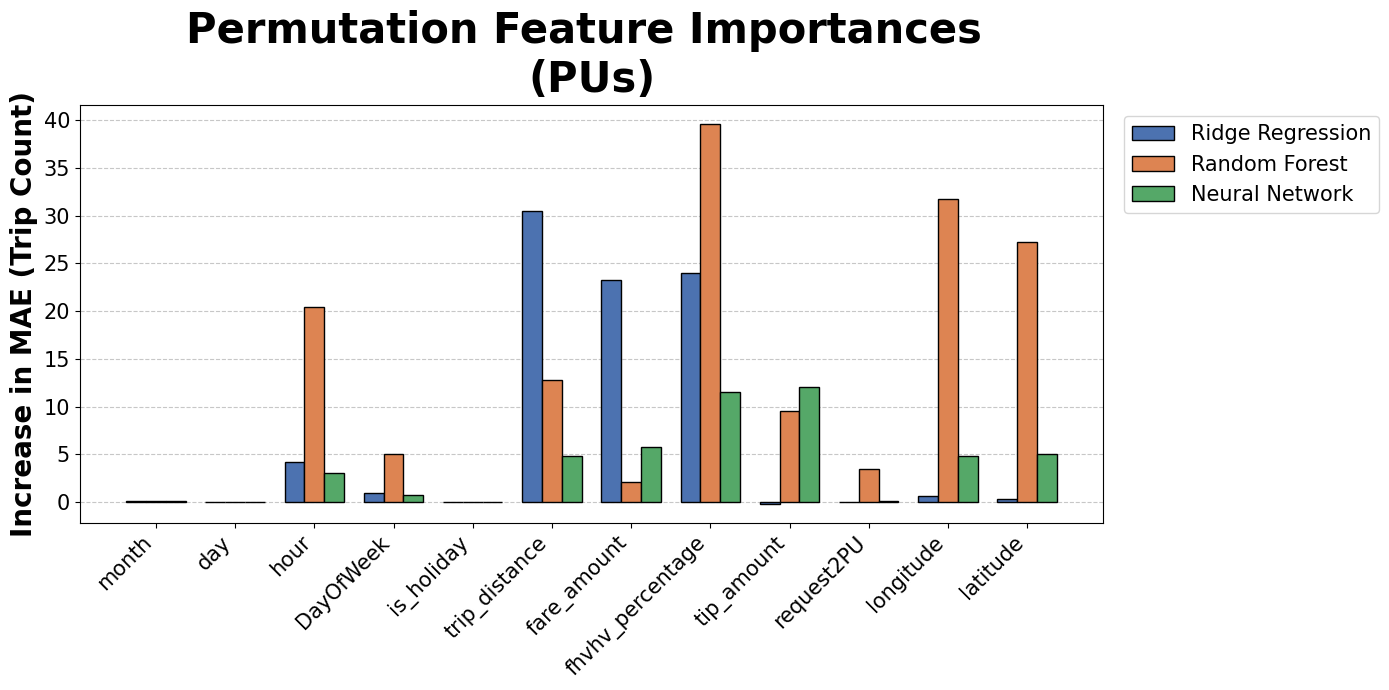

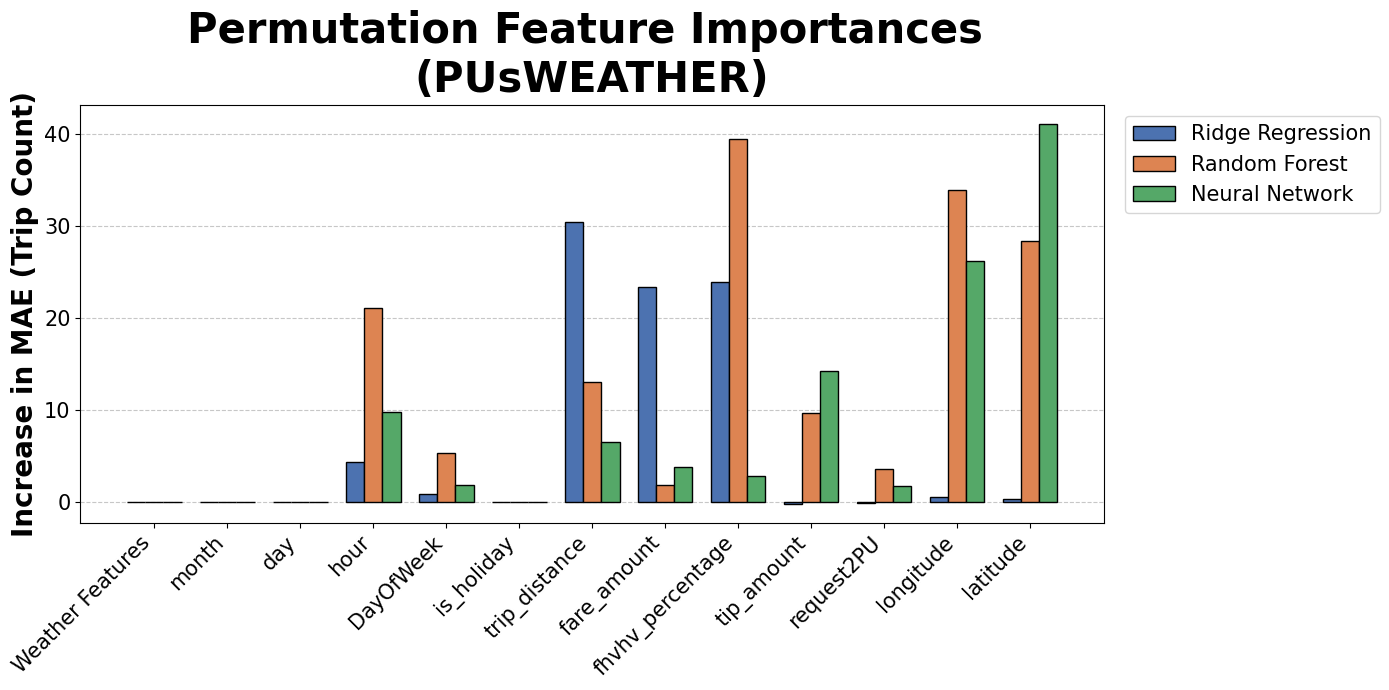

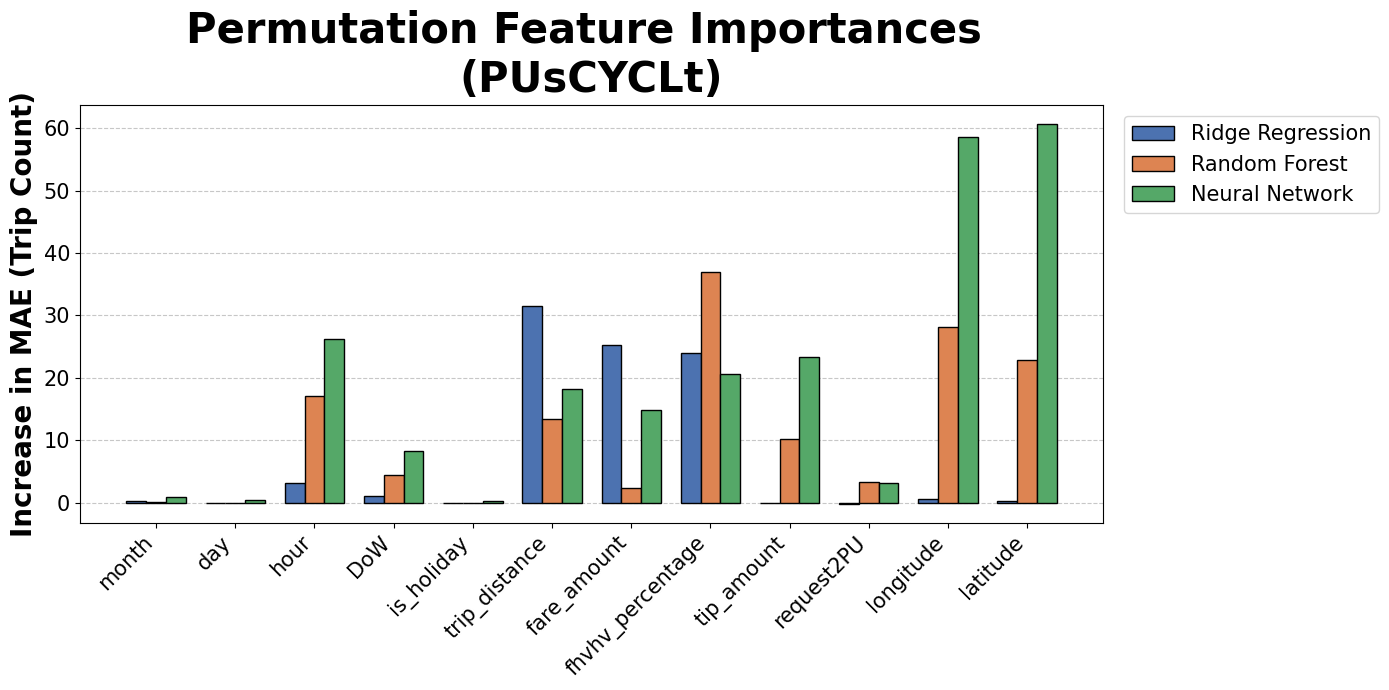

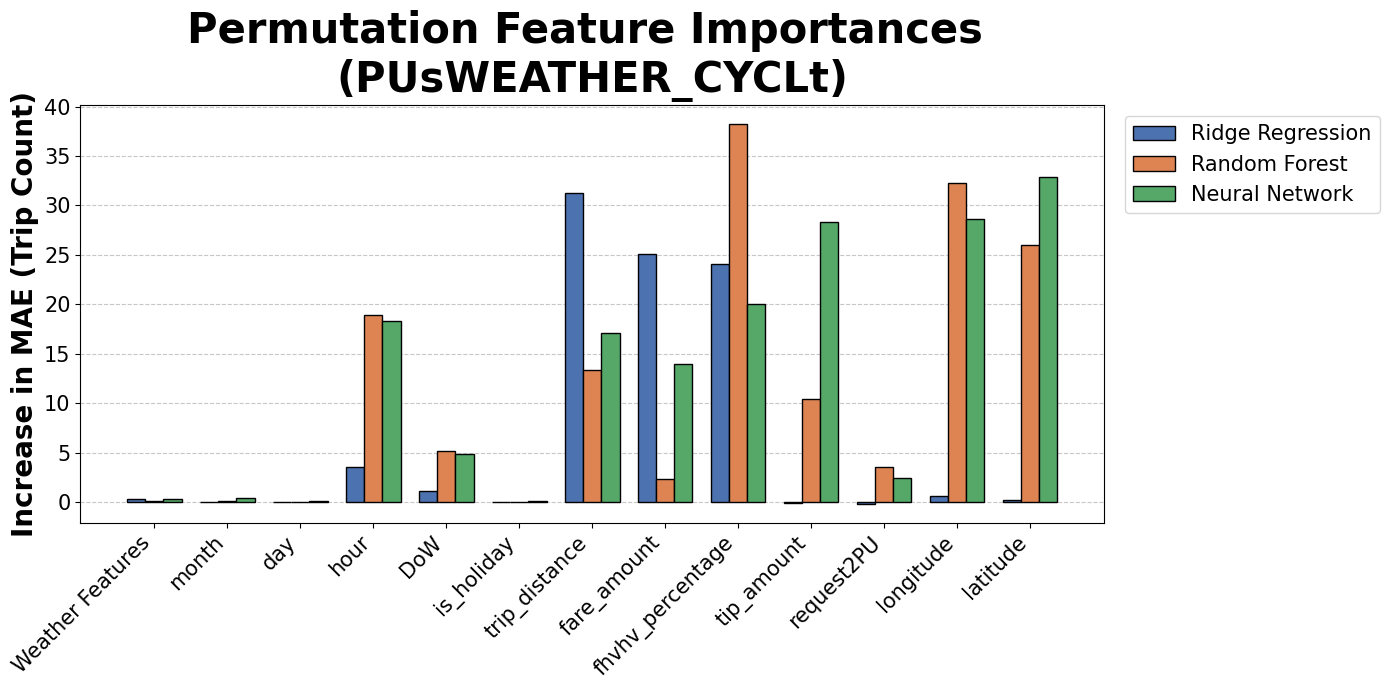

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
df_ridge = pd.read_csv(ridge_path + "/RidgePermutationImportances_PUs.csv")
df_rf = pd.read_csv(rf_path + "/PermutationImportances_PUs.csv")
df_nn = pd.read_csv(nn_path + "/FeatureImportances_PUs.csv")

# 2. Extract the list of all 8 unique datasets
datasets = df_nn["Model"].unique()

# 3. Loop through each dataset and generate a plot
for dataset_name in datasets:

    # Filter data for the current dataset
    ridge_sub = df_ridge[df_ridge["Model"] == dataset_name].set_index("Feature")
    rf_sub = df_rf[df_rf["Model"] == dataset_name].set_index("Feature")
    nn_sub = df_nn[df_nn["Model"] == dataset_name].set_index("Feature")

    rf_sub = rf_sub.drop(index="year", errors="ignore")
    nn_sub = nn_sub.drop(index="year", errors="ignore")

    features = nn_sub.index
    ridge_features = ridge_sub.index.tolist()

    # Align Ridge and RF to use the exact same feature order as NN
    ridge_sub = ridge_sub.loc[ridge_features]
    rf_sub = rf_sub.loc[features]

    # Set up plot geometry
    x = np.arange(len(features))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the grouped bars with error bars
    ax.bar(x - width, ridge_sub["Importance"], width,
           label="Ridge Regression", edgecolor="black", capsize=3, color="#4c72b0")

    ax.bar(x, rf_sub["Importance"], width,
           label="Random Forest", edgecolor="black", capsize=3, color="#dd8452")

    ax.bar(x + width, nn_sub["Importance"], width,
           label="Neural Network", edgecolor="black", capsize=3, color="#55a868")

    ax.set_ylabel("Increase in MAE (Trip Count)", fontsize=20, fontweight="bold")

    ax.set_title(f"Permutation Feature Importances \n({dataset_name})", fontsize=30, fontweight="bold", pad=10)

    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=15)
    ax.tick_params(axis="y", labelsize=15)

    ax.legend(title="", fontsize=15, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    fig.tight_layout()

    # Save the figure using the dataset name in the file path
    save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Feature_Importance_{dataset_name}.pdf"
    #plt.savefig(save_path, dpi=300)
    plt.show()

    # Close the figure so memory doesn't overload during the loop
    plt.close(fig)


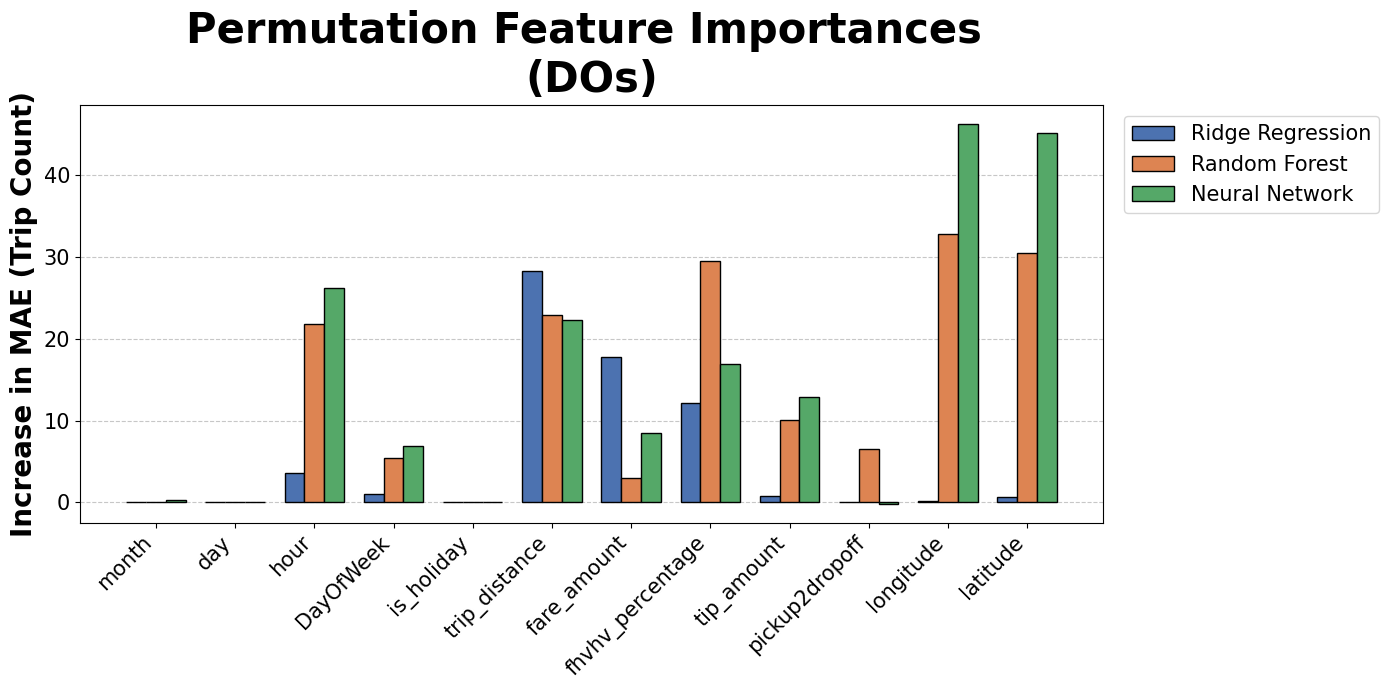

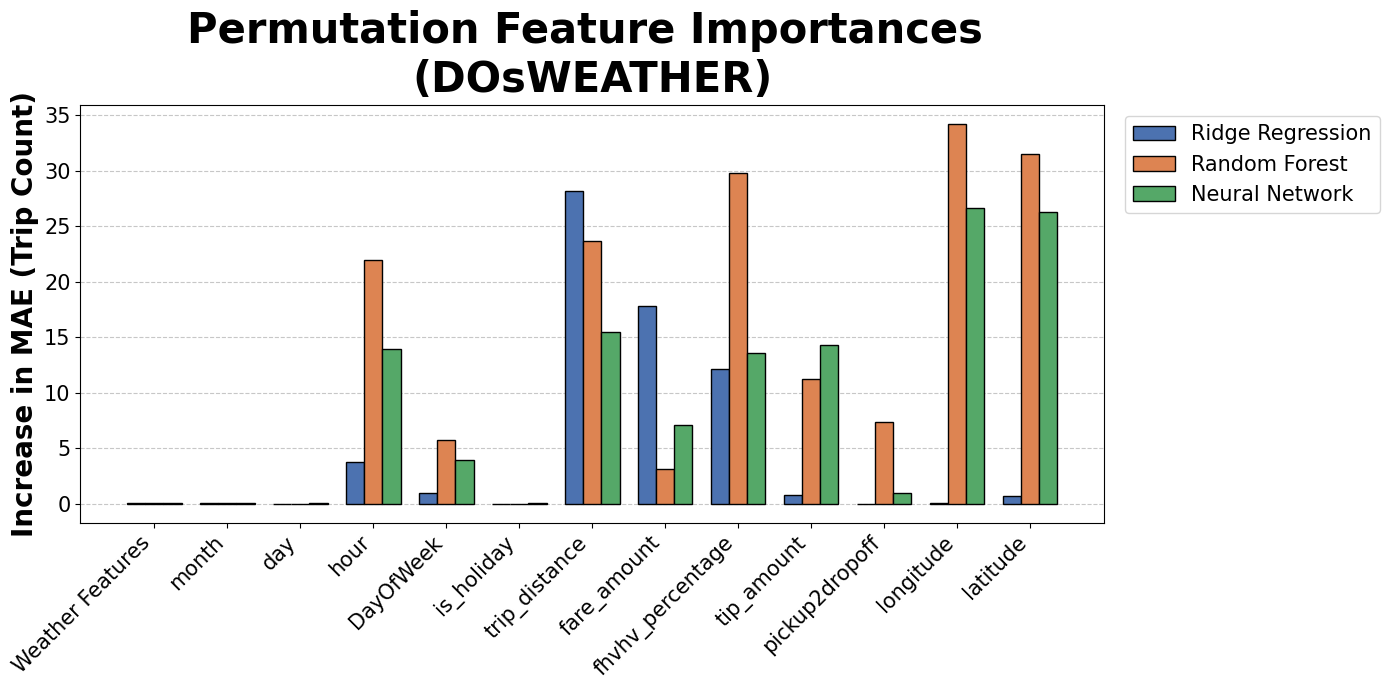

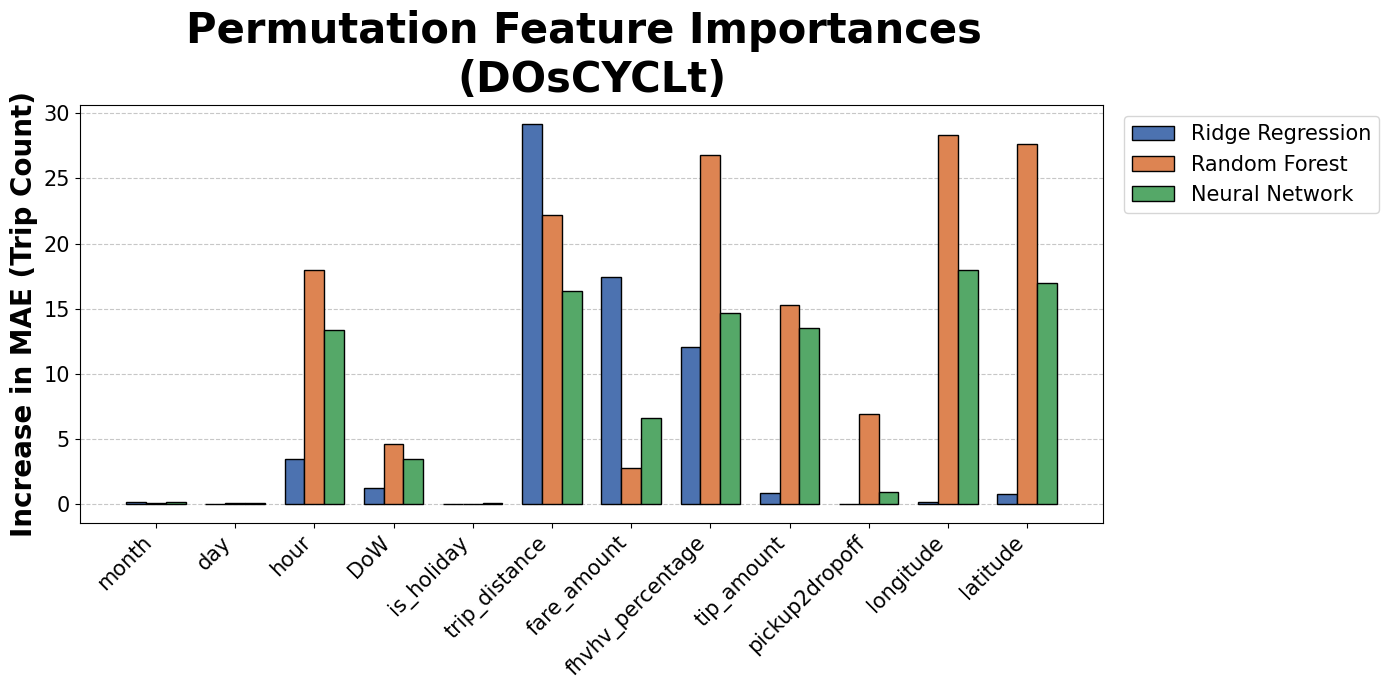

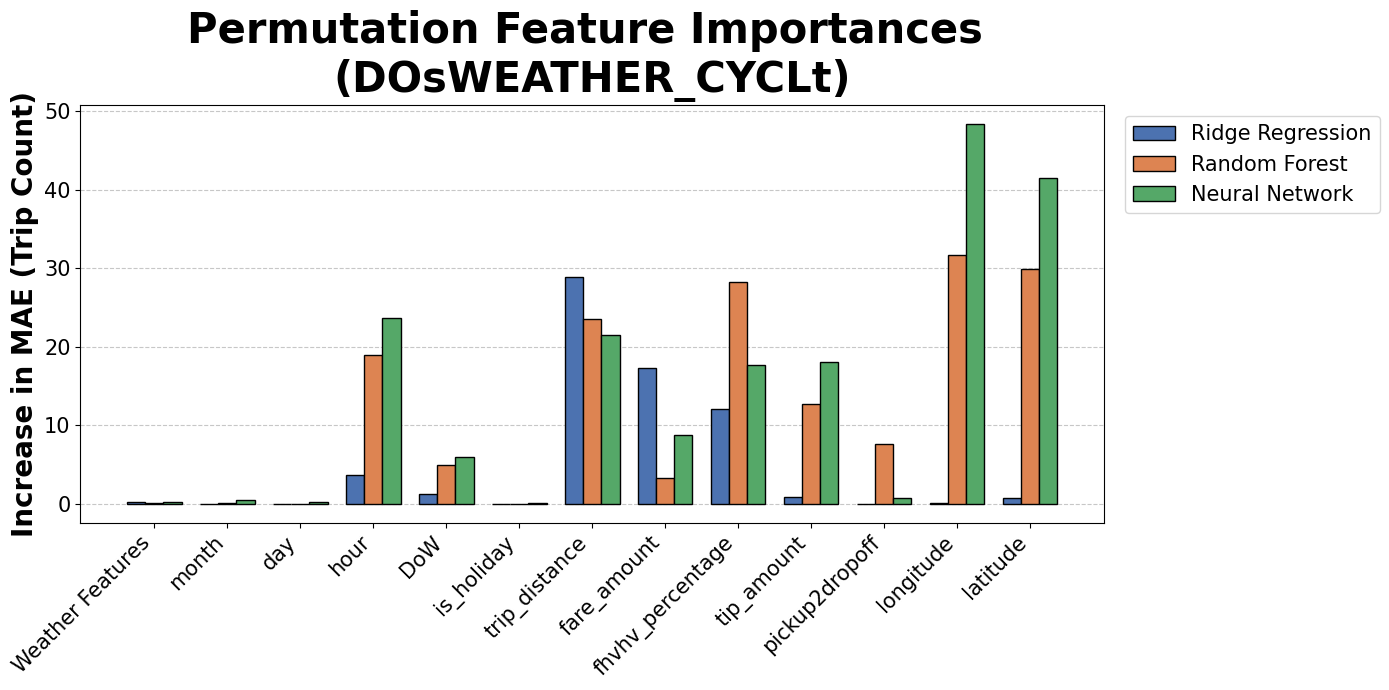

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
df_ridge = pd.read_csv(ridge_path + "/RidgePermutationImportances_DOs.csv")
df_rf = pd.read_csv(rf_path + "/PermutationImportances_DOs.csv")
df_nn = pd.read_csv(nn_path + "/FeatureImportances_DOs.csv")

# 2. Extract the list of all 8 unique datasets
datasets = df_nn["Model"].unique()

# 3. Loop through each dataset and generate a plot
for dataset_name in datasets:

    # Filter data for the current dataset
    ridge_sub = df_ridge[df_ridge["Model"] == dataset_name].set_index("Feature")
    rf_sub = df_rf[df_rf["Model"] == dataset_name].set_index("Feature")
    nn_sub = df_nn[df_nn["Model"] == dataset_name].set_index("Feature")

    rf_sub = rf_sub.drop(index="year", errors="ignore")
    nn_sub = nn_sub.drop(index="year", errors="ignore")

    features = nn_sub.index
    ridge_features = ridge_sub.index.tolist()

    # Align Ridge and RF to use the exact same feature order as NN
    ridge_sub = ridge_sub.loc[ridge_features]
    rf_sub = rf_sub.loc[features]

    # Set up plot geometry
    x = np.arange(len(features))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the grouped bars with error bars
    ax.bar(x - width, ridge_sub["Importance"], width,
           label="Ridge Regression", edgecolor="black", capsize=3, color="#4c72b0")

    ax.bar(x, rf_sub["Importance"], width,
           label="Random Forest", edgecolor="black", capsize=3, color="#dd8452")

    ax.bar(x + width, nn_sub["Importance"], width,
           label="Neural Network", edgecolor="black", capsize=3, color="#55a868")

    ax.set_ylabel("Increase in MAE (Trip Count)", fontsize=20, fontweight="bold")

    ax.set_title(f"Permutation Feature Importances \n({dataset_name})", fontsize=30, fontweight="bold", pad=10)

    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha="right", fontsize=15)
    ax.tick_params(axis="y", labelsize=15)

    ax.legend(title="", fontsize=15, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    fig.tight_layout()

    # Save the figure using the dataset name in the file path
    save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Feature_Importance_{dataset_name}.pdf"
    #plt.savefig(save_path, dpi=300)
    plt.show()

    # Close the figure so memory doesn't overload during the loop
    plt.close(fig)

Residuals Histogram

In [8]:
# Initialize the DataFrame to store Drop-Off actuals and Ridge Regression predictions
DO_RidgeResults = None

for file in DO_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable, date, AND the year column
    X_test = df_test.drop(columns=["trip_count","date","year"])

    # Initialize the DO_RidgeResults DataFrame during the first loop iteration
    if DO_RidgeResults is None:
        DO_RidgeResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Ridge Regression (.pkl) model file for the current dataset
    for model in ridge_files:
        if f"{DO_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the matching Ridge model object into memory
    ridge_model = joblib.load(right_model)

    # Generate predictions using the loaded model and store them as a new column
    DO_RidgeResults[f"{DO_datasets[file]}"] = ridge_model.predict(X_test)


# Initialize the DataFrame to store Pick-Up actuals and Ridge Regression predictions
PU_RidgeResults = None

for file in PU_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable, date, AND the year column
    X_test = df_test.drop(columns=["trip_count","date","year"])

    # Initialize the PU_RidgeResults DataFrame during the first loop iteration
    if PU_RidgeResults is None:
        PU_RidgeResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Ridge Regression (.pkl) model file for the current dataset
    for model in ridge_files:
        if f"{PU_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the matching Ridge model object into memory
    ridge_model = joblib.load(right_model)

    # Generate predictions using the loaded model and store them as a new column
    PU_RidgeResults[f"{PU_datasets[file]}"] = ridge_model.predict(X_test)

In [9]:
# Initialize the DataFrame to store Drop-Off actuals and Random Forest predictions
DO_RFResults = None

for file in DO_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable and date
    X_test = df_test.drop(columns=["trip_count","date"])

    # Initialize the DO_RFResults DataFrame during the first loop iteration
    if DO_RFResults is None:
        DO_RFResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Random Forest (.pkl) model file for the current dataset
    for model in rf_files:
        if f"{DO_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the matching Random Forest model object into memory
    rf_model = joblib.load(right_model)

    # Cast the feature matrix to float32, generate predictions, extract the numpy array, and store it as a new column
    DO_RFResults[f"{DO_datasets[file]}"] = rf_model.predict(X_test.astype("float32")).values


# Initialize the DataFrame to store Pick-Up actuals and Random Forest predictions
PU_RFResults = None

for file in PU_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable and date
    X_test = df_test.drop(columns=["trip_count","date"])

    # Initialize the PU_RFResults DataFrame during the first loop iteration
    if PU_RFResults is None:
        PU_RFResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Random Forest (.pkl) model file for the current dataset
    for model in rf_files:
        if f"{PU_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the matching Random Forest model object into memory
    rf_model = joblib.load(right_model)

    # Cast the feature matrix to float32, generate predictions, extract the numpy array, and store it as a new column
    PU_RFResults[f"{PU_datasets[file]}"] = rf_model.predict(X_test.astype("float32")).values

In [10]:
import pandas as pd
import tensorflow as tf

# Initialize the DataFrame to store Drop-Off actuals and Neural Network predictions
DO_NNResults = None

for file in DO_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable and date
    X_test = df_test.drop(columns=["trip_count","date"])


    # Initialize the DO_NNResults DataFrame during the first loop iteration
    if DO_NNResults is None:
        DO_NNResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Neural Network (.keras) model file for the current dataset
    for model in nn_files:
        if f"{DO_datasets[file]}.keras" in model:
            right_model = model
            break

    # Clear the TensorFlow backend session to free memory and prevent model bleed
    tf.keras.backend.clear_session()

    # Load the Keras model (compile=False saves time since we are only doing inference)
    nn_model = tf.keras.models.load_model(right_model, compile=False)

    # Convert the pandas feature DataFrame into a TensorFlow float32 tensor
    X_test_tensor = tf.constant(X_test.values, dtype=tf.float32)

    # Generate predictions using the loaded neural network
    preds = nn_model.predict(X_test_tensor)

    # Flatten the 2D prediction array into 1D and store it in the results DataFrame
    DO_NNResults[f"{DO_datasets[file]}"] = preds.flatten()



# Initialize the DataFrame to store Pick-Up actuals and Neural Network predictions
PU_NNResults = None

for file in PU_datasets:
    # Read the dataset file
    df = pd.read_parquet(file)

    # Rename the second column in the DataFrame to 'date'
    df = df.rename(columns={df.columns[1]:"date"})

    # Filter for rows in the years 2023 and 2024
    df = df[df["year"].isin([2023, 2024])]

    # Map the year values to binary integers (2023 to 0, 2024 to 1)
    df["year"] = df["year"].map({2023: 0, 2024: 1})

    # Drop specific columns, ignoring errors if they do not exist
    df = df.drop(columns=["DOLocationID", "PULocationID"], errors="ignore")
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")

    # Remove any rows containing NaN values
    df = df.dropna()

    # Create the test set using data from January 1st, 2024 onwards
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()

    # Define the feature matrix by dropping the target variable and date
    X_test = df_test.drop(columns=["trip_count","date"])

    # Initialize the PU_NNResults DataFrame during the first loop iteration
    if PU_NNResults is None:
        PU_NNResults = pd.DataFrame({
            "Date" : df_test["date"],
            "Actual" : df_test["trip_count"]
        }).set_index("Date")

    # Find the matching Neural Network (.keras) model file for the current dataset
    for model in nn_files:
        if f"{PU_datasets[file]}.keras" in model:
            right_model = model
            break


    # Clear the TensorFlow backend session to free memory and prevent model bleed
    tf.keras.backend.clear_session()

    # Load the Keras model (compile=False saves time since we are only doing inference)
    nn_model = tf.keras.models.load_model(right_model, compile=False)

    # Convert the pandas feature DataFrame into a TensorFlow float32 tensor
    X_test_tensor = tf.constant(X_test.values, dtype=tf.float32)

    # Generate predictions using the loaded neural network
    preds = nn_model.predict(X_test_tensor)

    # Flatten the 2D prediction array into 1D and store it in the results DataFrame
    PU_NNResults[f"{PU_datasets[file]}"] = preds.flatten()

69629/69629 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 94s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 88s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 90s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 93s 1ms/step


In [11]:
# Reverse the scaling transformation for the Pick-Up and Drop-Off results
PU_Ridge_unscaled = (PU_RidgeResults * 126) + 71
DO_Ridge_unscaled = (DO_RidgeResults * 125) + 68

PU_RF_unscaled = (PU_RFResults * 126) + 71
DO_RF_unscaled = (DO_RFResults * 125) + 68

PU_NN_unscaled = (PU_NNResults * 126) + 71
DO_NN_unscaled = (DO_NNResults * 125) + 68

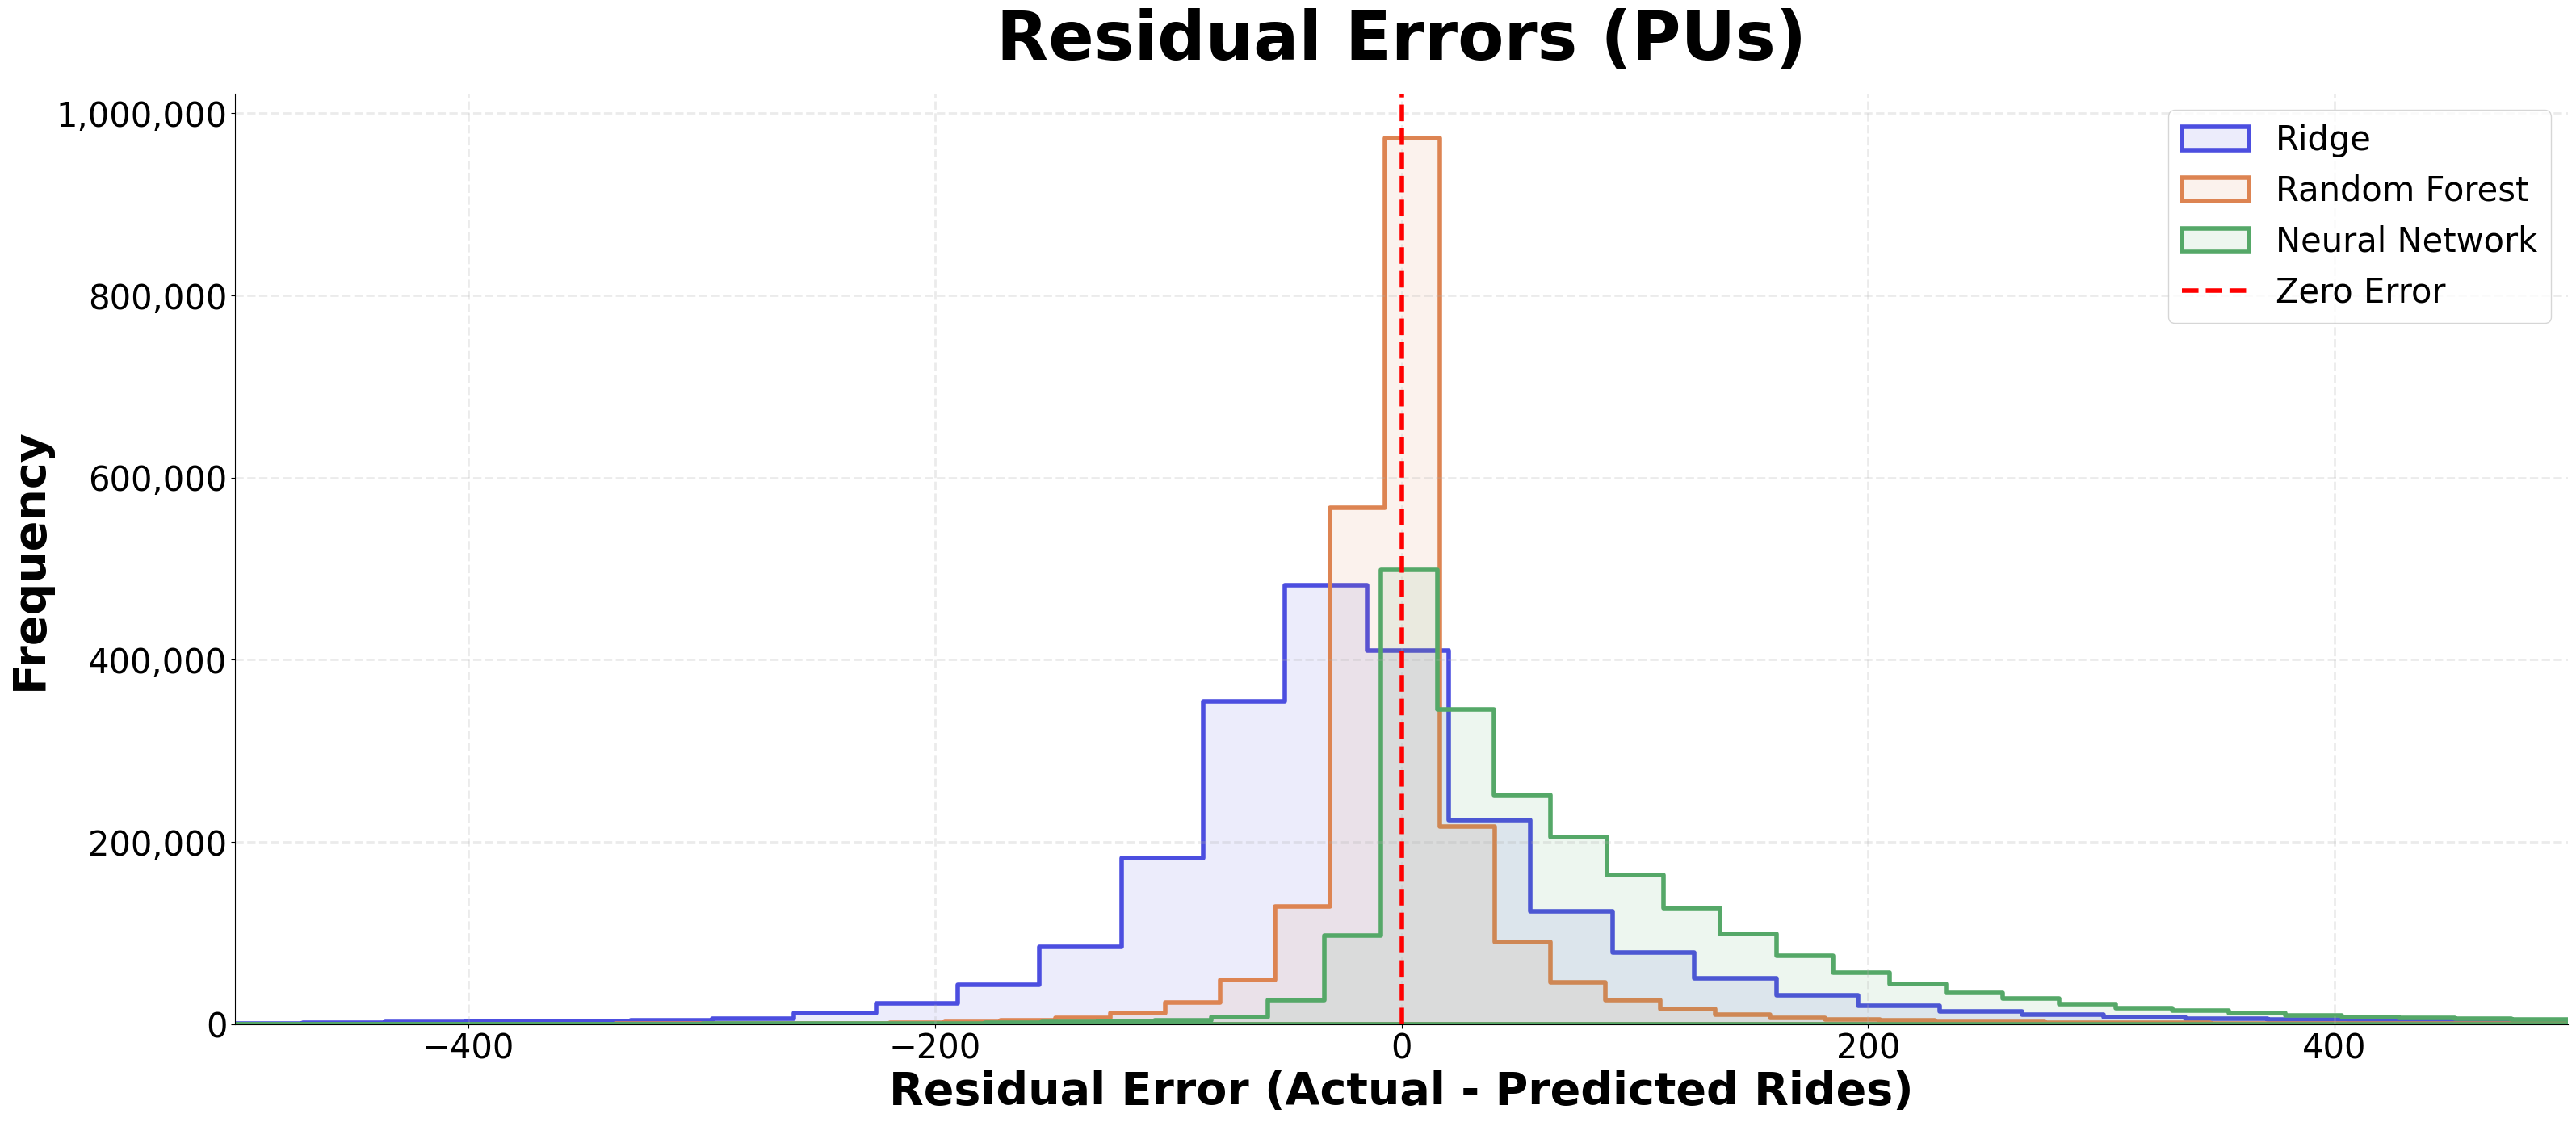

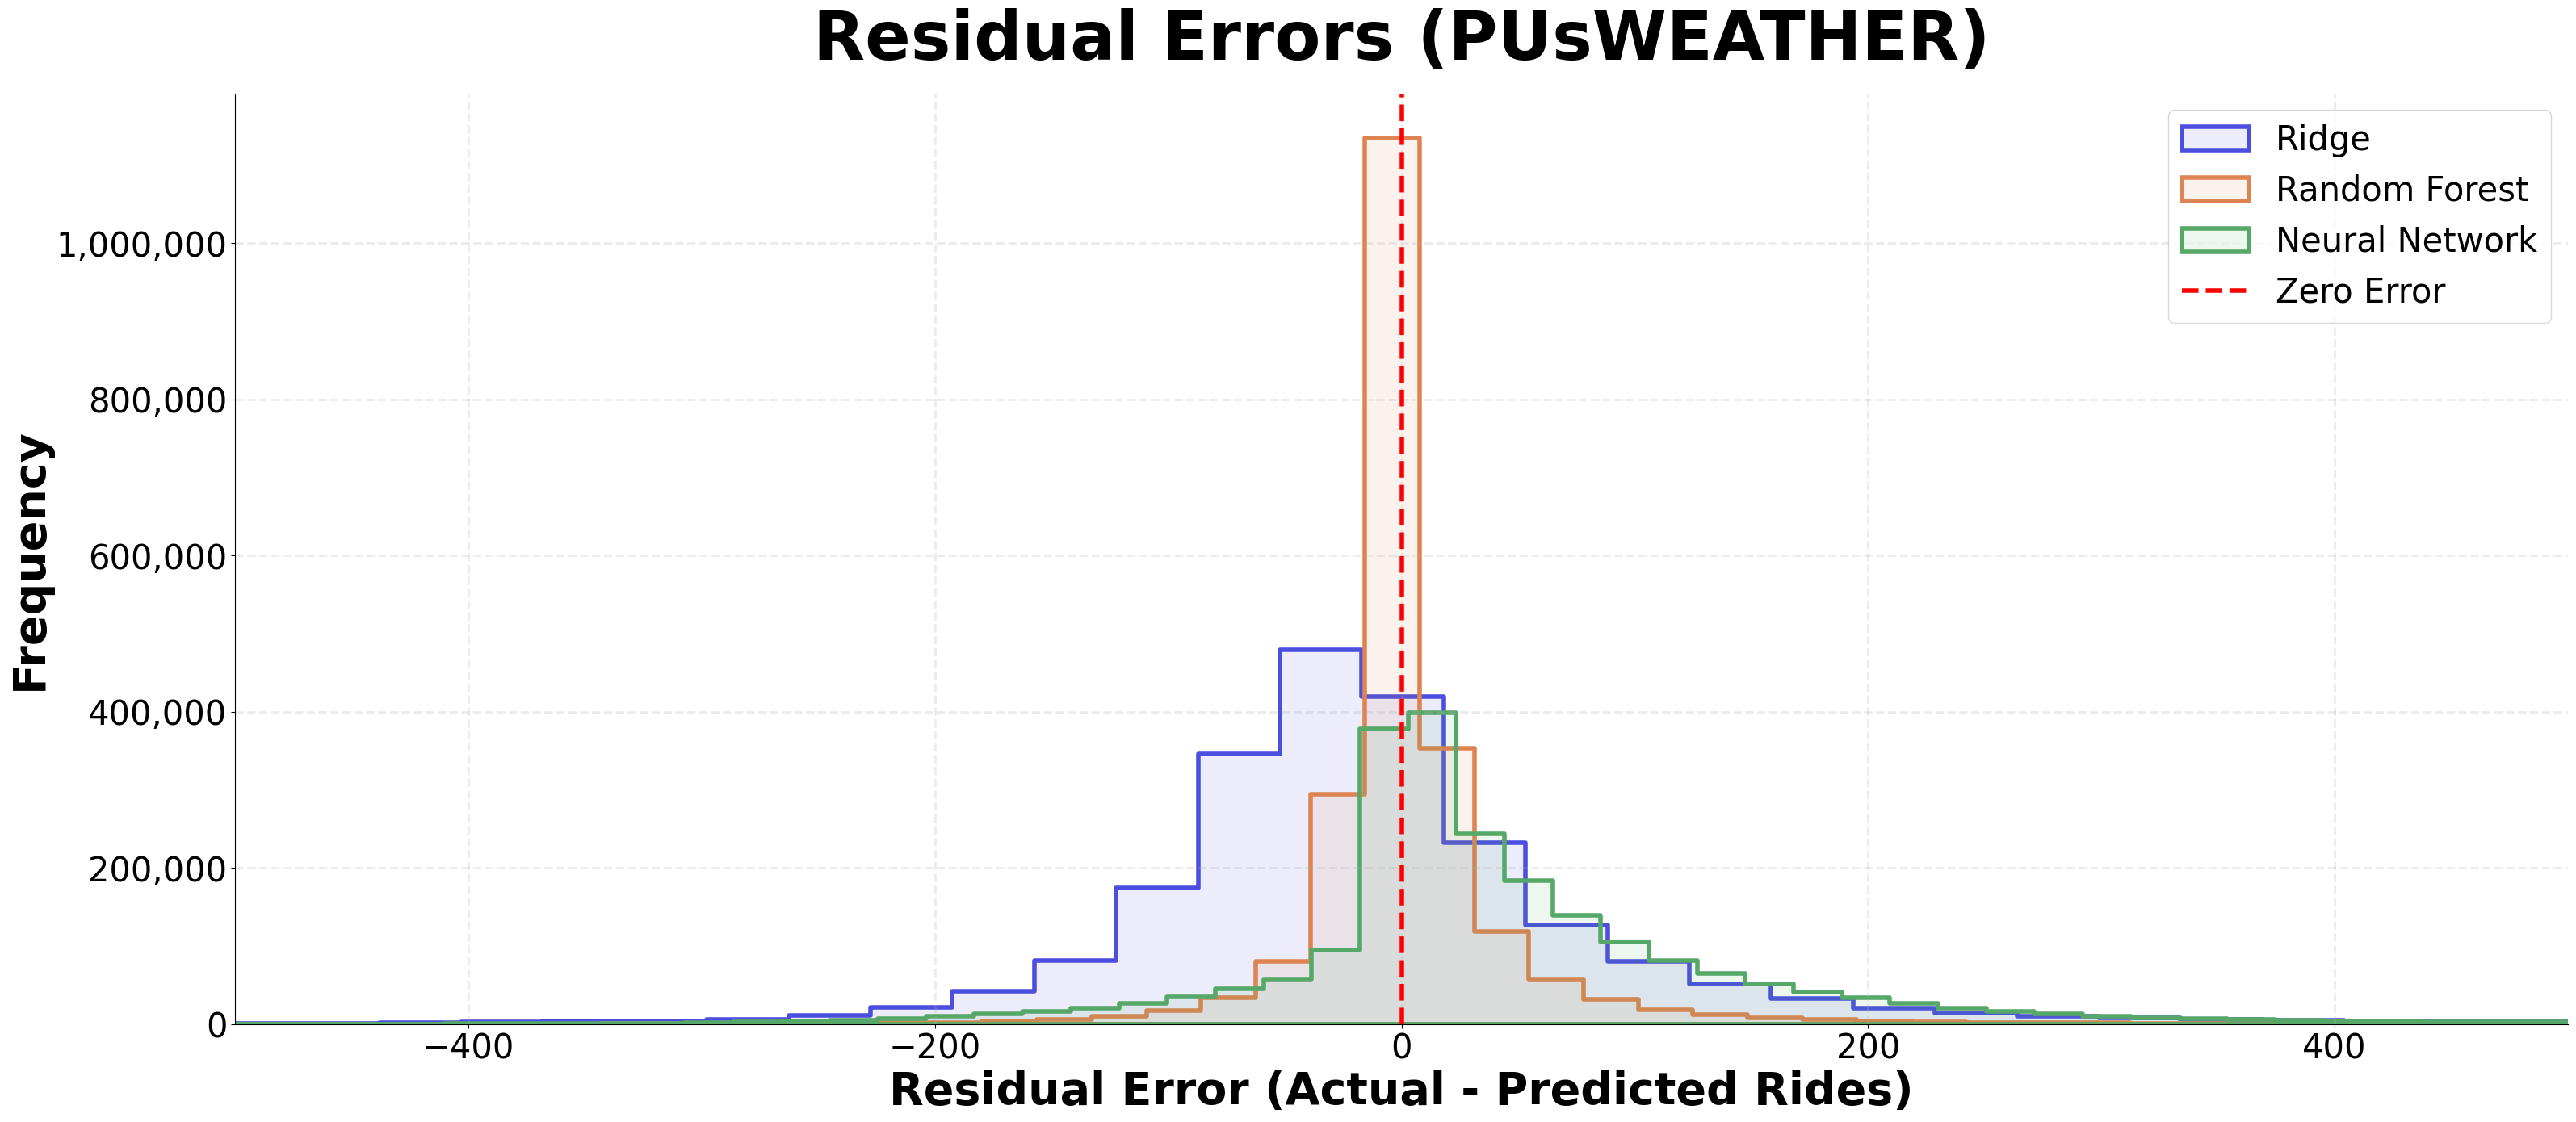

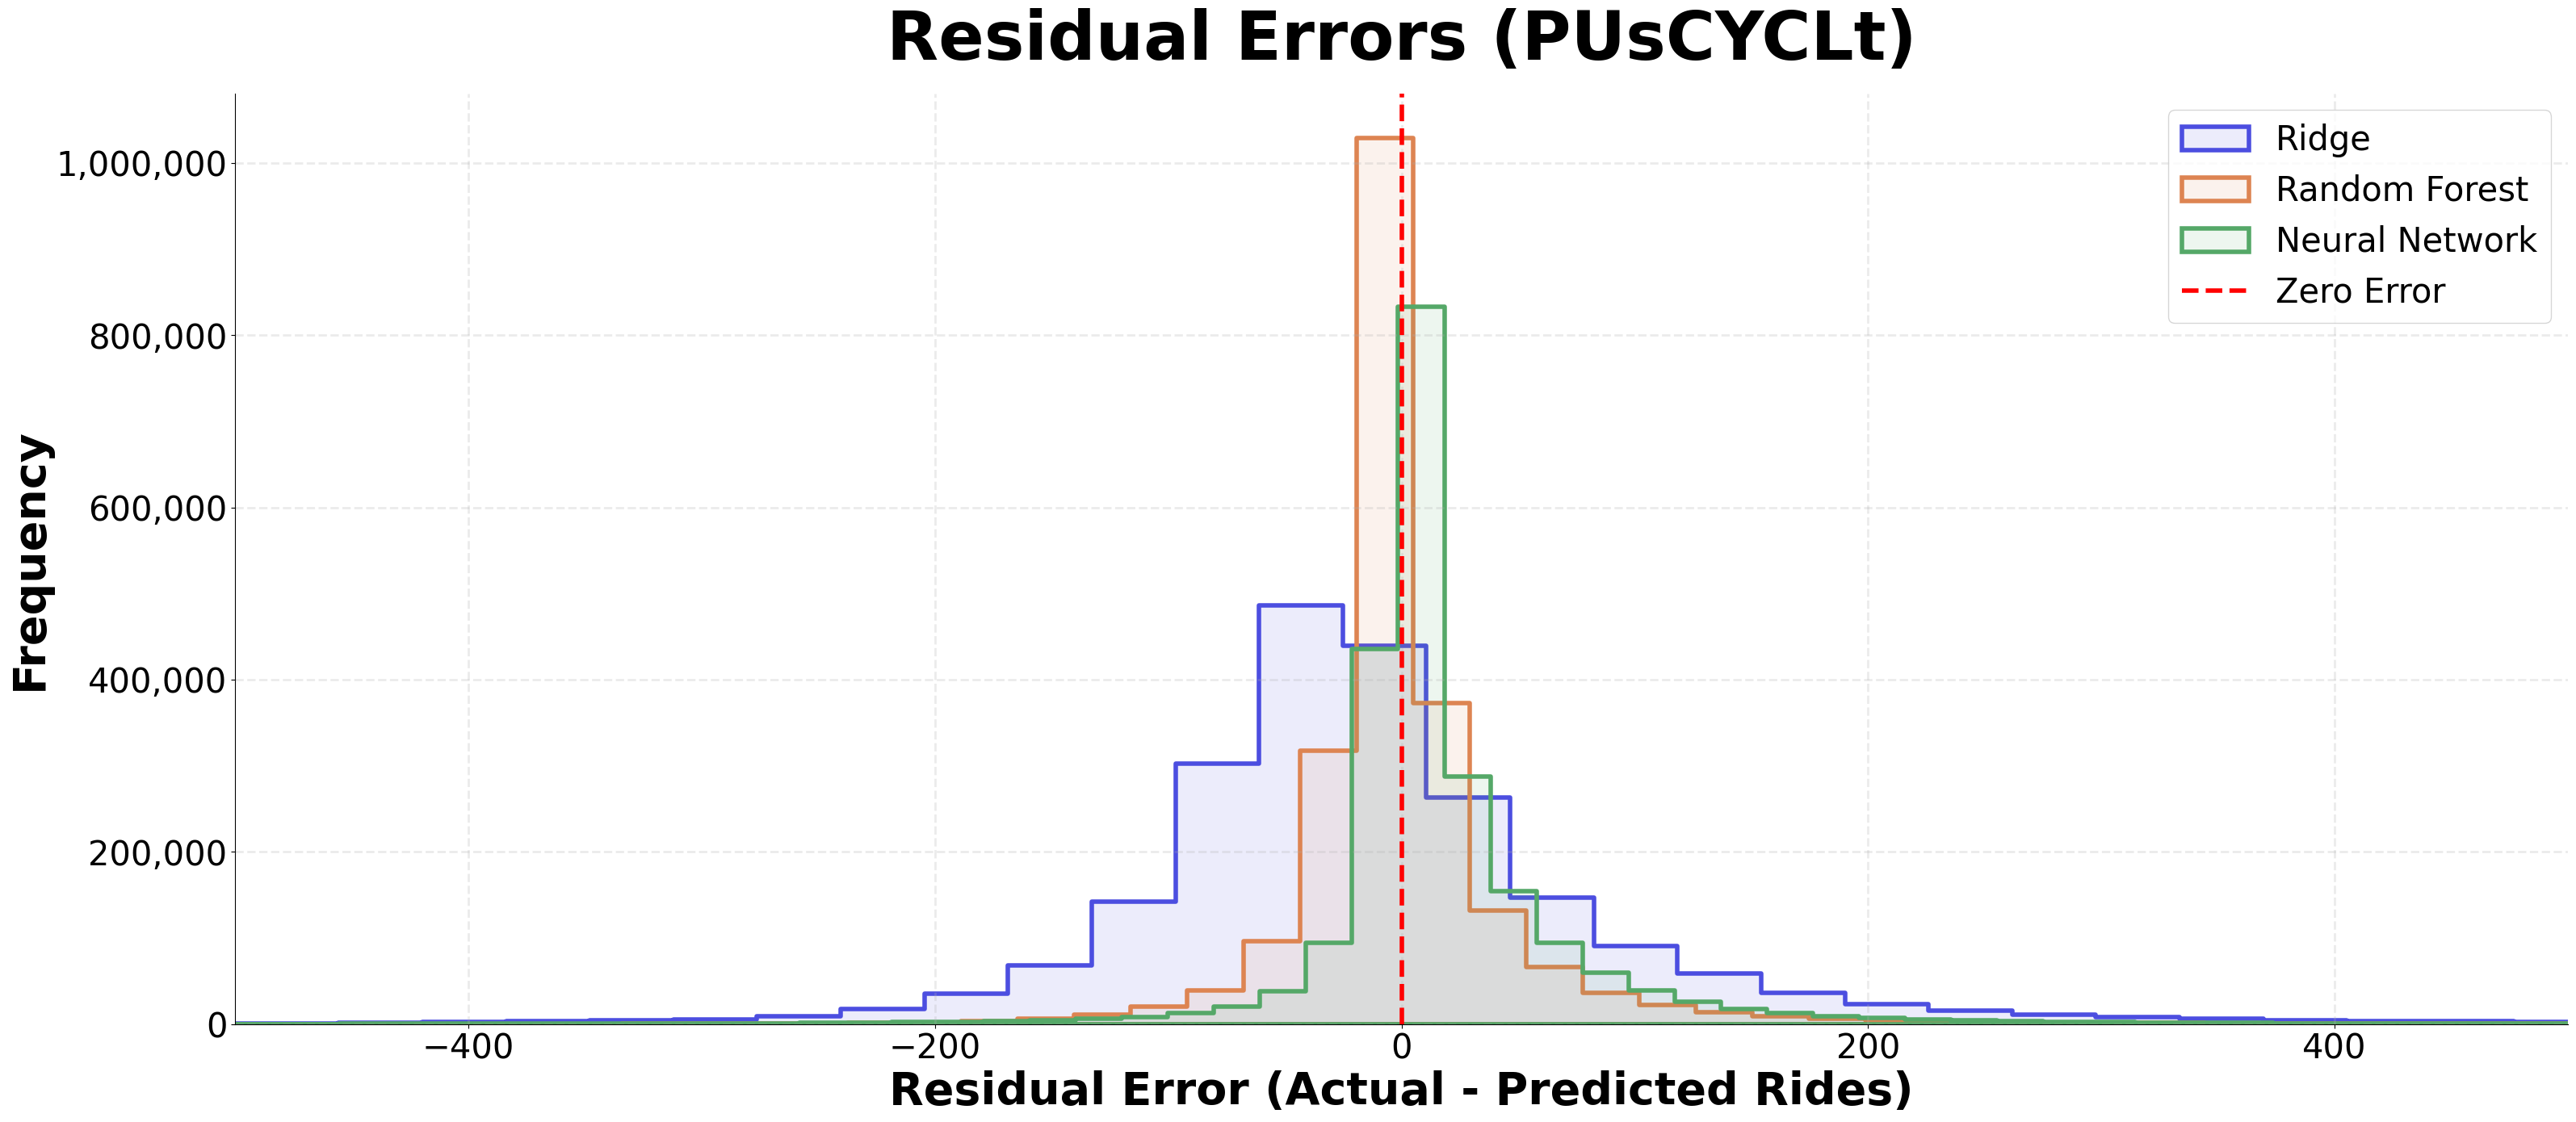

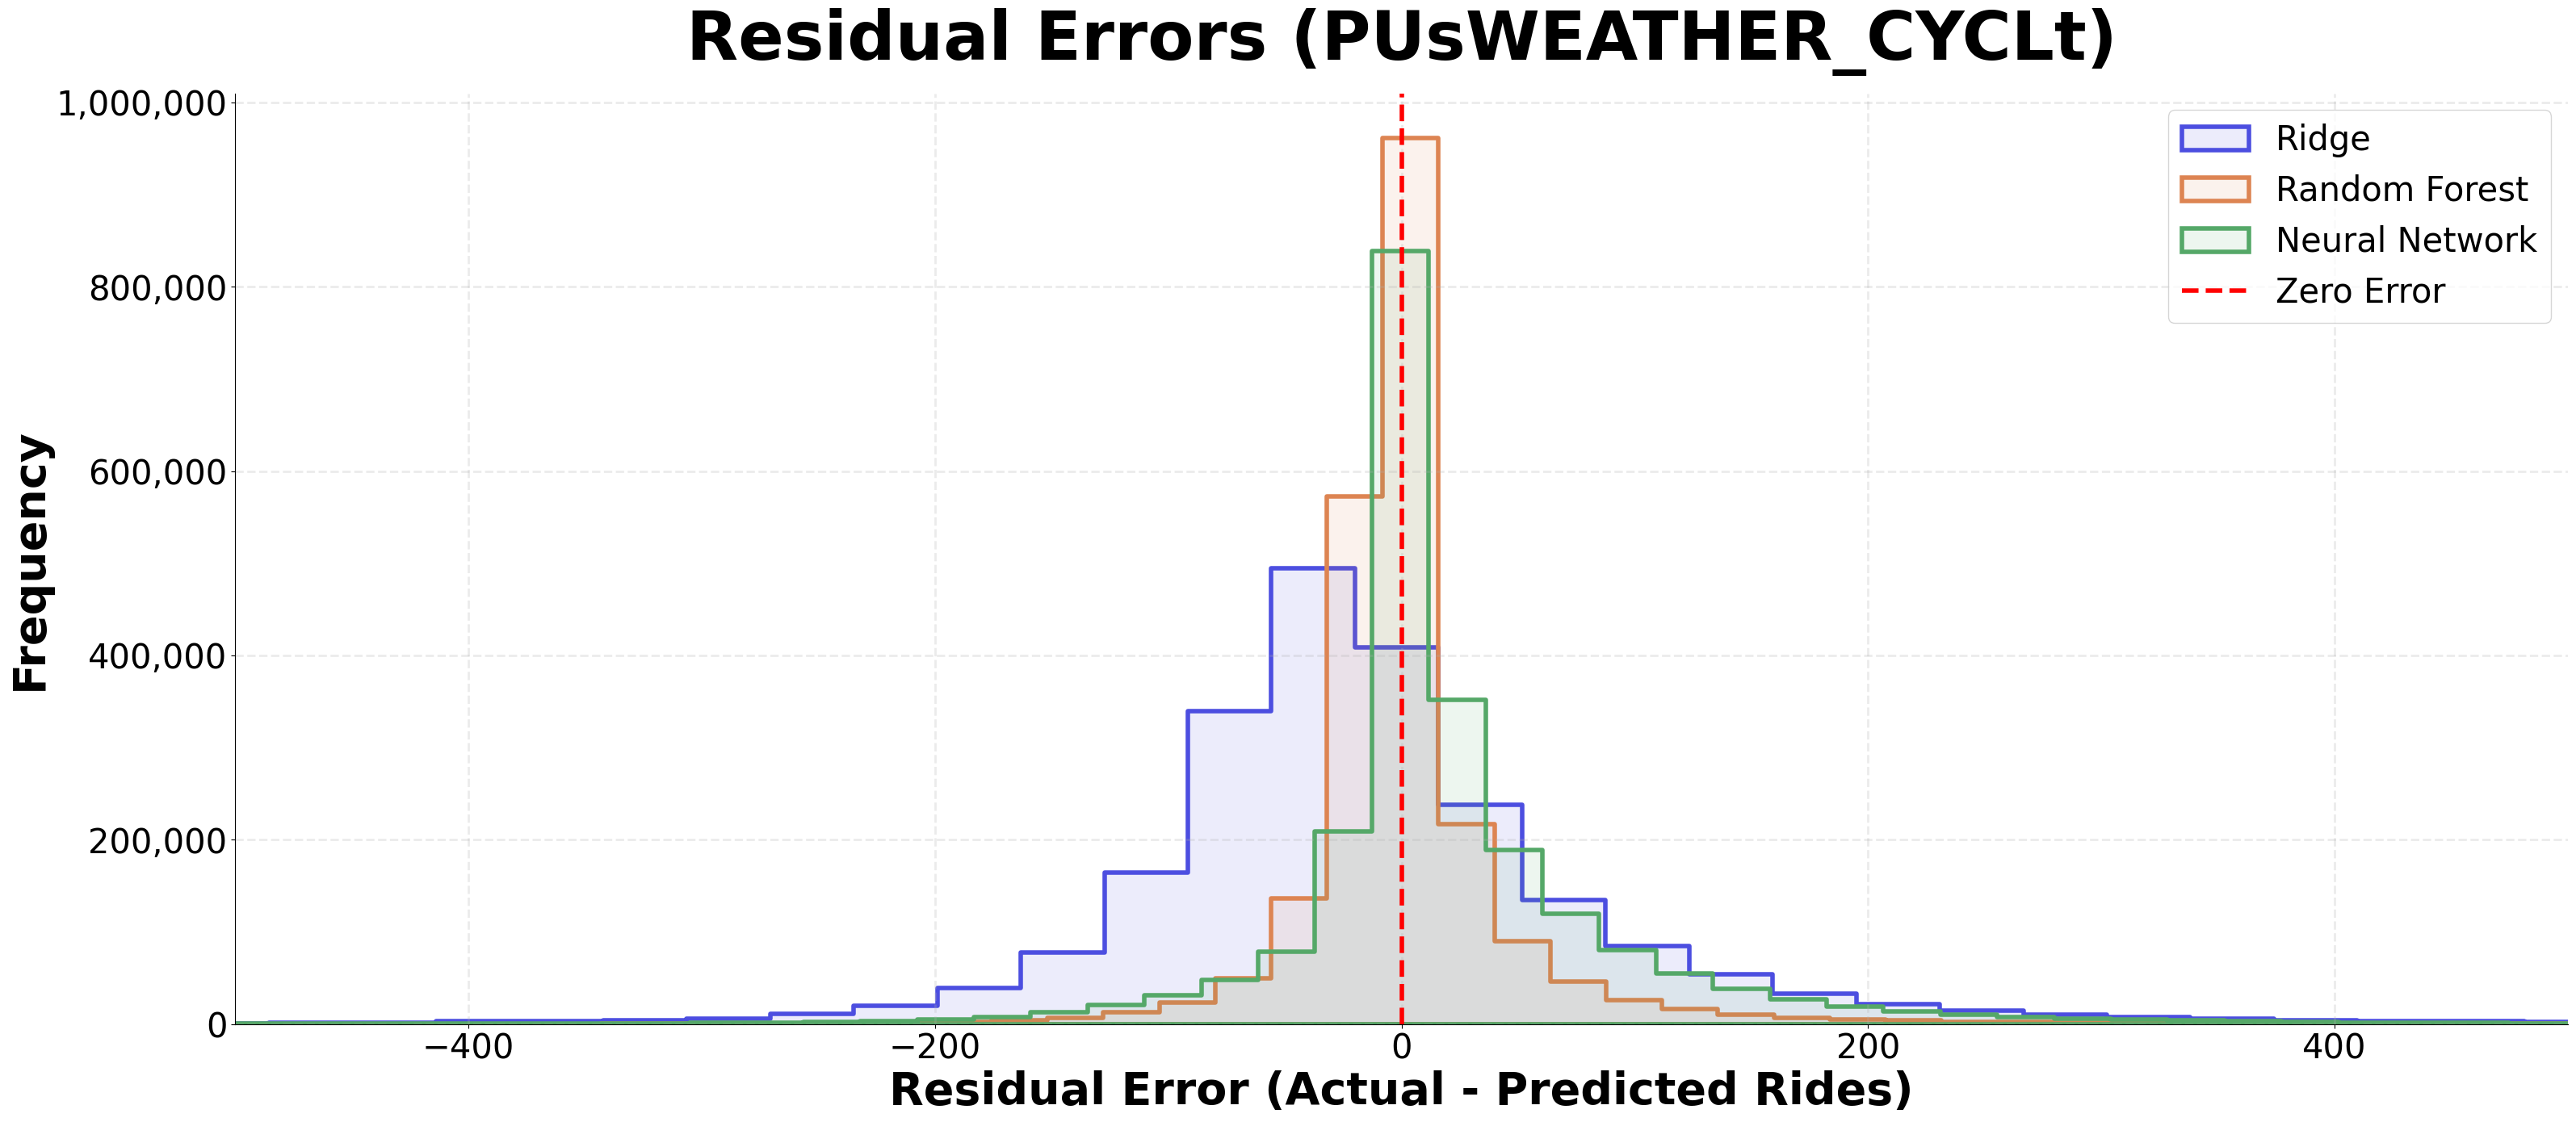

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Identify all dataset variations to iterate through, excluding the target and index columns (AI generated)
dataset_columns = [col for col in PU_Ridge_unscaled.columns if col not in ["Actual", "Date"]]

for dataset in dataset_columns:

    # Calculate residual errors (Actual minus Predicted) for all three model types
    actuals = PU_Ridge_unscaled["Actual"]
    res_ridge = actuals - PU_Ridge_unscaled[dataset]
    res_rf    = actuals - PU_RF_unscaled[dataset]
    res_nn    = actuals - PU_NN_unscaled[dataset]

    # Initialize the figure and plot overlapping step-filled histograms for model comparison
    plt.figure(figsize=(32, 14))
    sns.histplot(res_ridge, bins=200, color="#4C4EE0", label="Ridge", element="step", fill=True, alpha=0.1, linewidth=4)
    sns.histplot(res_rf, bins=200, color="#DD8452", label="Random Forest", element="step", fill=True, alpha=0.1, linewidth=4)
    sns.histplot(res_nn, bins=200, color="#55A868", label="Neural Network", element="step", fill=True, alpha=0.1, linewidth=4)

    # Add a zero-error vertical baseline for visual reference
    plt.axvline(0, color='red', linestyle='--', linewidth=4, label='Zero Error')

    # Apply formatting for titles, labels, font sizes, and add comma separators to the y-axis
    plt.title(f"Residual Errors ({dataset})", fontsize=60, fontweight="bold", pad=30)
    plt.xlabel("Residual Error (Actual - Predicted Rides)", fontweight="bold", fontsize=40)
    plt.ylabel("Frequency", fontweight="bold", fontsize=40)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.grid(True, linestyle='--', alpha=0.25, linewidth=2, zorder=0)

    # Zoom in on the bulk of the distribution, clipping extreme outlier errors beyond ±500
    plt.xlim(-500, 500)

    # Final layout adjustments and legend placement
    sns.despine()
    plt.legend(fontsize=30, loc="upper right")
    plt.tight_layout()

    # Define path, display the plot (saving is currently disabled), and clear memory for the next loop
    save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Residuals_Histogram_{dataset}.pdf"
    #plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()

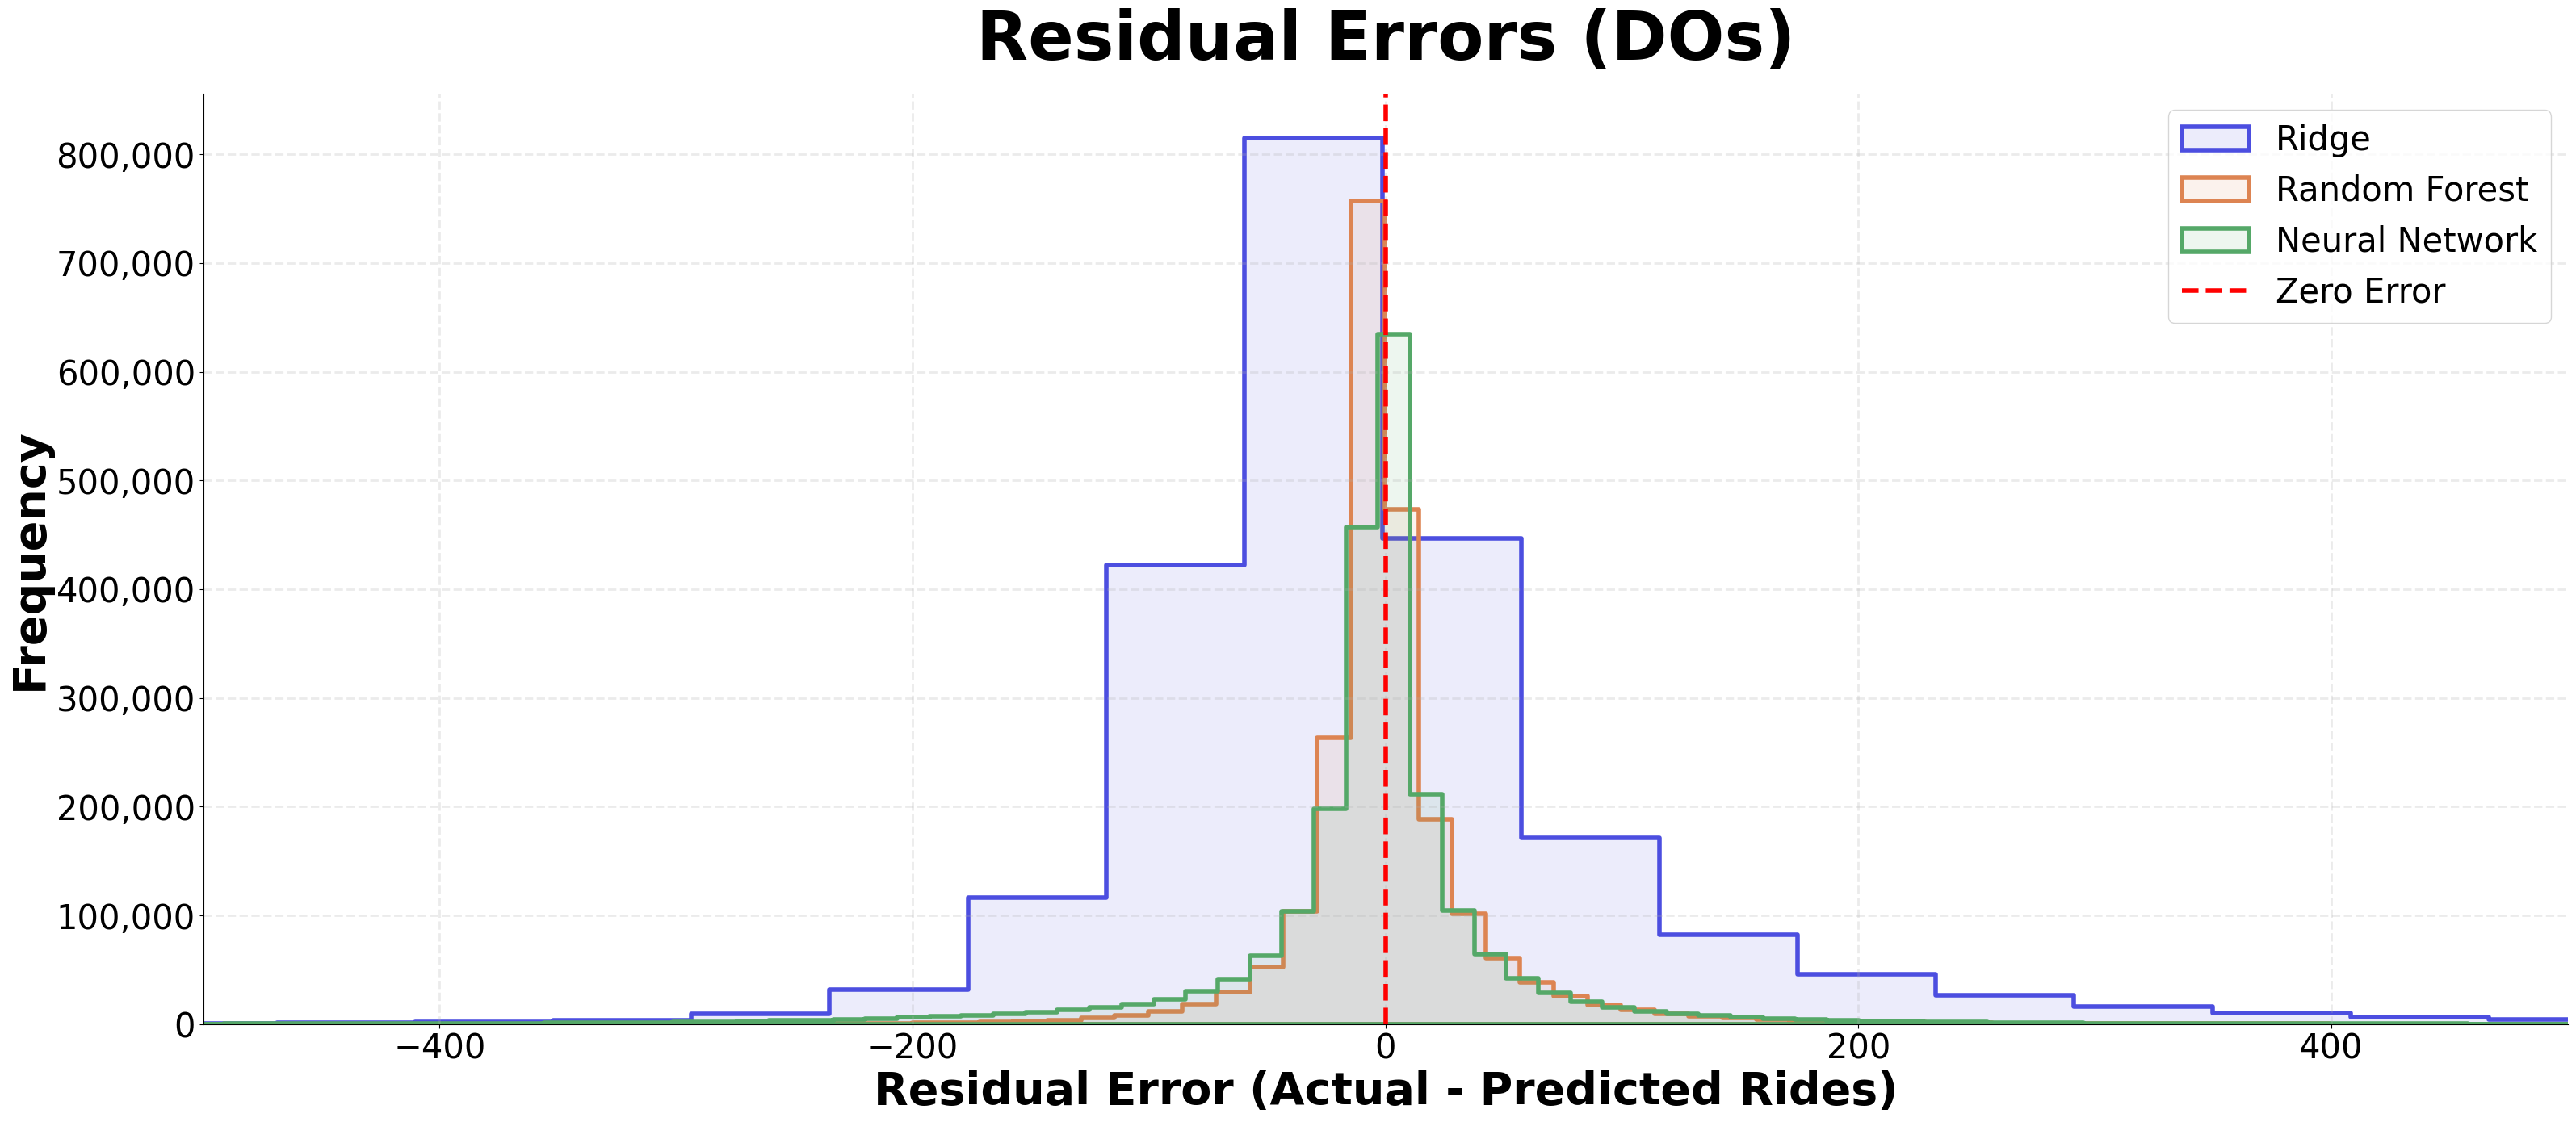

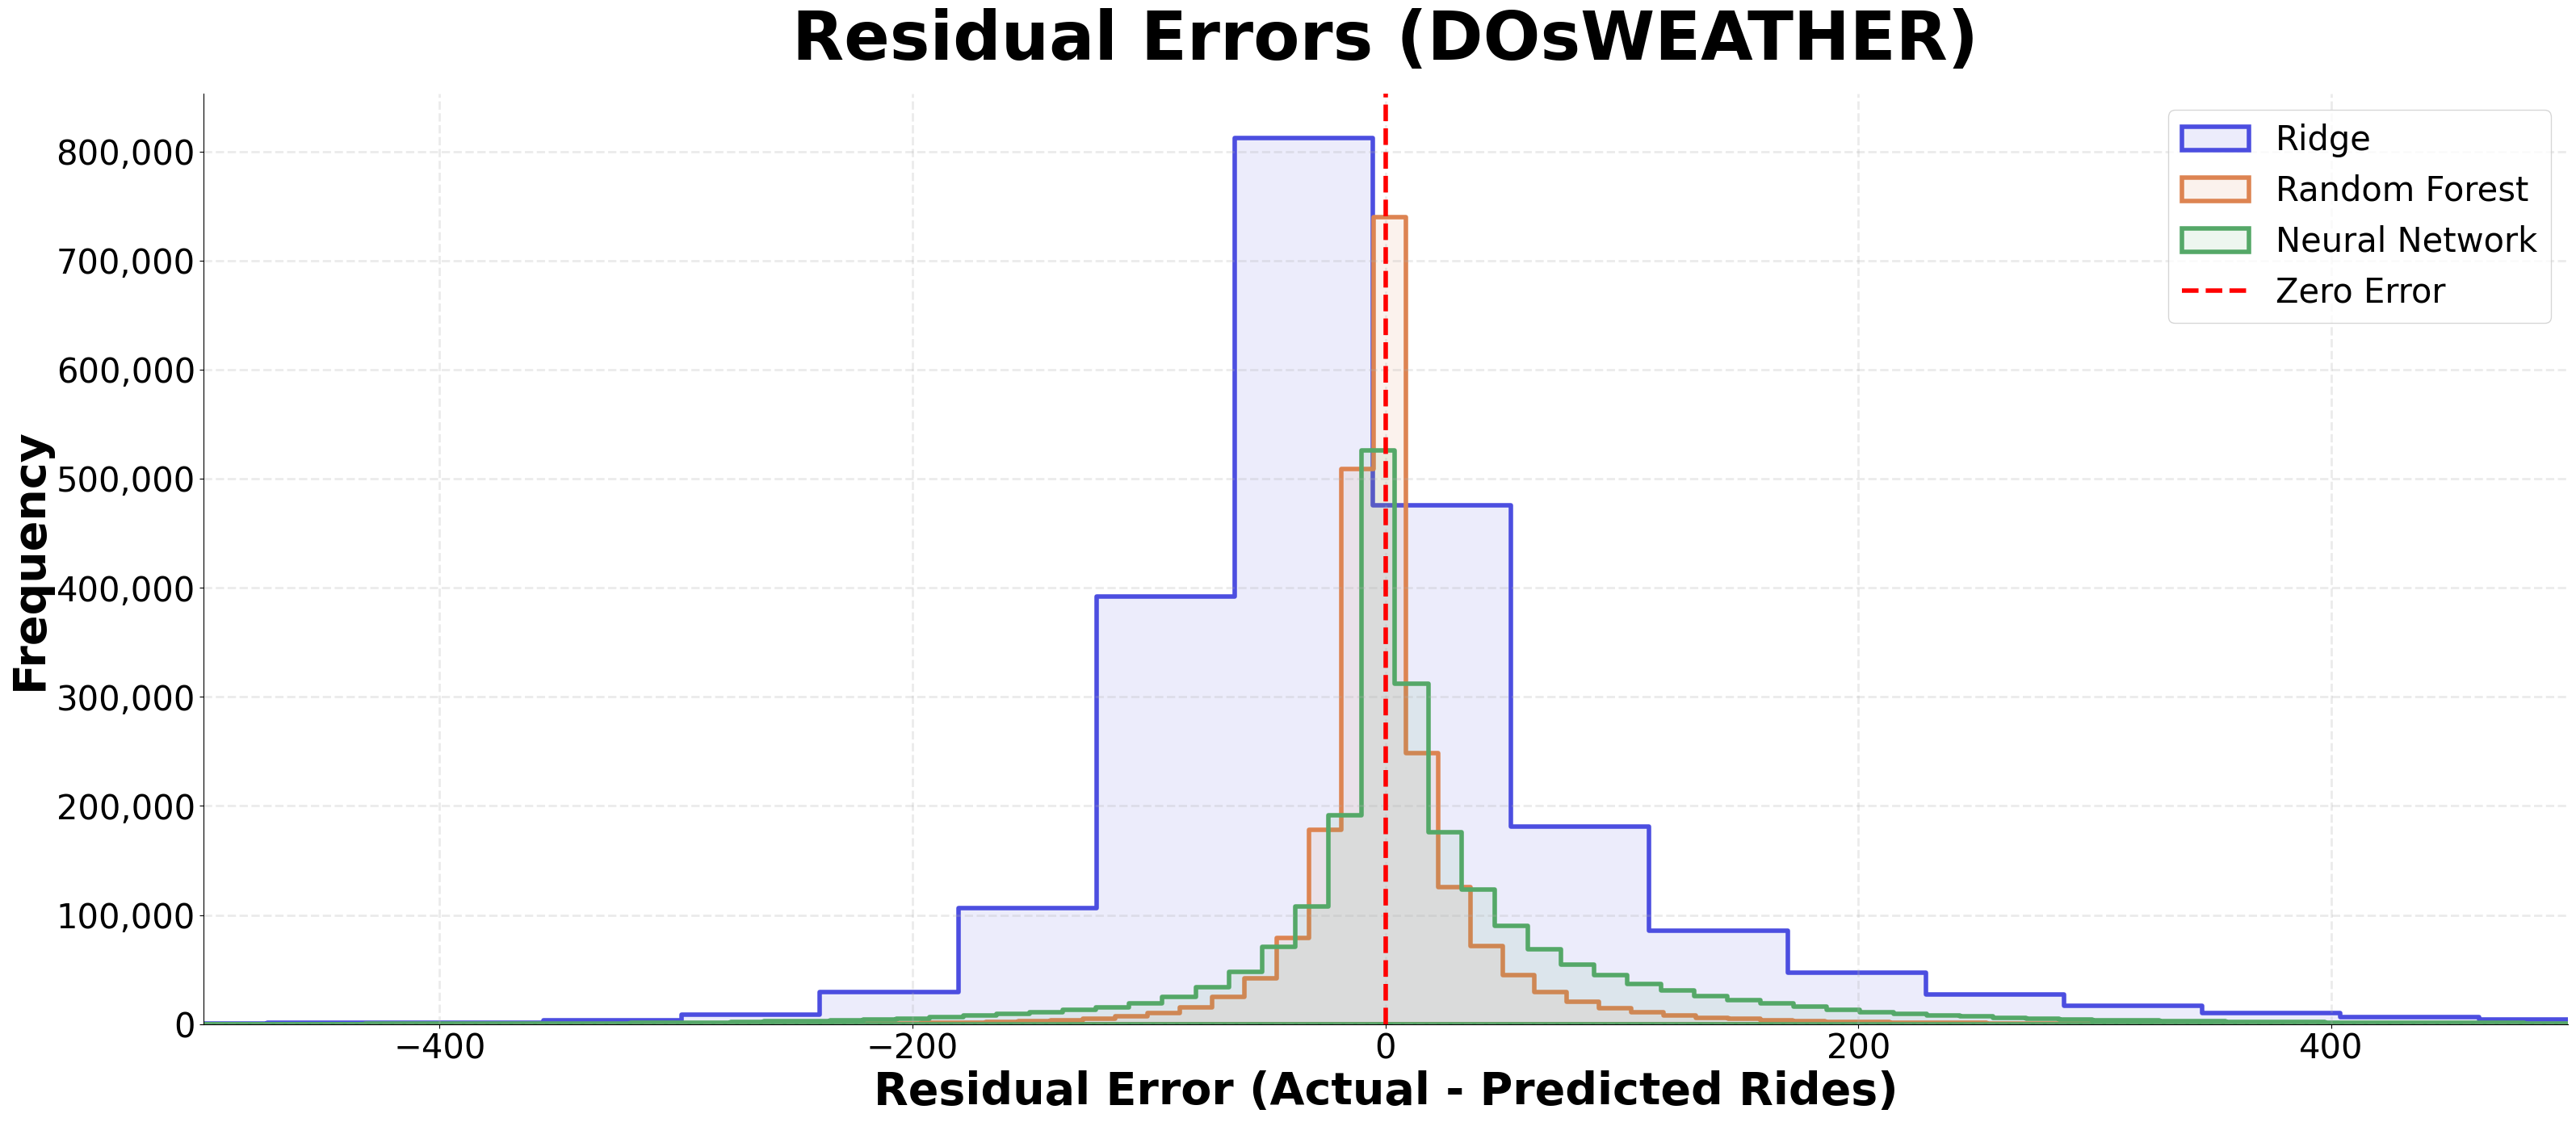

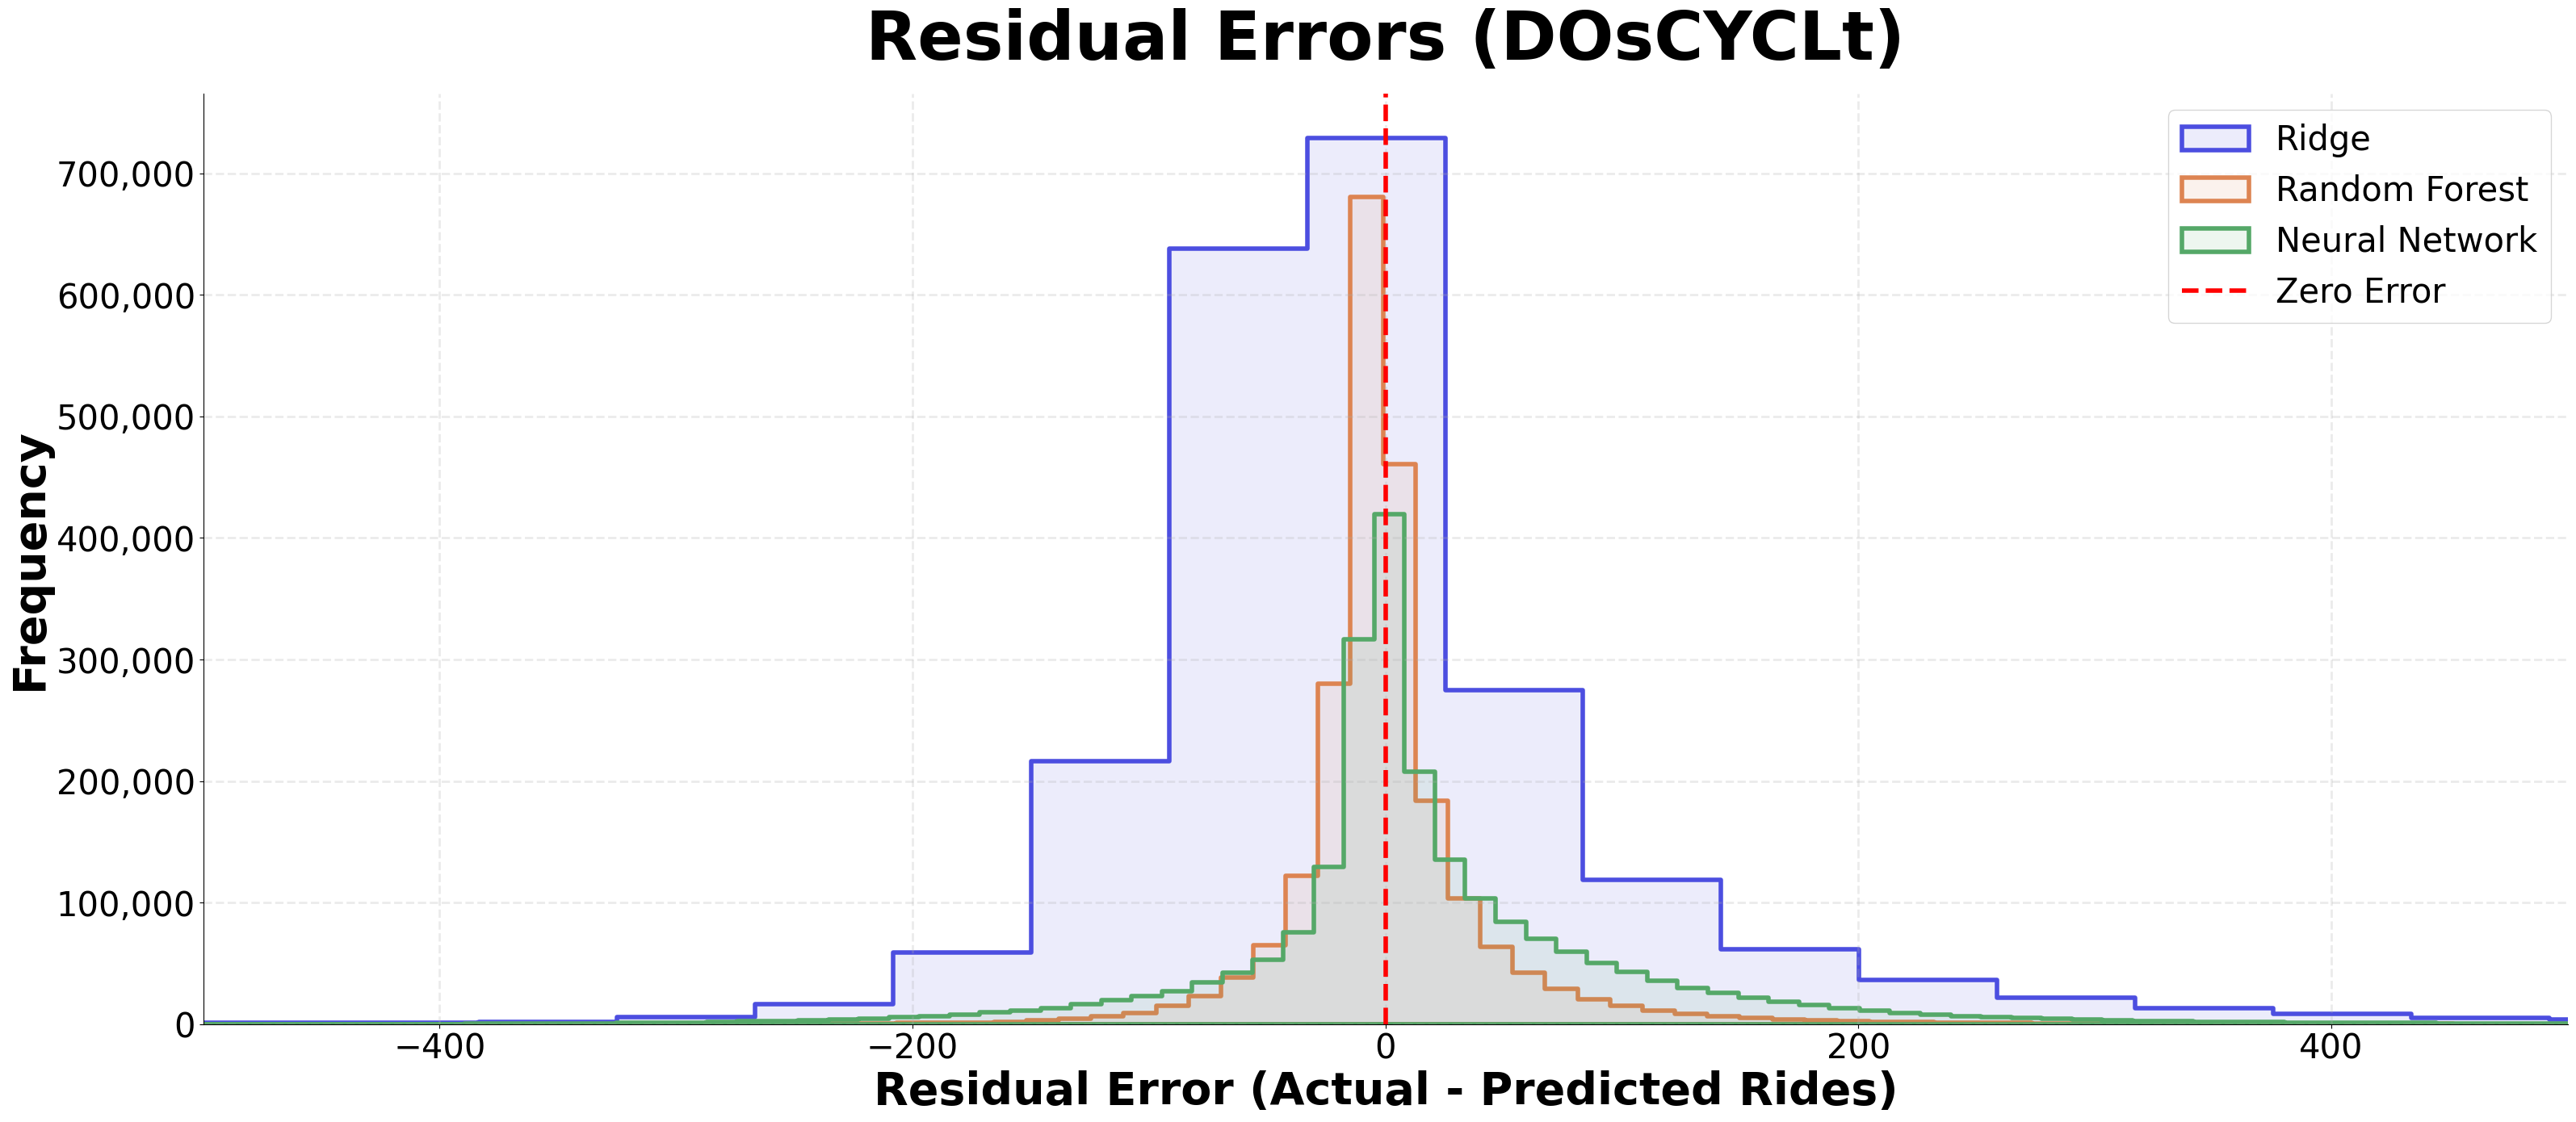

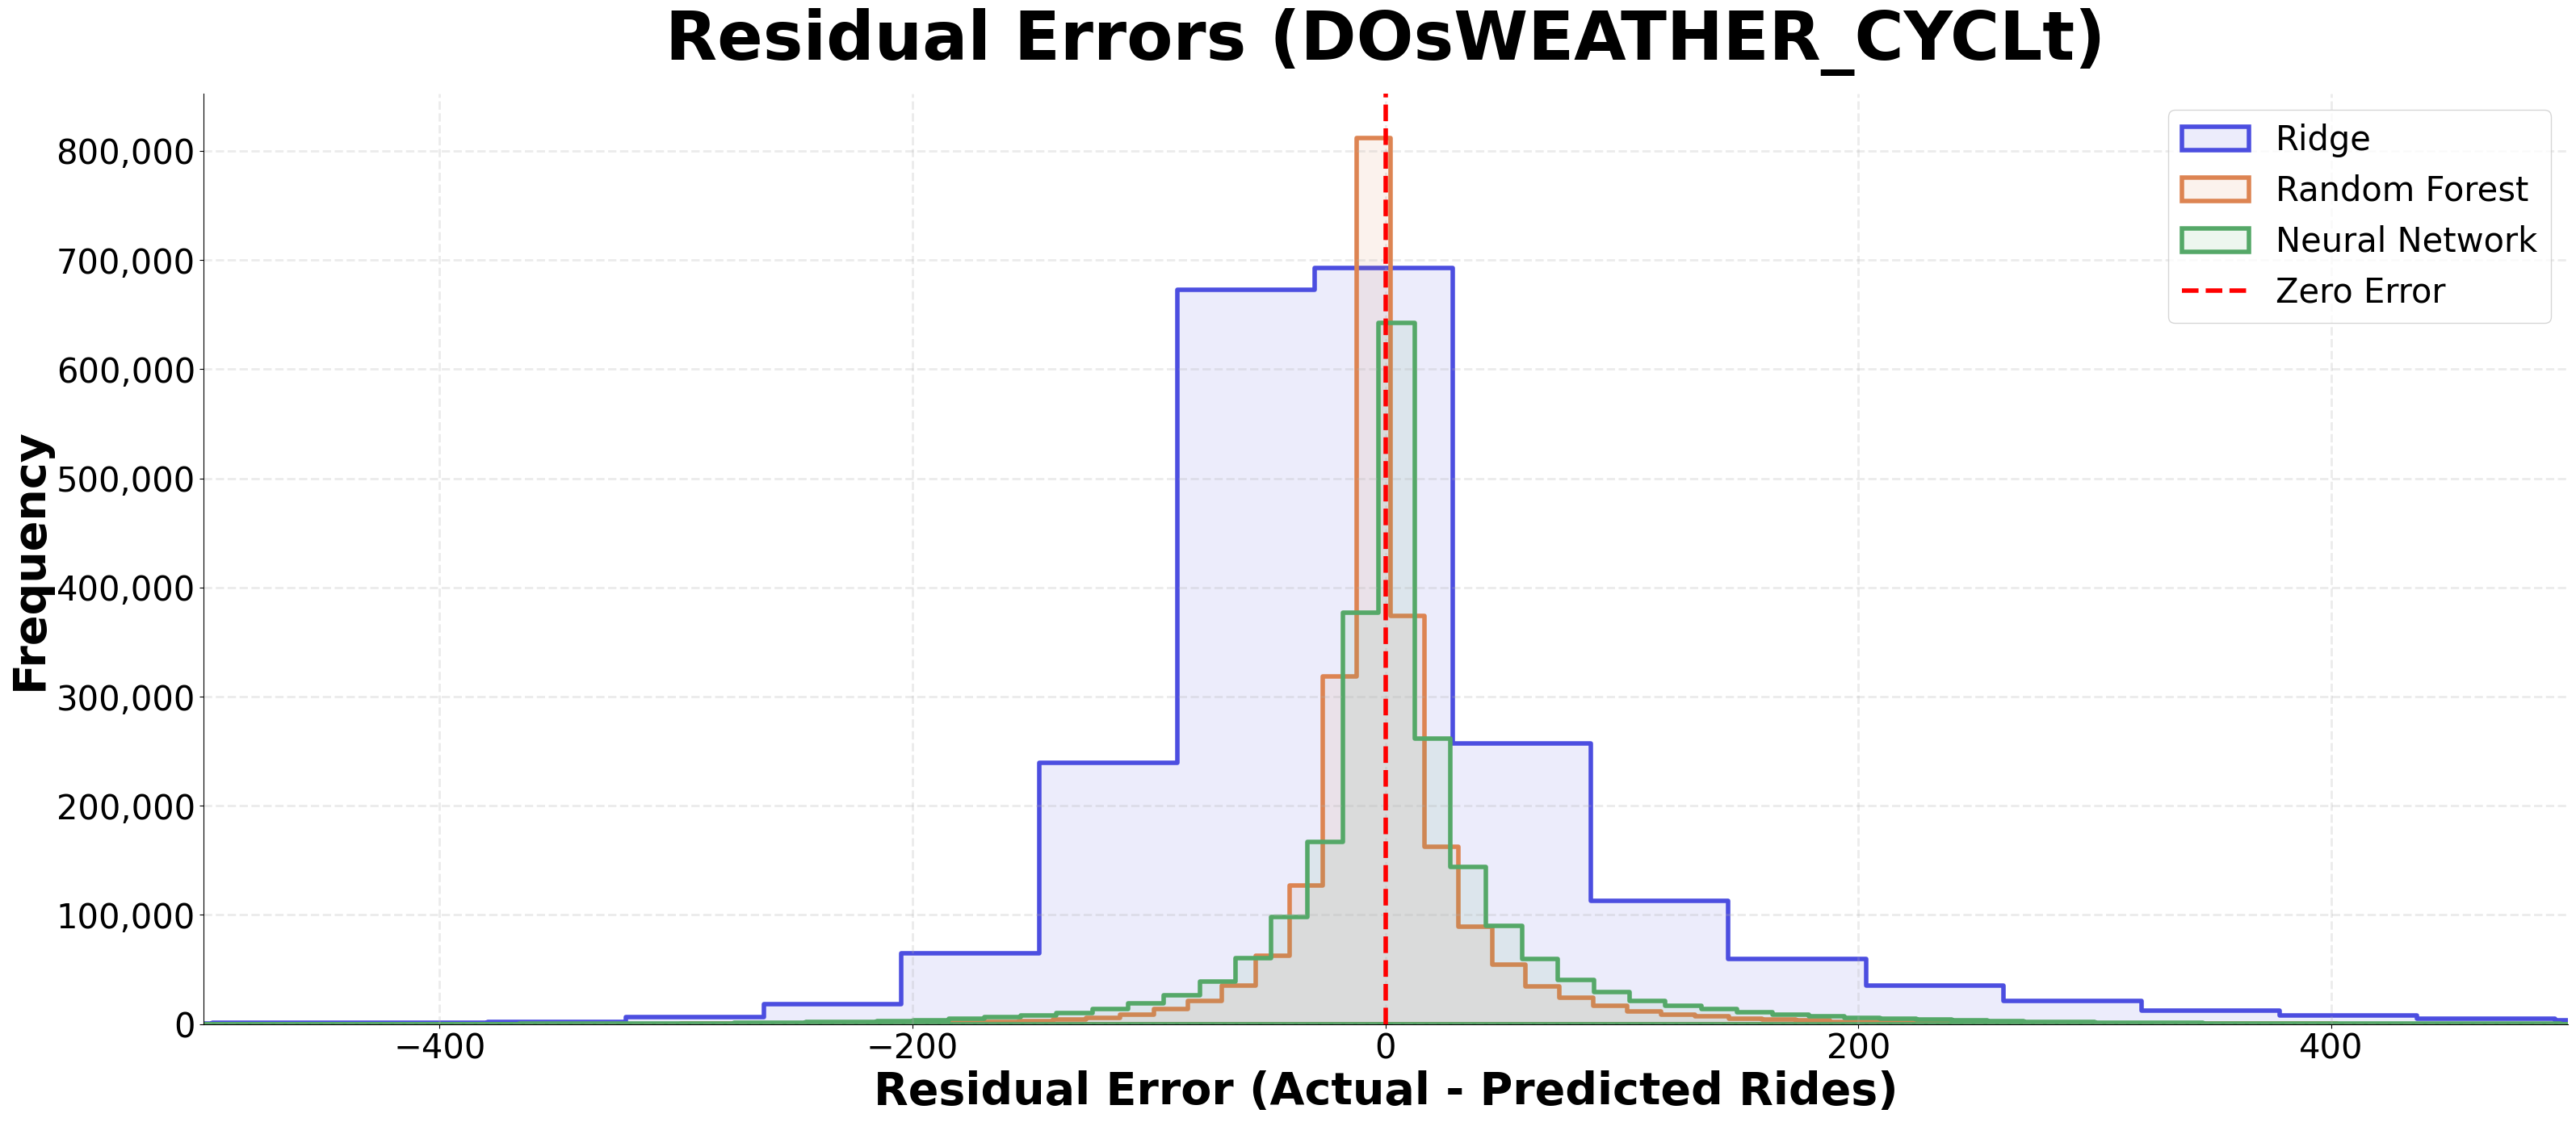

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Identify all dataset variations to iterate through, excluding the target and index columns (AI generated)
dataset_columns = [col for col in DO_Ridge_unscaled.columns if col not in ["Actual", "Date"]]

for dataset in dataset_columns:

    # Calculate residual errors (Actual minus Predicted) for all three model types
    actuals = DO_Ridge_unscaled["Actual"]
    res_ridge = actuals - DO_Ridge_unscaled[dataset]
    res_rf    = actuals - DO_RF_unscaled[dataset]
    res_nn    = actuals - DO_NN_unscaled[dataset]

    # Initialize the figure and plot overlapping step-filled histograms for model comparison
    plt.figure(figsize=(32, 14))
    sns.histplot(res_ridge, bins=200, color="#4C4EE0", label="Ridge", element="step", fill=True, alpha=0.1, linewidth=4)
    sns.histplot(res_rf, bins=200, color="#DD8452", label="Random Forest", element="step", fill=True, alpha=0.1, linewidth=4)
    sns.histplot(res_nn, bins=200, color="#55A868", label="Neural Network", element="step", fill=True, alpha=0.1, linewidth=4)

    # Add a zero-error vertical baseline for visual reference
    plt.axvline(0, color='red', linestyle='--', linewidth=4, label='Zero Error')

    # Apply formatting for titles, labels, font sizes, and add comma separators to the y-axis
    plt.title(f"Residual Errors ({dataset})", fontsize=60, fontweight="bold", pad=30)
    plt.xlabel("Residual Error (Actual - Predicted Rides)", fontweight="bold", fontsize=40)
    plt.ylabel("Frequency", fontweight="bold", fontsize=40)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.grid(True, linestyle='--', alpha=0.25, linewidth=2, zorder=0)

    # Zoom in on the bulk of the distribution, clipping extreme outlier errors beyond ±500
    plt.xlim(-500, 500)

    # Final layout adjustments and legend placement
    sns.despine()
    plt.legend(fontsize=30, loc="upper right")
    plt.tight_layout()

    # Save the output as a high-res PDF and clear the figure from memory for the next loop
    save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Residuals_Histogram_{dataset}.pdf"
    #plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()

Plotting the Residual Distribution across the Year

In [14]:
# Aggregate unscaled Drop-Off predictions into total daily sums for each model type
DO_Ridge_daily = DO_Ridge_unscaled.groupby(DO_Ridge_unscaled.index.dayofyear).sum()
DO_RF_daily = DO_RF_unscaled.groupby(DO_RF_unscaled.index.dayofyear).sum()
DO_NN_daily = DO_NN_unscaled.groupby(DO_NN_unscaled.index.dayofyear).sum()

# Calculate 7-day rolling averages on the daily Drop-Off totals to smooth out weekly seasonality
DO_Ridge_rolling = DO_Ridge_daily.rolling(window=7).mean()
DO_RF_rolling = DO_RF_daily.rolling(window=7).mean()
DO_NN_rolling = DO_NN_daily.rolling(window=7).mean()

# Aggregate unscaled Pick-Up predictions into total daily sums for each model type
PU_Ridge_daily = PU_Ridge_unscaled.groupby(PU_Ridge_unscaled.index.dayofyear).sum()
PU_RF_daily = PU_RF_unscaled.groupby(PU_RF_unscaled.index.dayofyear).sum()
PU_NN_daily = PU_NN_unscaled.groupby(PU_NN_unscaled.index.dayofyear).sum()

# Calculate 7-day rolling averages on the daily Pick-Up totals to smooth out weekly seasonality
PU_Ridge_rolling = PU_Ridge_daily.rolling(window=7).mean()
PU_RF_rolling = PU_RF_daily.rolling(window=7).mean()
PU_NN_rolling = PU_NN_daily.rolling(window=7).mean()

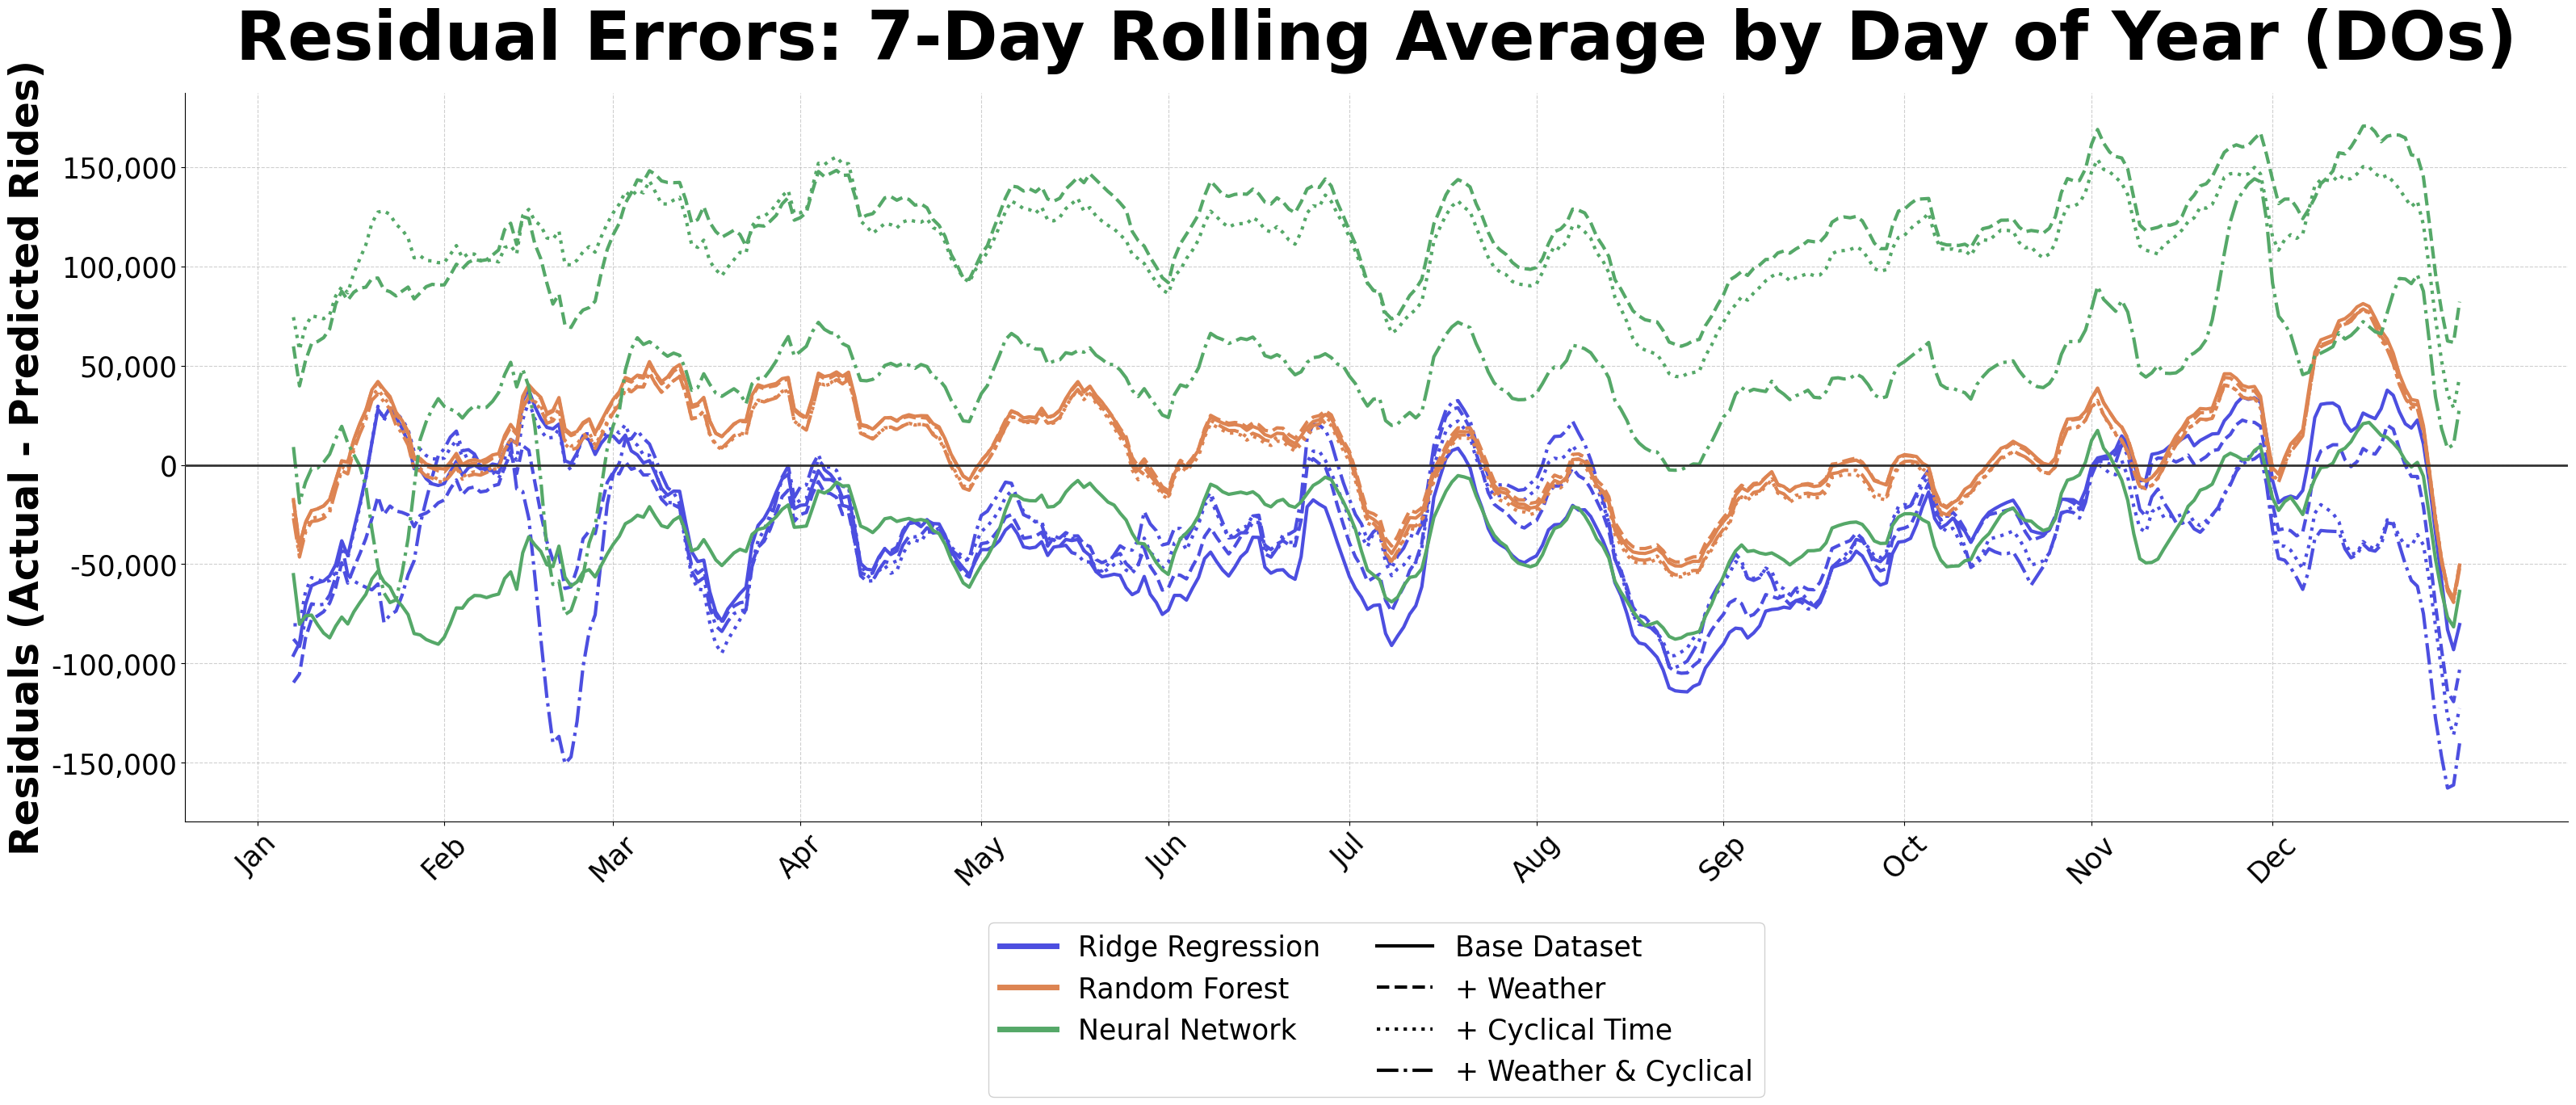

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Setup dictionaries for styles and colors
datasets = {
    'DOs': ('-', 'Base Features Only'),
    'DOsWEATHER': ('--', '+ Weather Features'),
    'DOsCYCLt': (':', '+ Cyclical Time'),
    'DOsWEATHER_CYCLt': ('-.', '+ Weather & Cyclical Time')
}

models = {
    'Ridge': (DO_Ridge_rolling, '#4C4EE0'),
    'Random Forest': (DO_RF_rolling, '#DD8452'),
    'Neural Network': (DO_NN_rolling, '#55A868')
}

fig, ax = plt.subplots(figsize=(32, 14))

# 1. Zero Error Baseline (Replaces the Actuals line)
ax.axhline(0, color='#333333', linestyle='-', linewidth=2, zorder=5)

# 2. Loop through and plot all 12 model residual lines
for model_name, (df_rolling, color) in models.items():
    for col, (linestyle, label) in datasets.items():

        # Calculate the residual of the rolling averages (Actual - Predicted)
        rolling_residual = df_rolling['Actual'] - df_rolling[col]

        ax.plot(
            df_rolling.index,
            rolling_residual,
            color=color,
            linestyle=linestyle,
            linewidth=3,
            alpha=1
        )

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, rotation=45, fontsize=25)

# Format Y-axis with commas (automatically handles negative numbers correctly) (AI generated)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.tick_params(axis='y', labelsize=25)

# Formatting
ax.set_ylabel("Residuals (Actual - Predicted Rides)", fontsize=35, fontweight='bold')
ax.set_title("Residual Errors: 7-Day Rolling Average by Day of Year (DOs)", fontsize=60, fontweight='bold', pad=30)
ax.grid(True, linestyle='--', alpha=0.6)

# --- CUSTOM LEGEND ---
legend_elements = [

    # Models (Colors)
    Line2D([0], [0], color="#4C4EE0", lw=5, label='Ridge Regression'),
    Line2D([0], [0], color="#DD8452", lw=5, label='Random Forest'),
    Line2D([0], [0], color="#55A868", lw=5, label='Neural Network'),
    Line2D([0], [0], color="white", label=' '), # Spacer

    # Datasets (Line Styles)
    Line2D([0], [0], color="black", lw=3, linestyle="-", label='Base Dataset'),
    Line2D([0], [0], color="black", lw=3, linestyle="--", label='+ Weather'),
    Line2D([0], [0], color="black", lw=3, linestyle=":", label='+ Cyclical Time'),
    Line2D([0], [0], color="black", lw=3, linestyle="-.", label='+ Weather & Cyclical')
]

# Place legend cleanly outside the plot area
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fontsize=25, framealpha=0.9, ncol=2)

# Use spines cleanup
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

save_path = "drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Residuals7DaysAvgDOs.pdf"
#plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

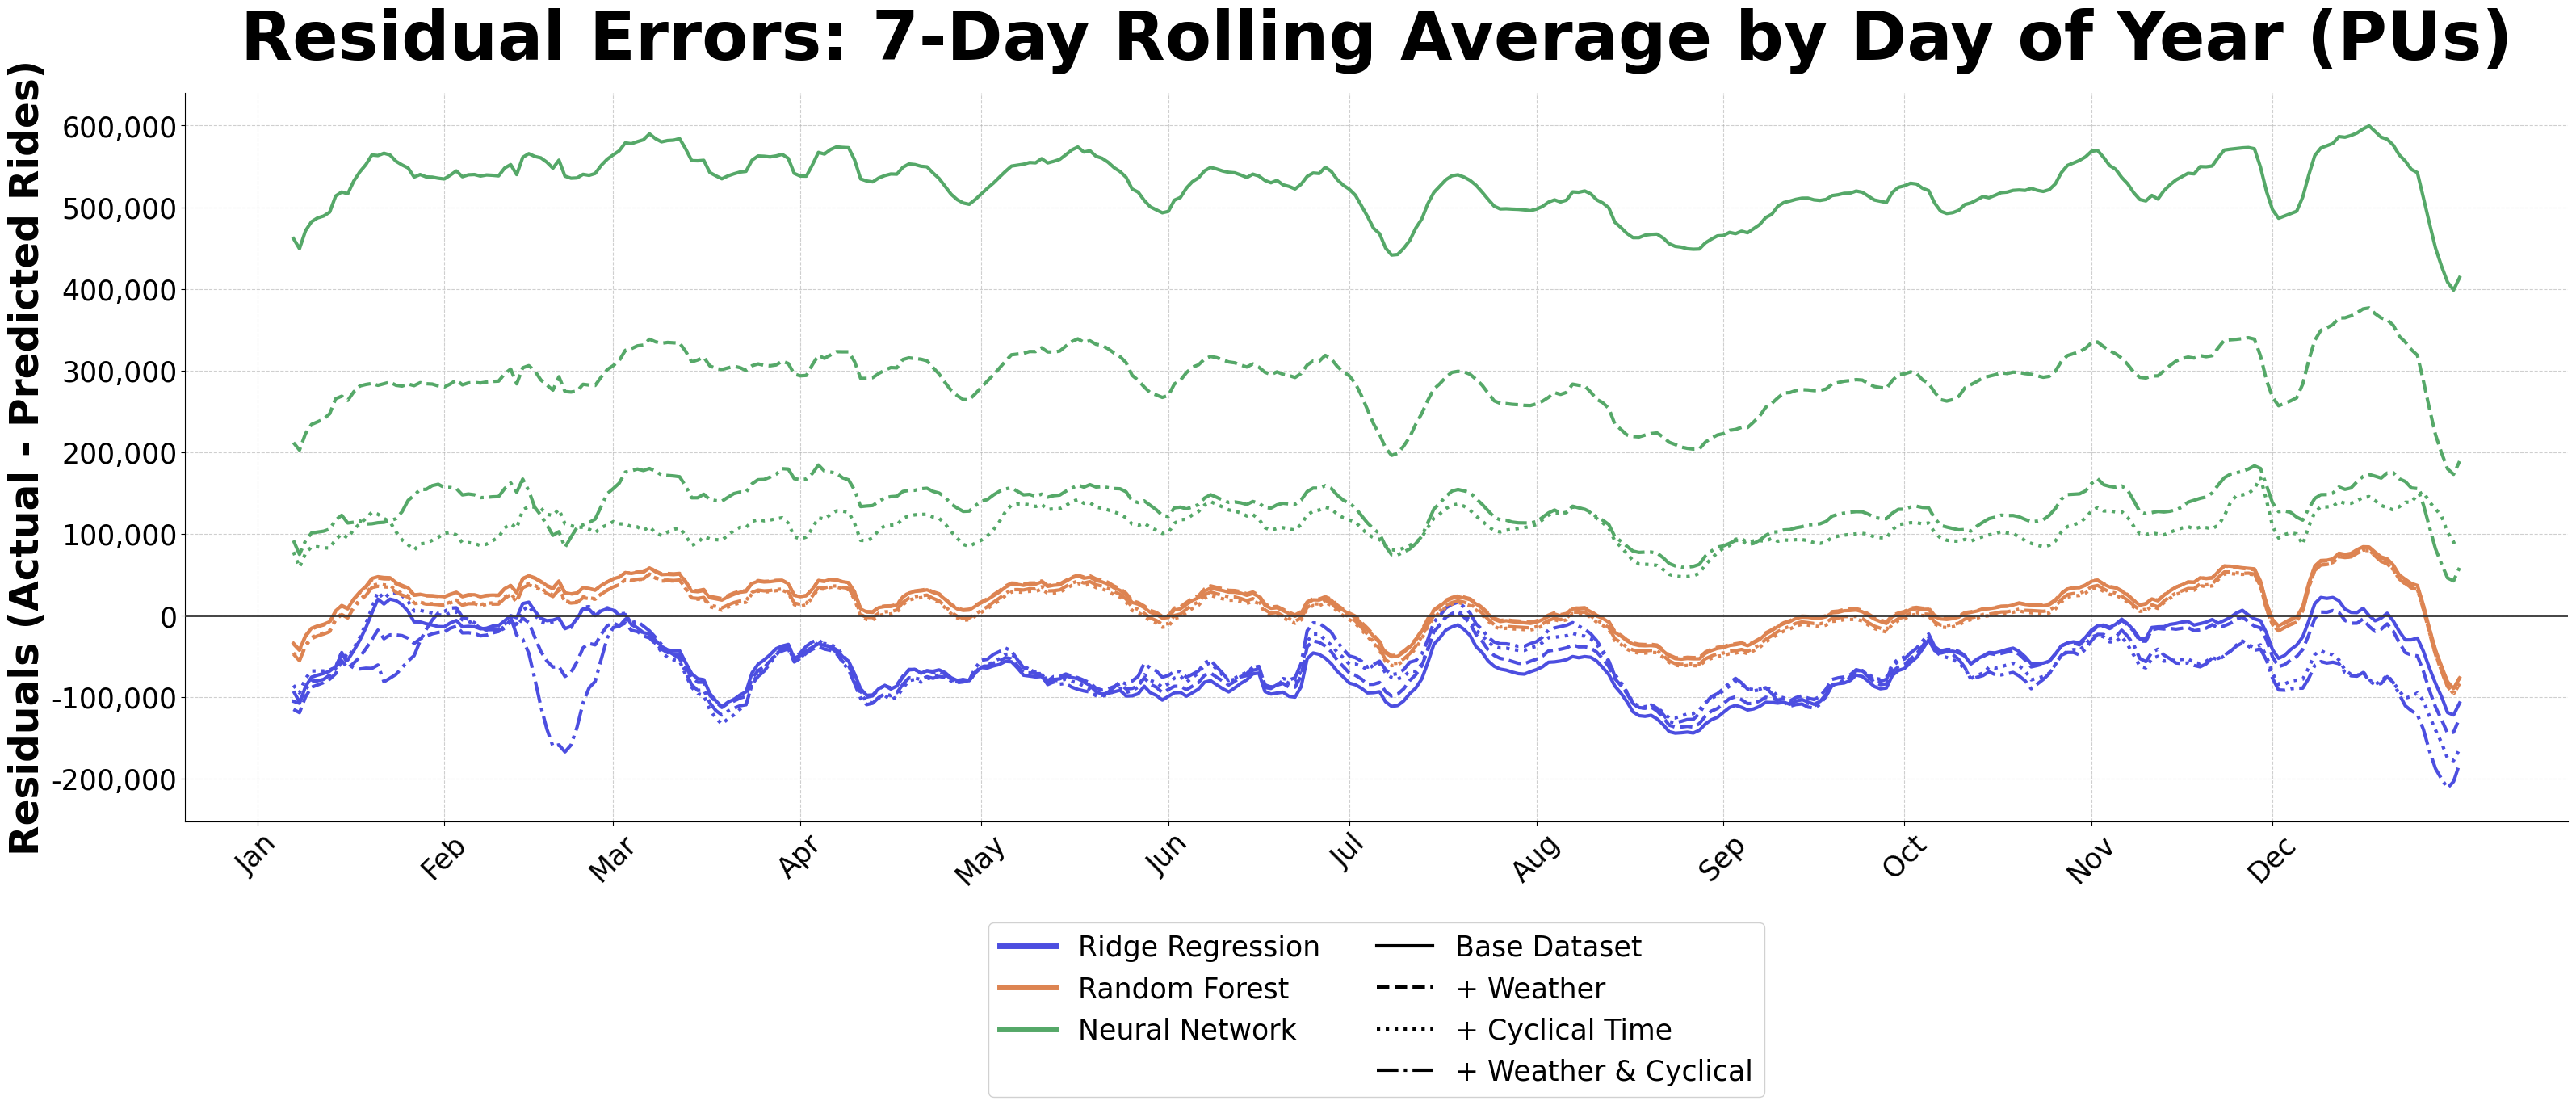

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Setup dictionaries for styles and colors
datasets = {
    'PUs': ('-', 'Base Features Only'),
    'PUsWEATHER': ('--', '+ Weather Features'),
    'PUsCYCLt': (':', '+ Cyclical Time'),
    'PUsWEATHER_CYCLt': ('-.', '+ Weather & Cyclical Time')
}

models = {
    'Ridge': (PU_Ridge_rolling, '#4C4EE0'),
    'Random Forest': (PU_RF_rolling, '#DD8452'),
    'Neural Network': (PU_NN_rolling, '#55A868')
}

fig, ax = plt.subplots(figsize=(32, 14))

# 1. Zero Error Baseline (Replaces the Actuals line)
ax.axhline(0, color='#333333', linestyle='-', linewidth=2, zorder=5)

# 2. Loop through and plot all 12 model residual lines
for model_name, (df_rolling, color) in models.items():
    for col, (linestyle, label) in datasets.items():

        # Calculate the residual of the rolling averages (Actual - Predicted)
        rolling_residual = df_rolling['Actual'] - df_rolling[col]

        ax.plot(
            df_rolling.index,
            rolling_residual,
            color=color,
            linestyle=linestyle,
            linewidth=3,
            alpha=1
        )

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, rotation=45, fontsize=25)

# Format Y-axis with commas (automatically handles negative numbers correctly) (AI generated)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.tick_params(axis='y', labelsize=25)

# Formatting
ax.set_ylabel("Residuals (Actual - Predicted Rides)", fontsize=35, fontweight='bold')
ax.set_title("Residual Errors: 7-Day Rolling Average by Day of Year (PUs)", fontsize=60, fontweight='bold', pad=30)
ax.grid(True, linestyle='--', alpha=0.6)

# --- CUSTOM LEGEND ---
legend_elements = [

    # Models (Colors)
    Line2D([0], [0], color="#4C4EE0", lw=5, label='Ridge Regression'),
    Line2D([0], [0], color="#DD8452", lw=5, label='Random Forest'),
    Line2D([0], [0], color="#55A868", lw=5, label='Neural Network'),
    Line2D([0], [0], color="white", label=' '), # Spacer

    # Datasets (Line Styles)
    Line2D([0], [0], color="black", lw=3, linestyle="-", label='Base Dataset'),
    Line2D([0], [0], color="black", lw=3, linestyle="--", label='+ Weather'),
    Line2D([0], [0], color="black", lw=3, linestyle=":", label='+ Cyclical Time'),
    Line2D([0], [0], color="black", lw=3, linestyle="-.", label='+ Weather & Cyclical')
]

# Place legend cleanly outside the plot area
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fontsize=25, framealpha=0.9, ncol=2)

# Use spines cleanup
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

save_path = "drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/Residuals7DaysAvgPUs.pdf"
#plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

Residuals Heatmap by Day of the Week and Hour of the Day

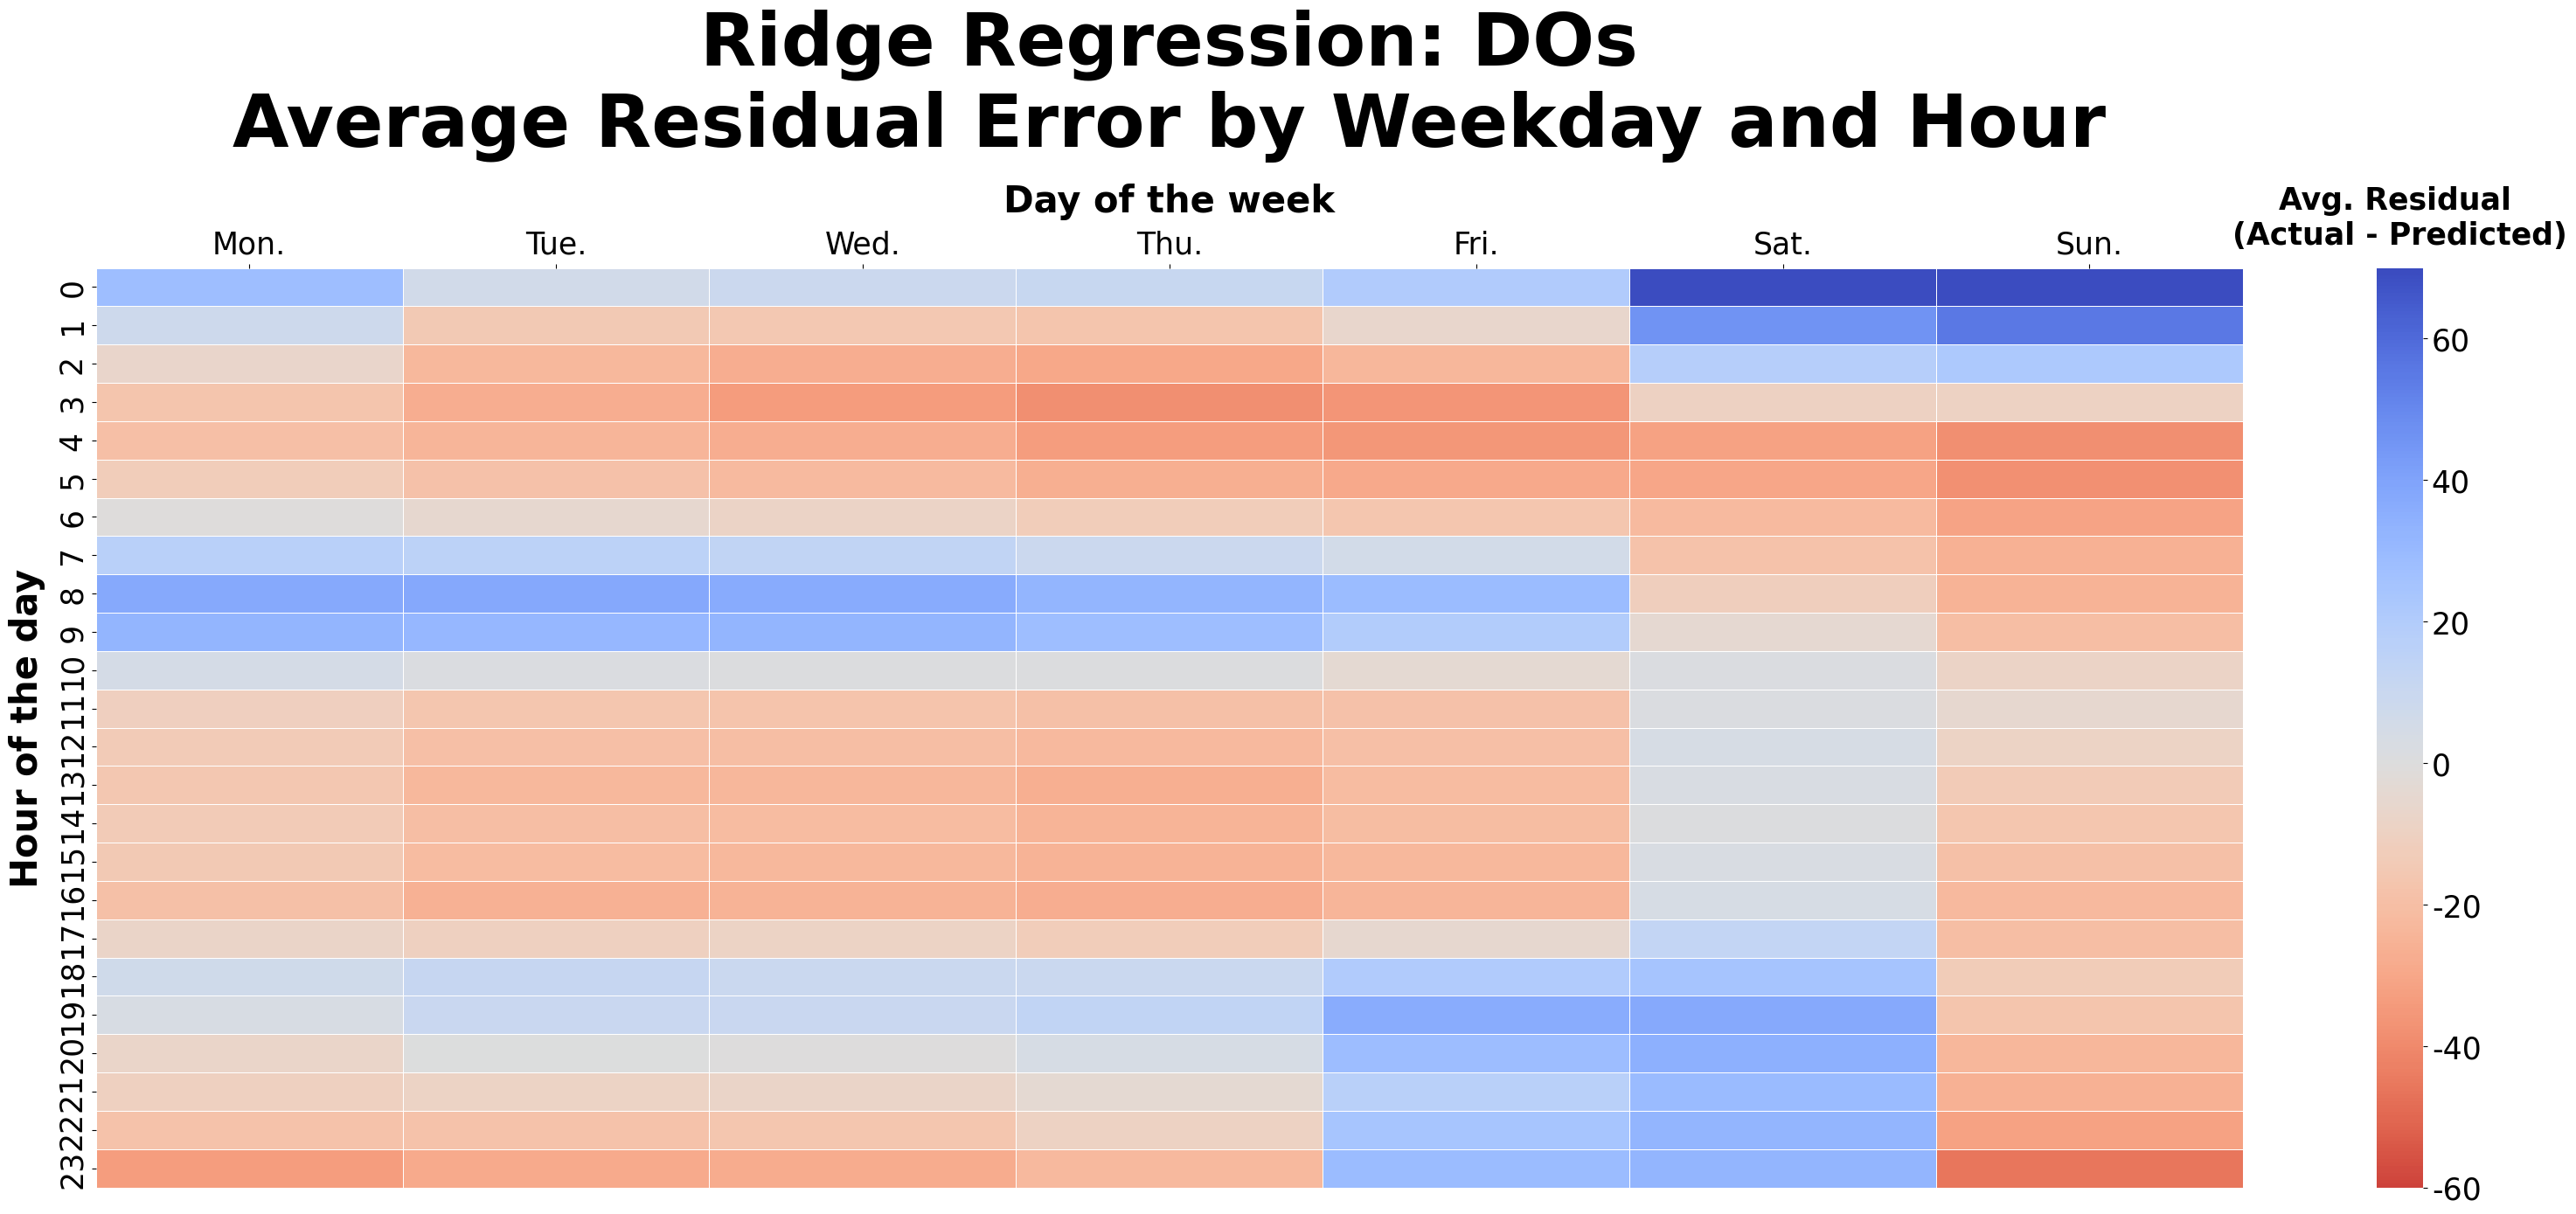

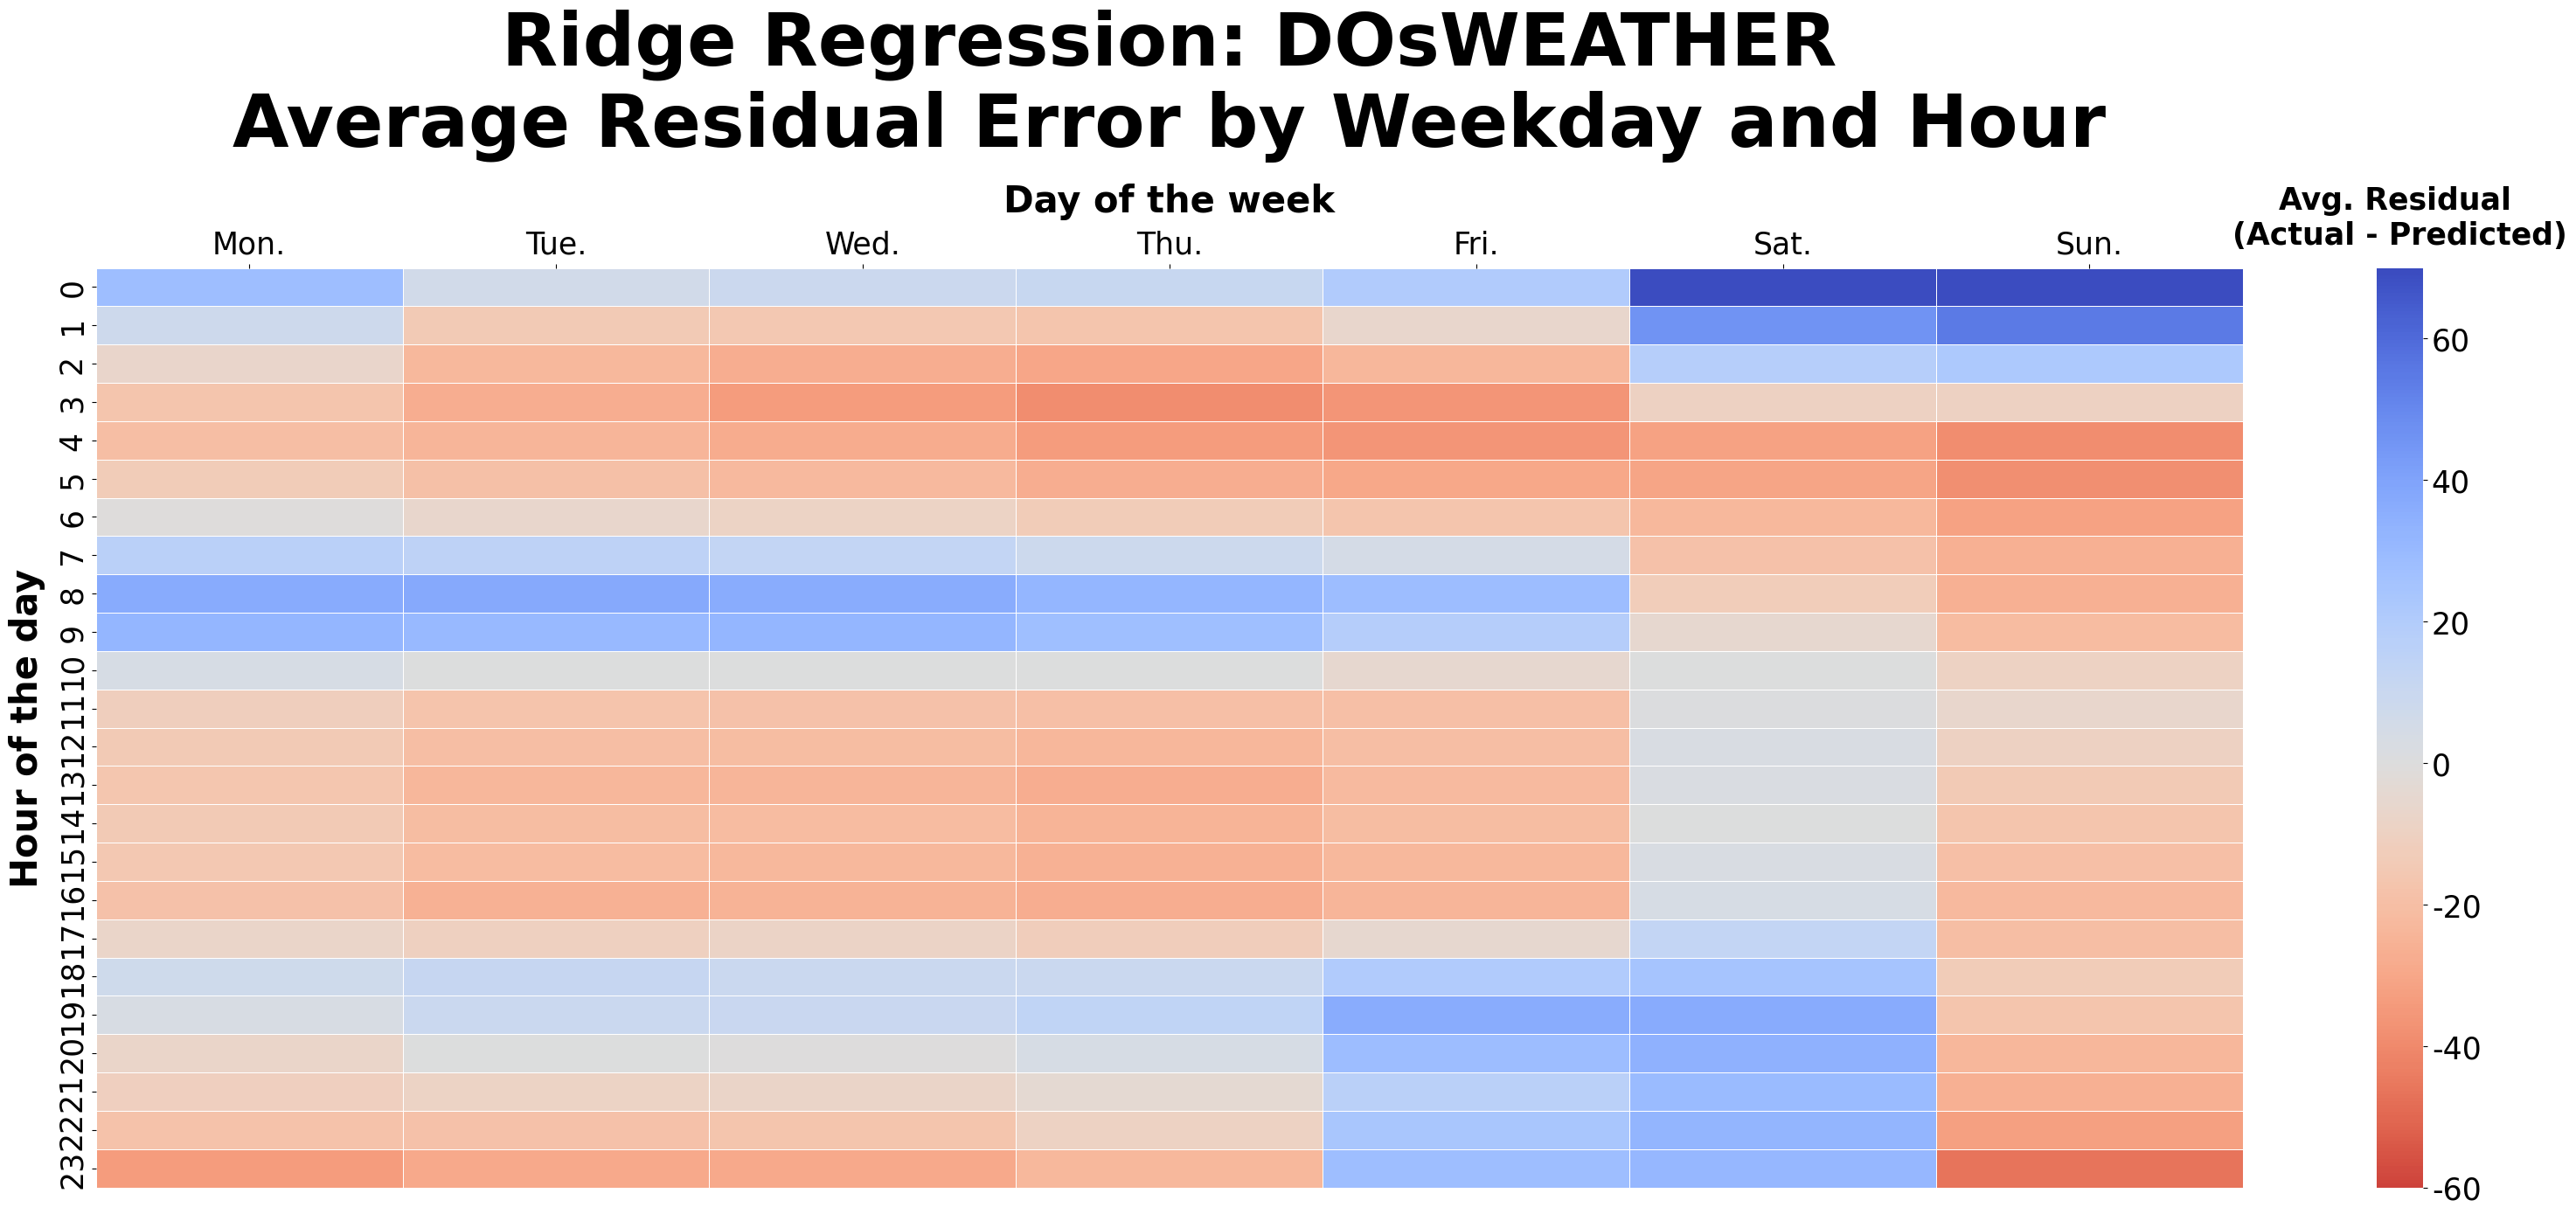

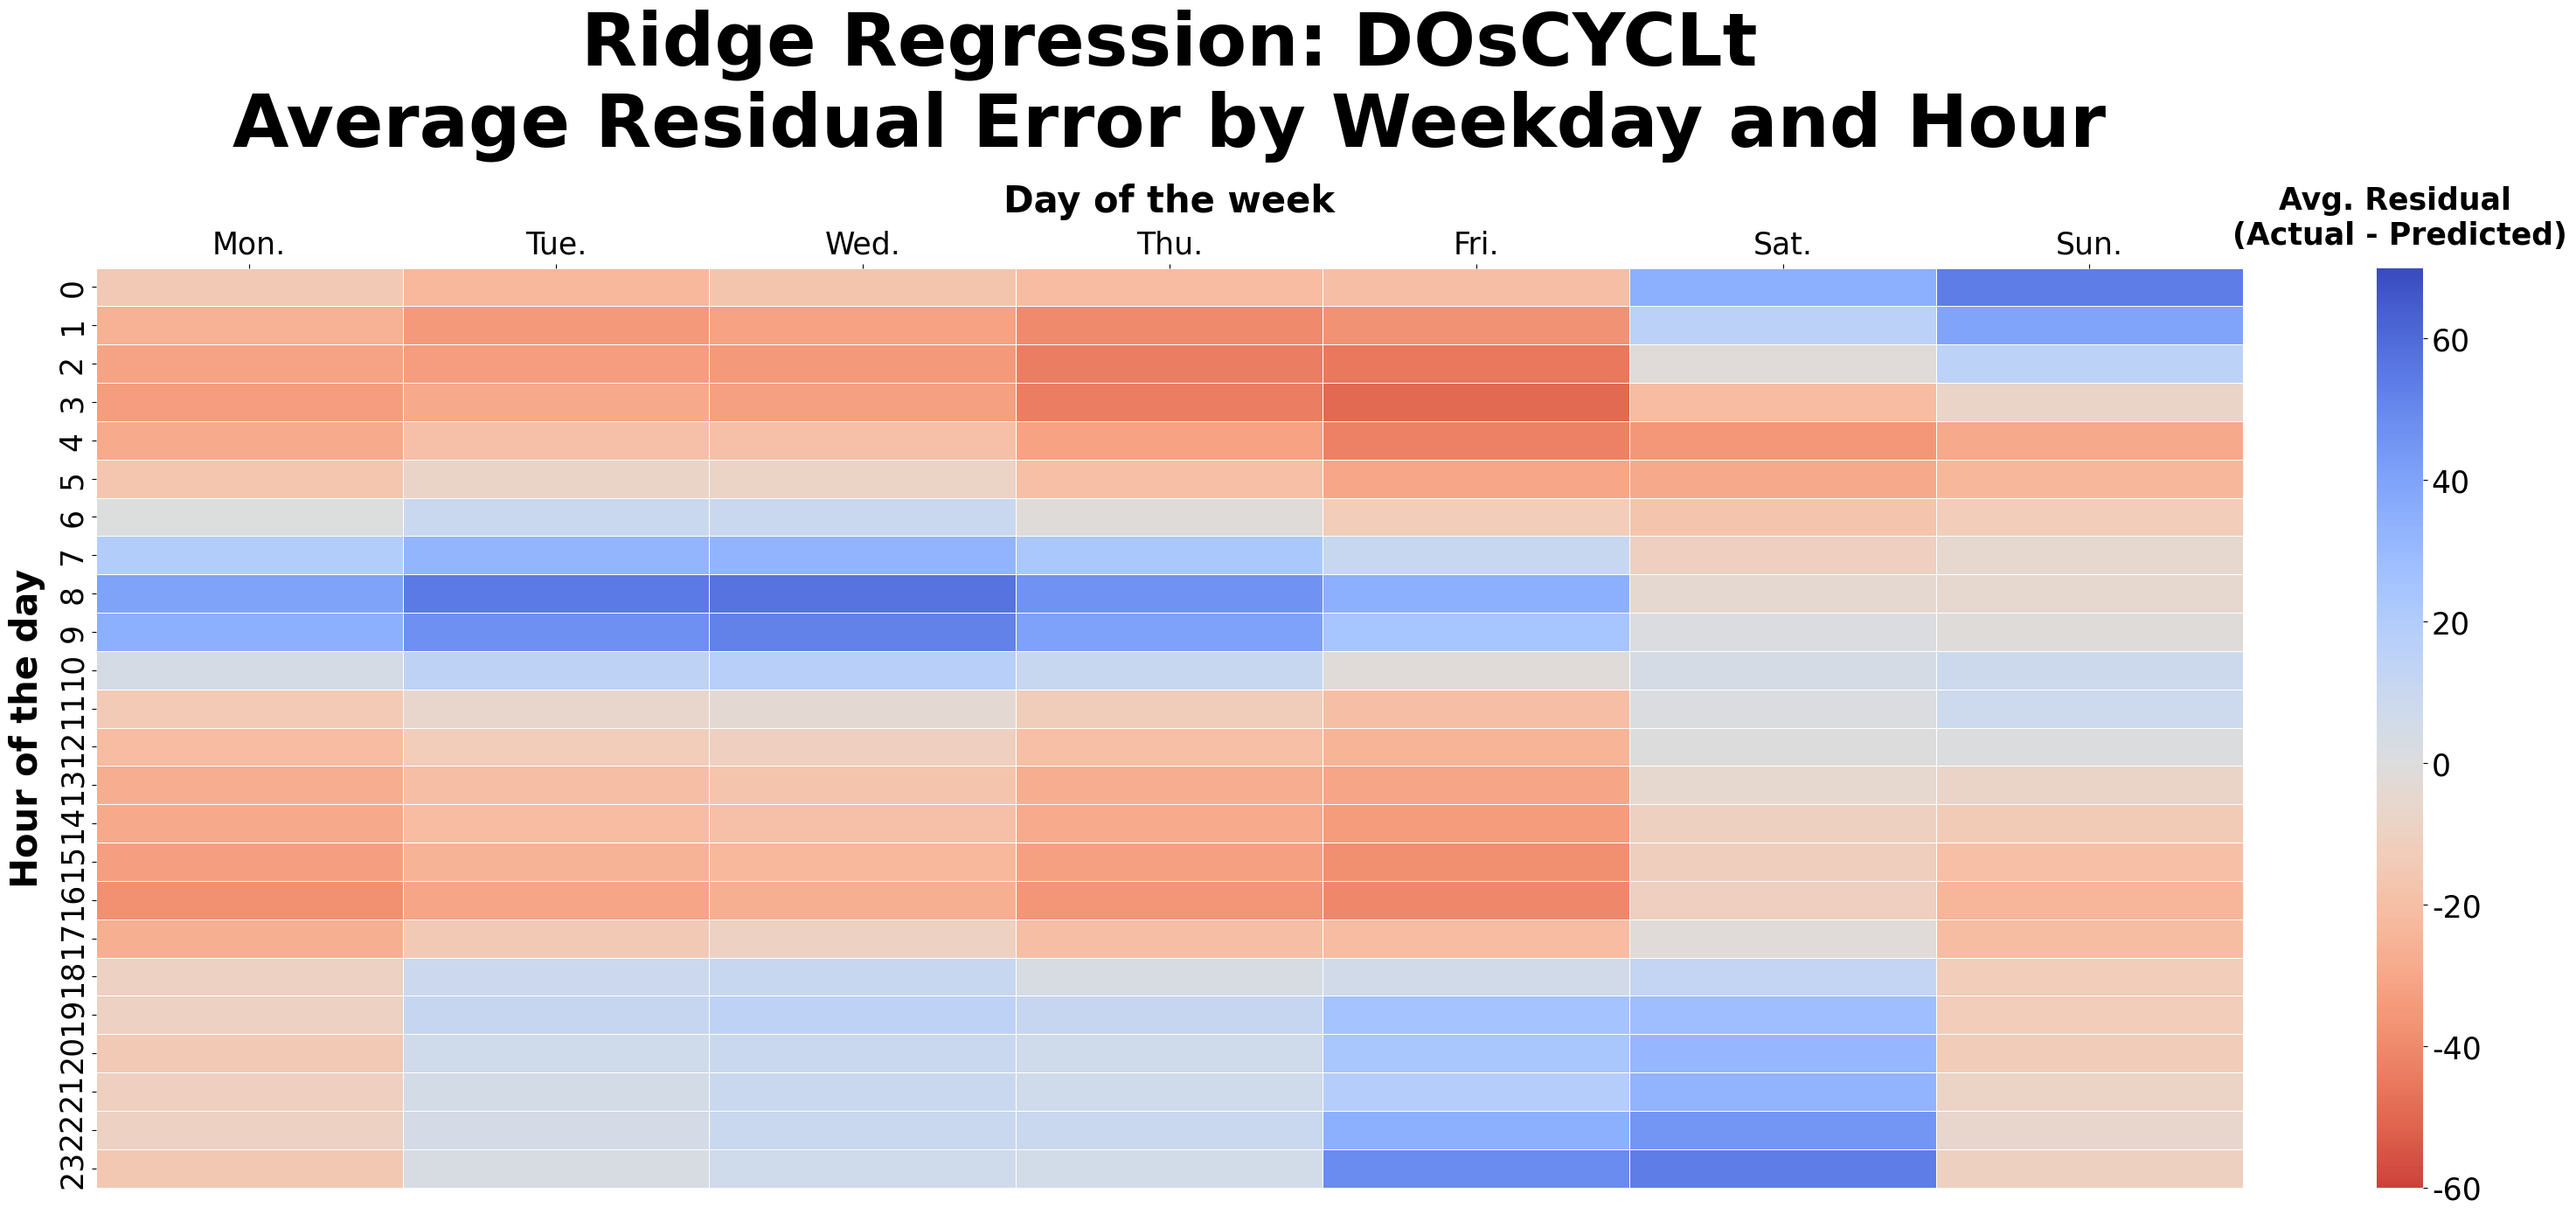

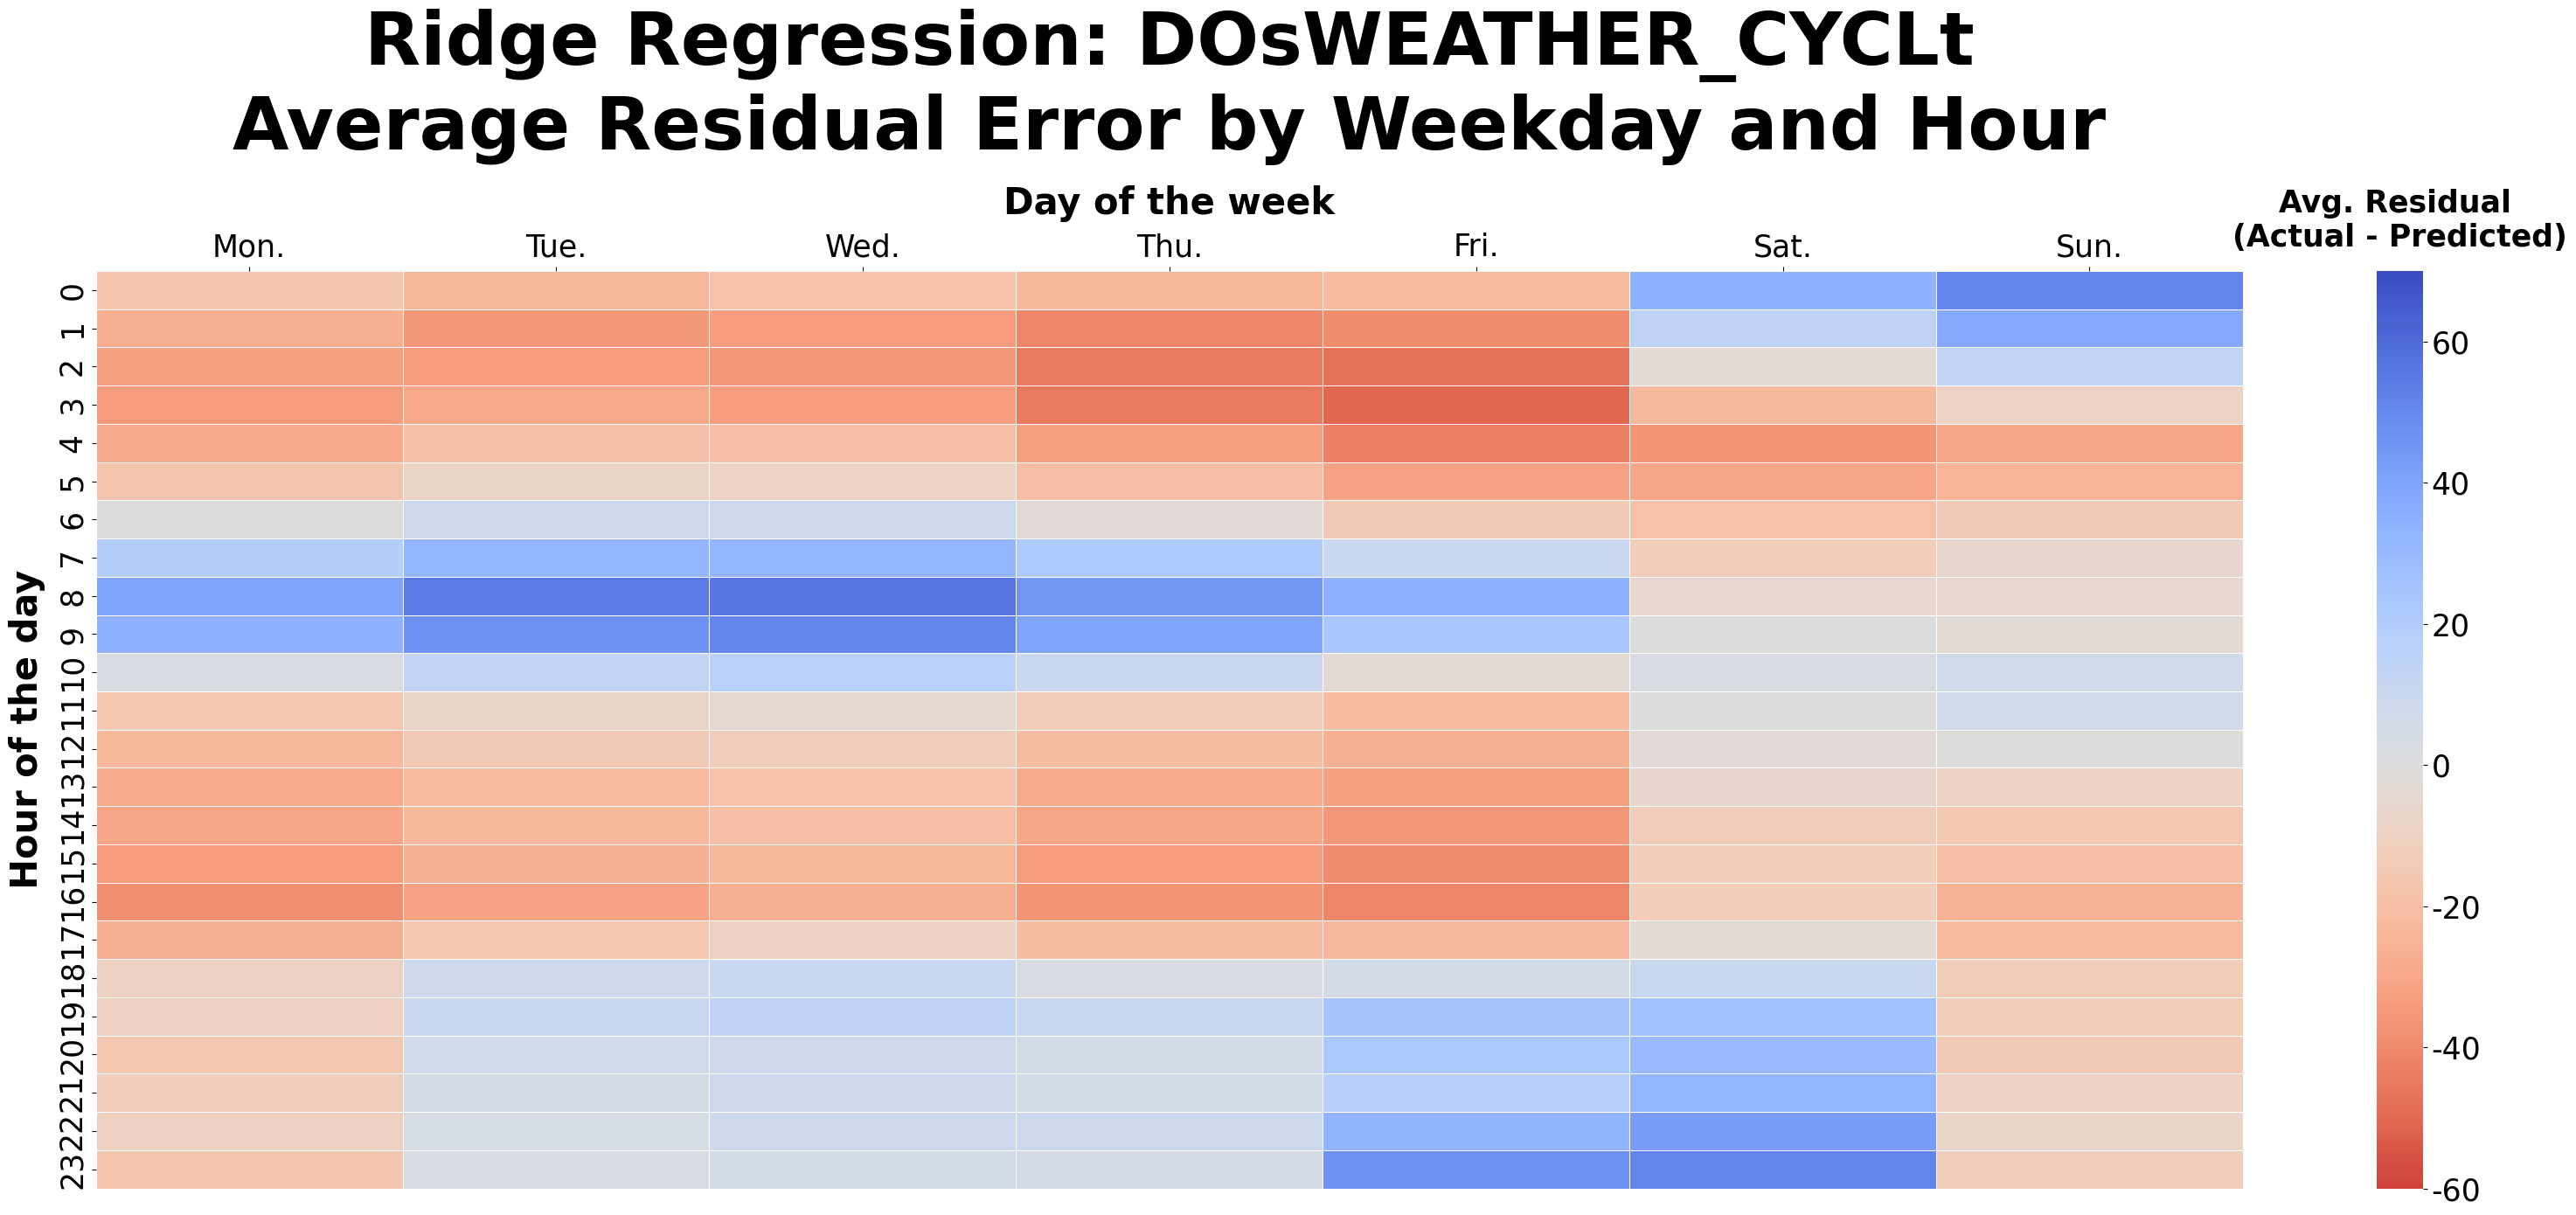

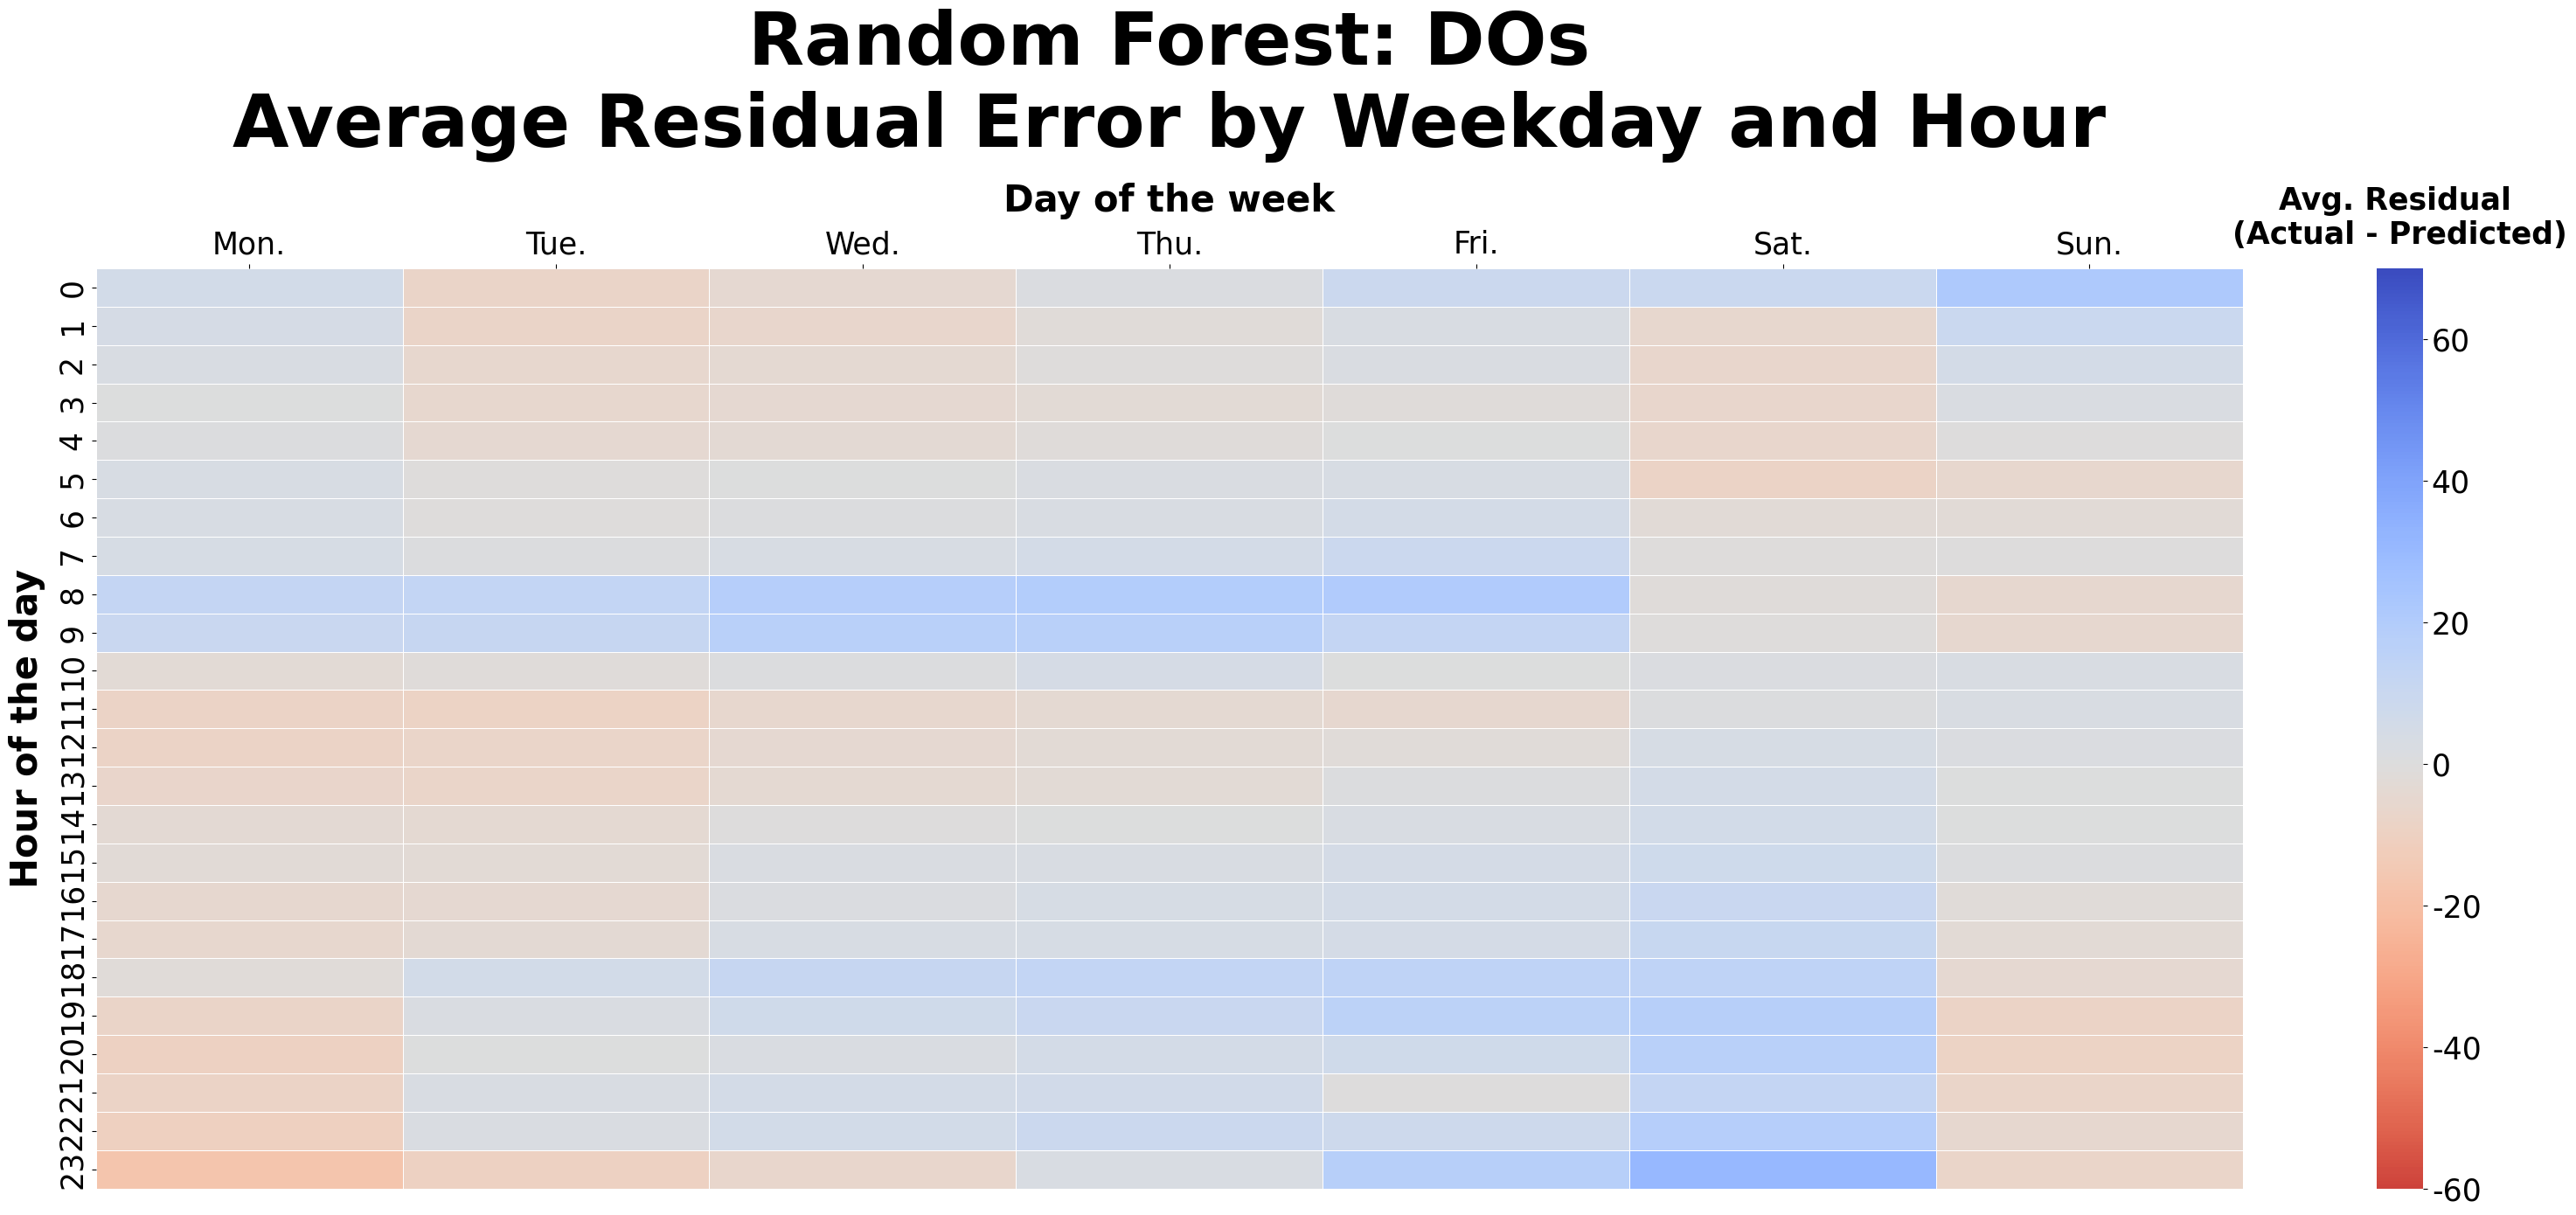

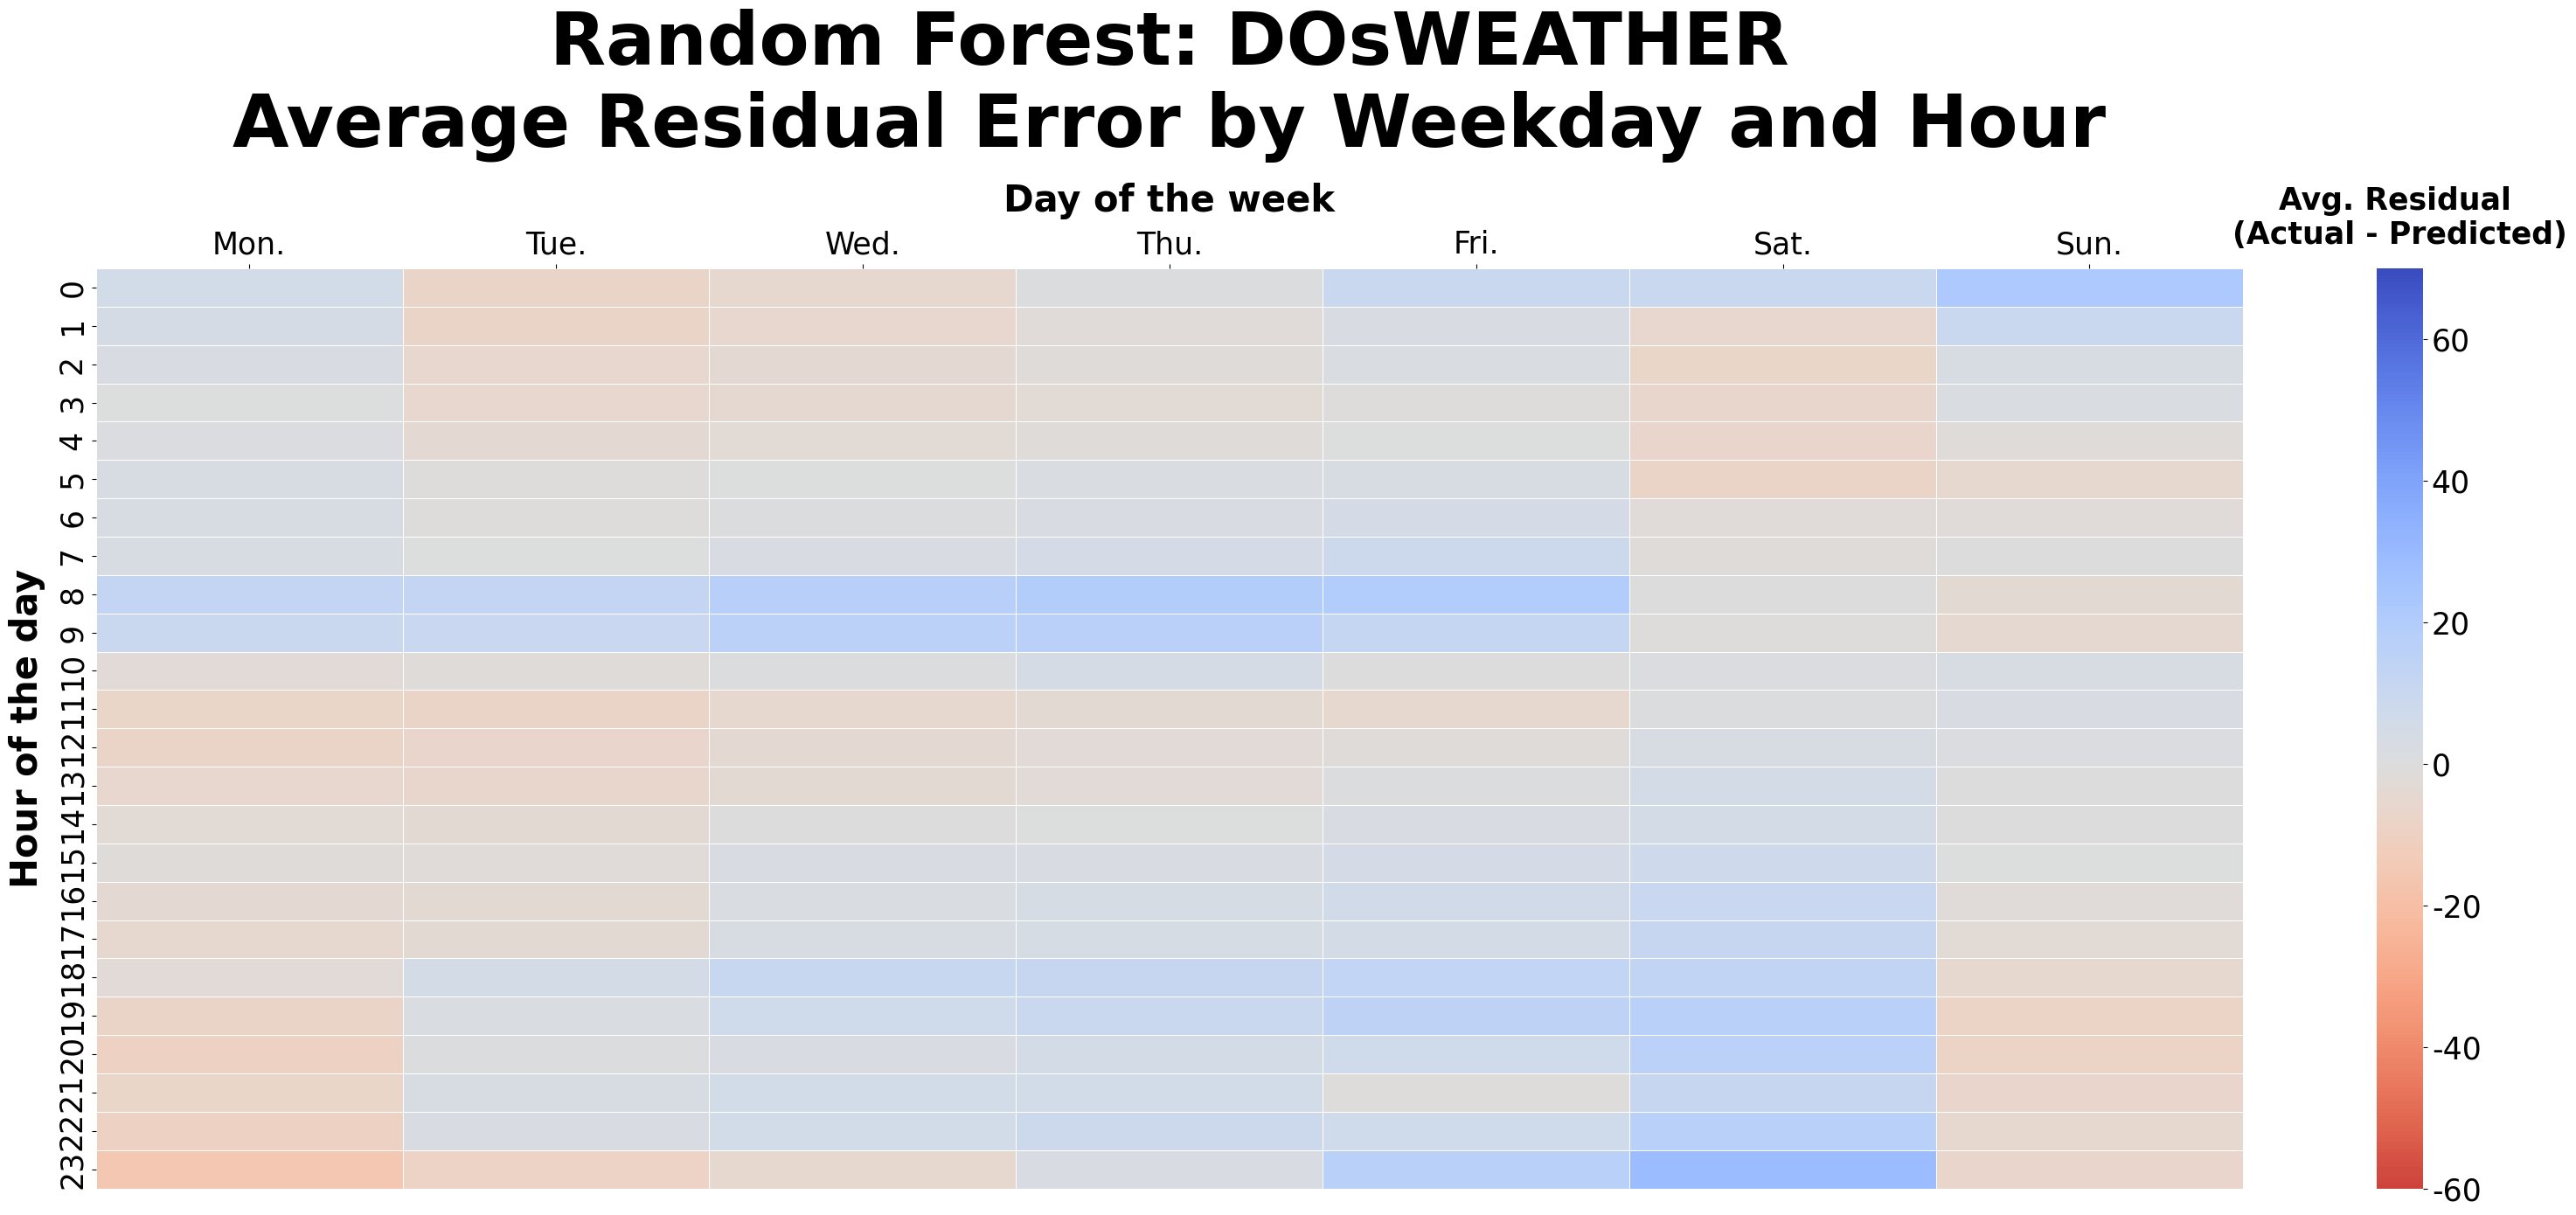

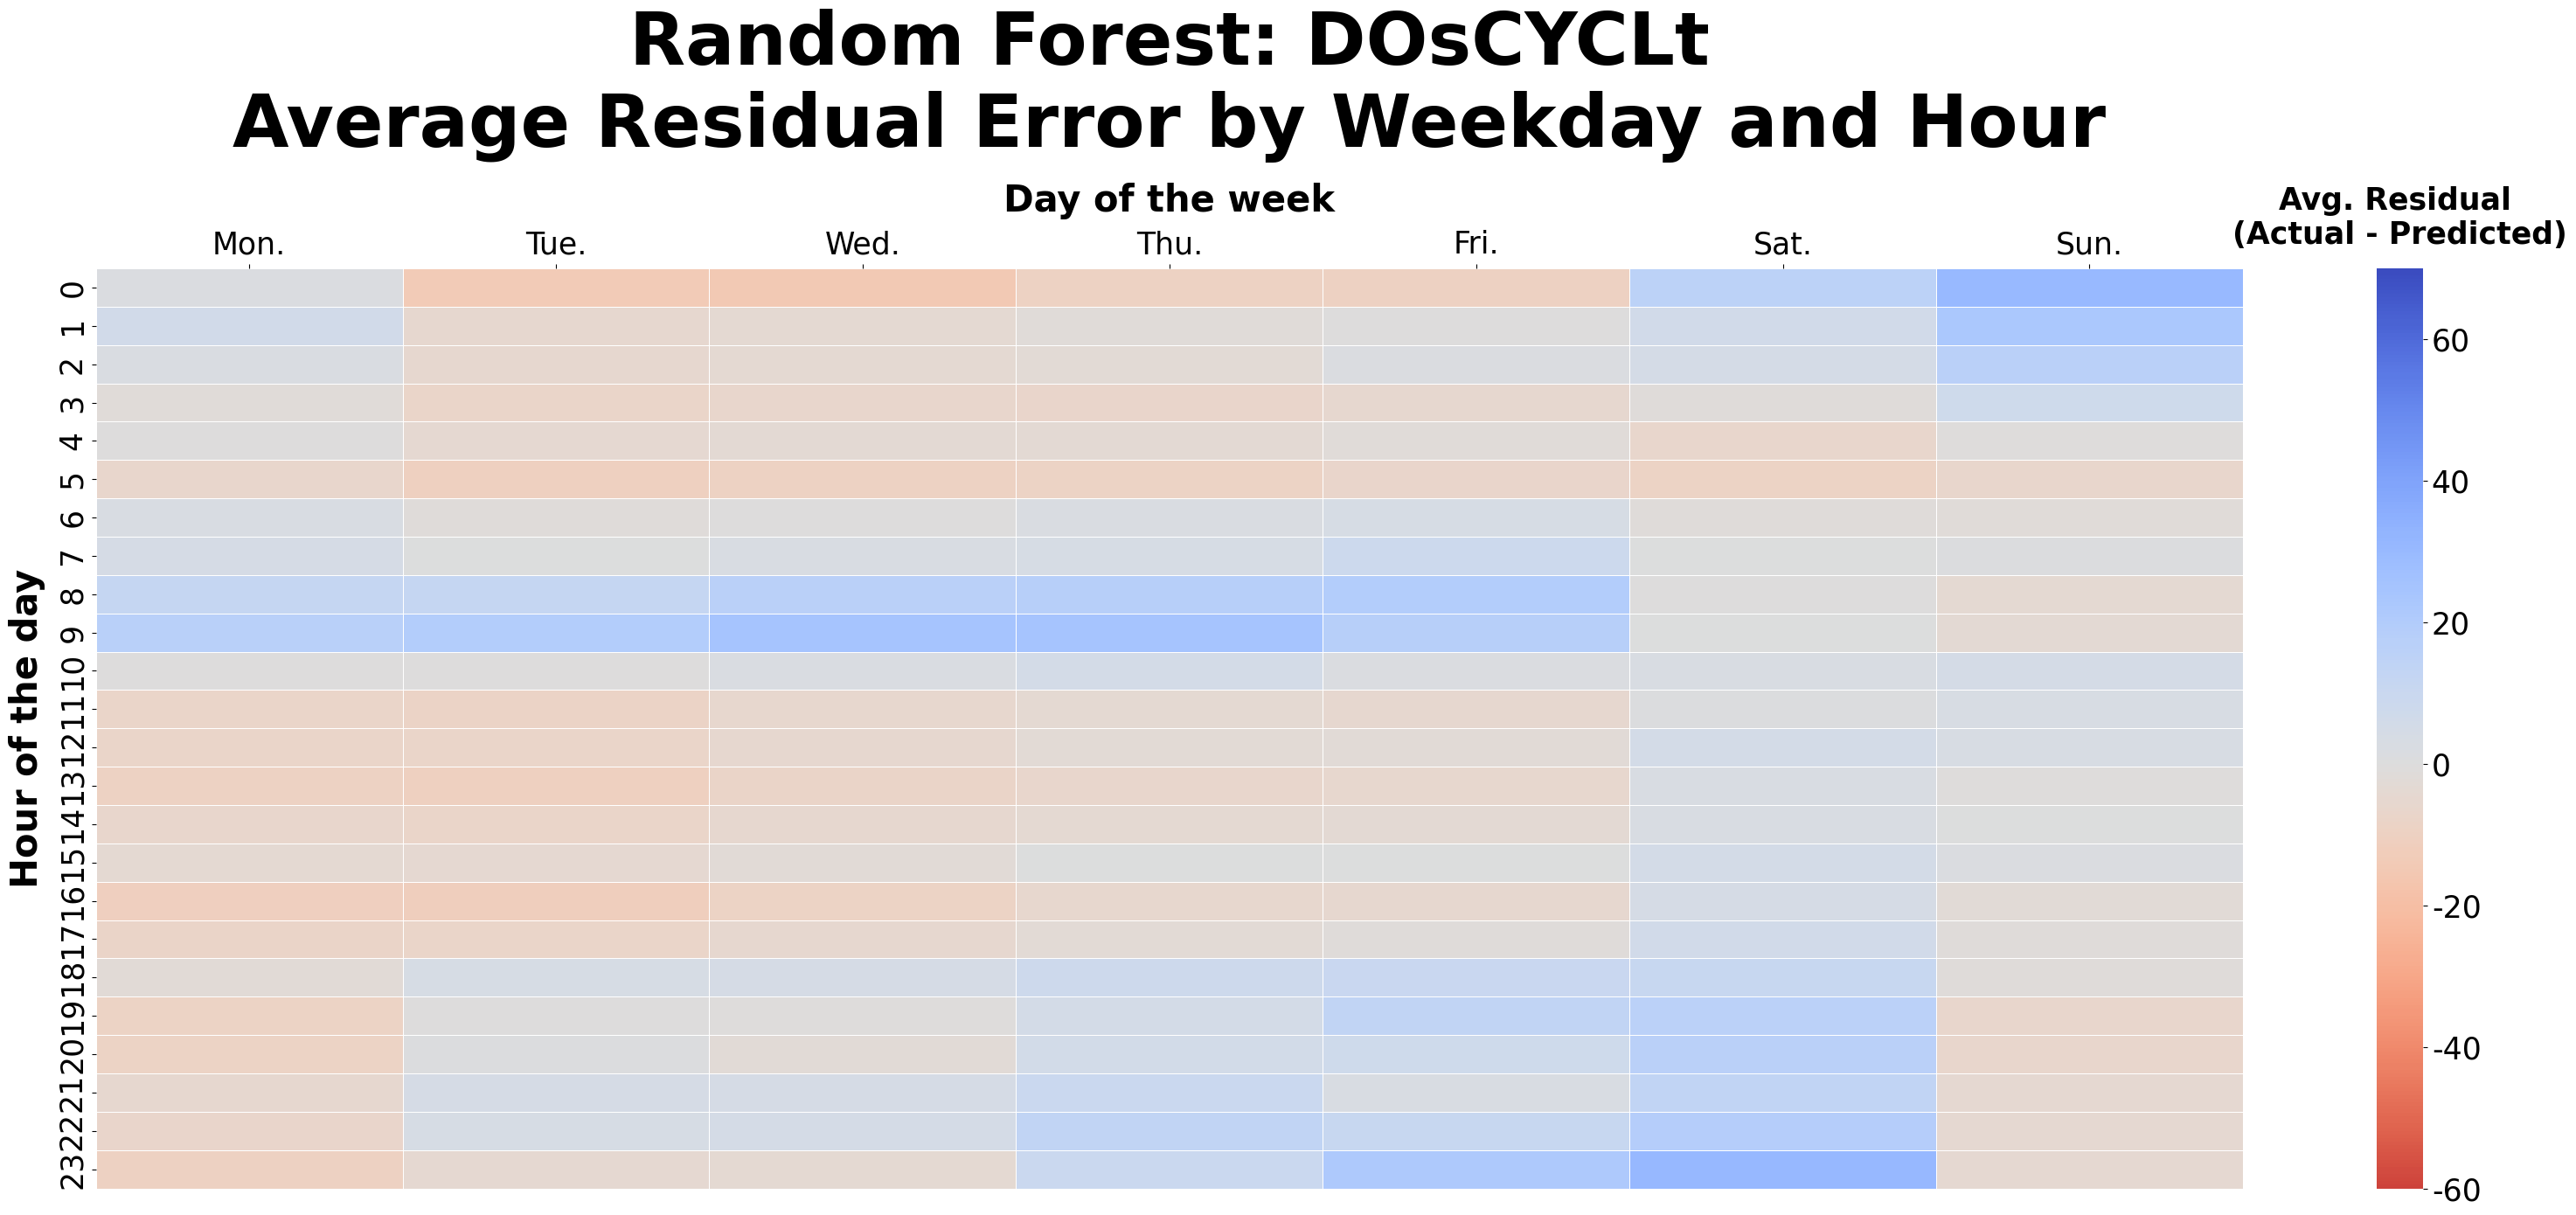

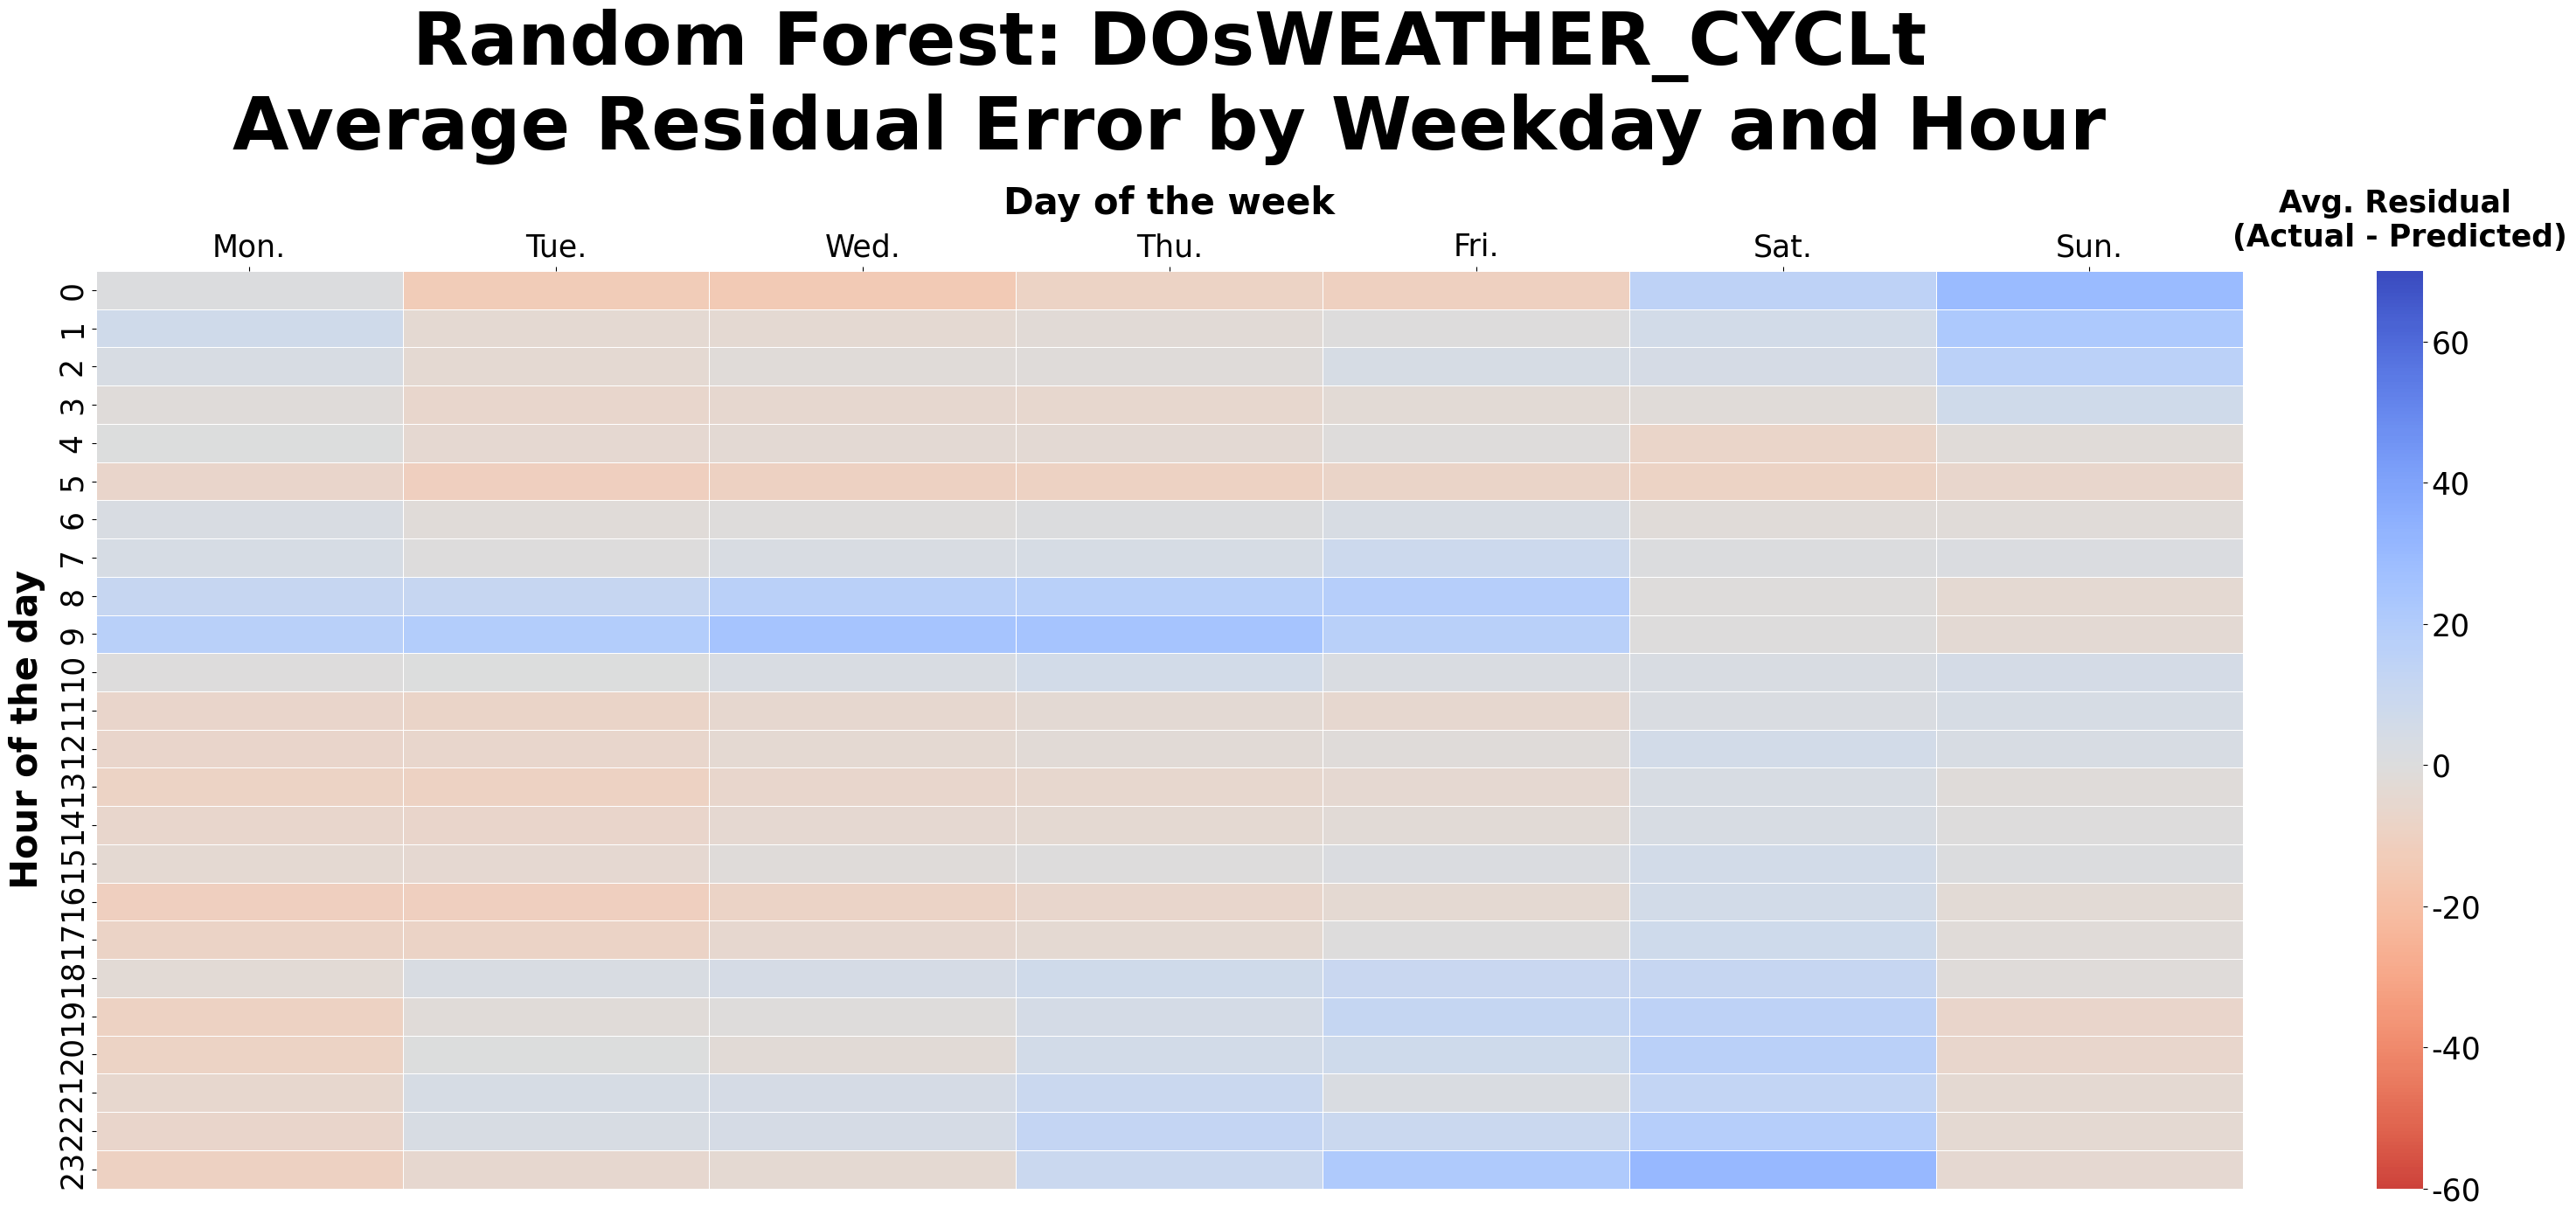

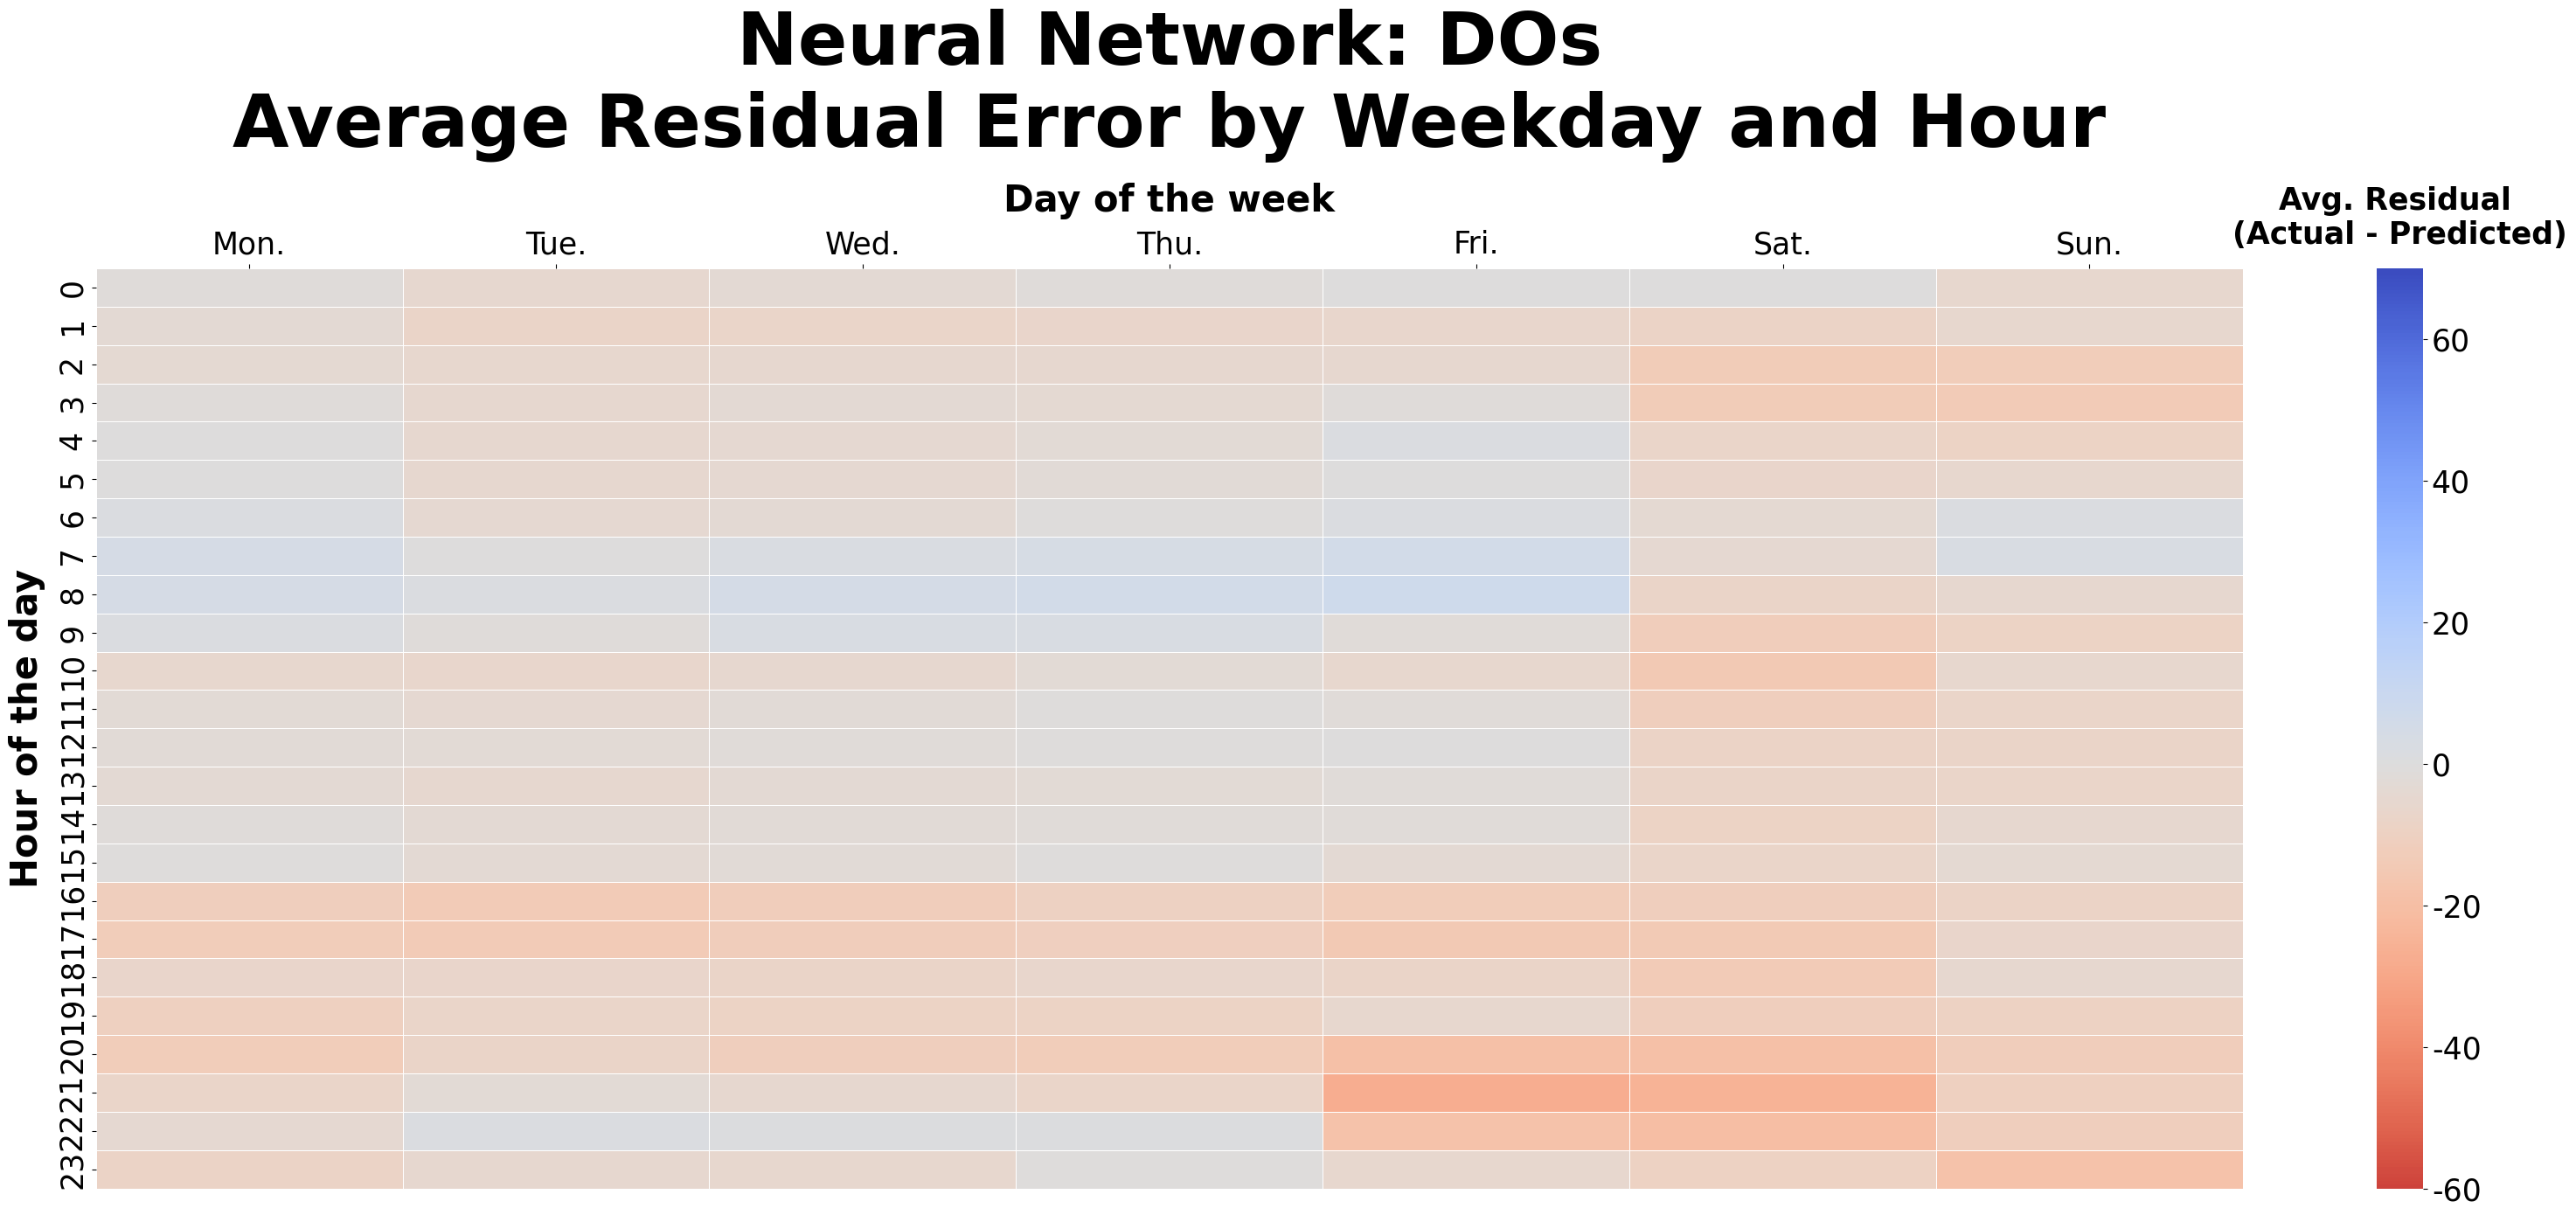

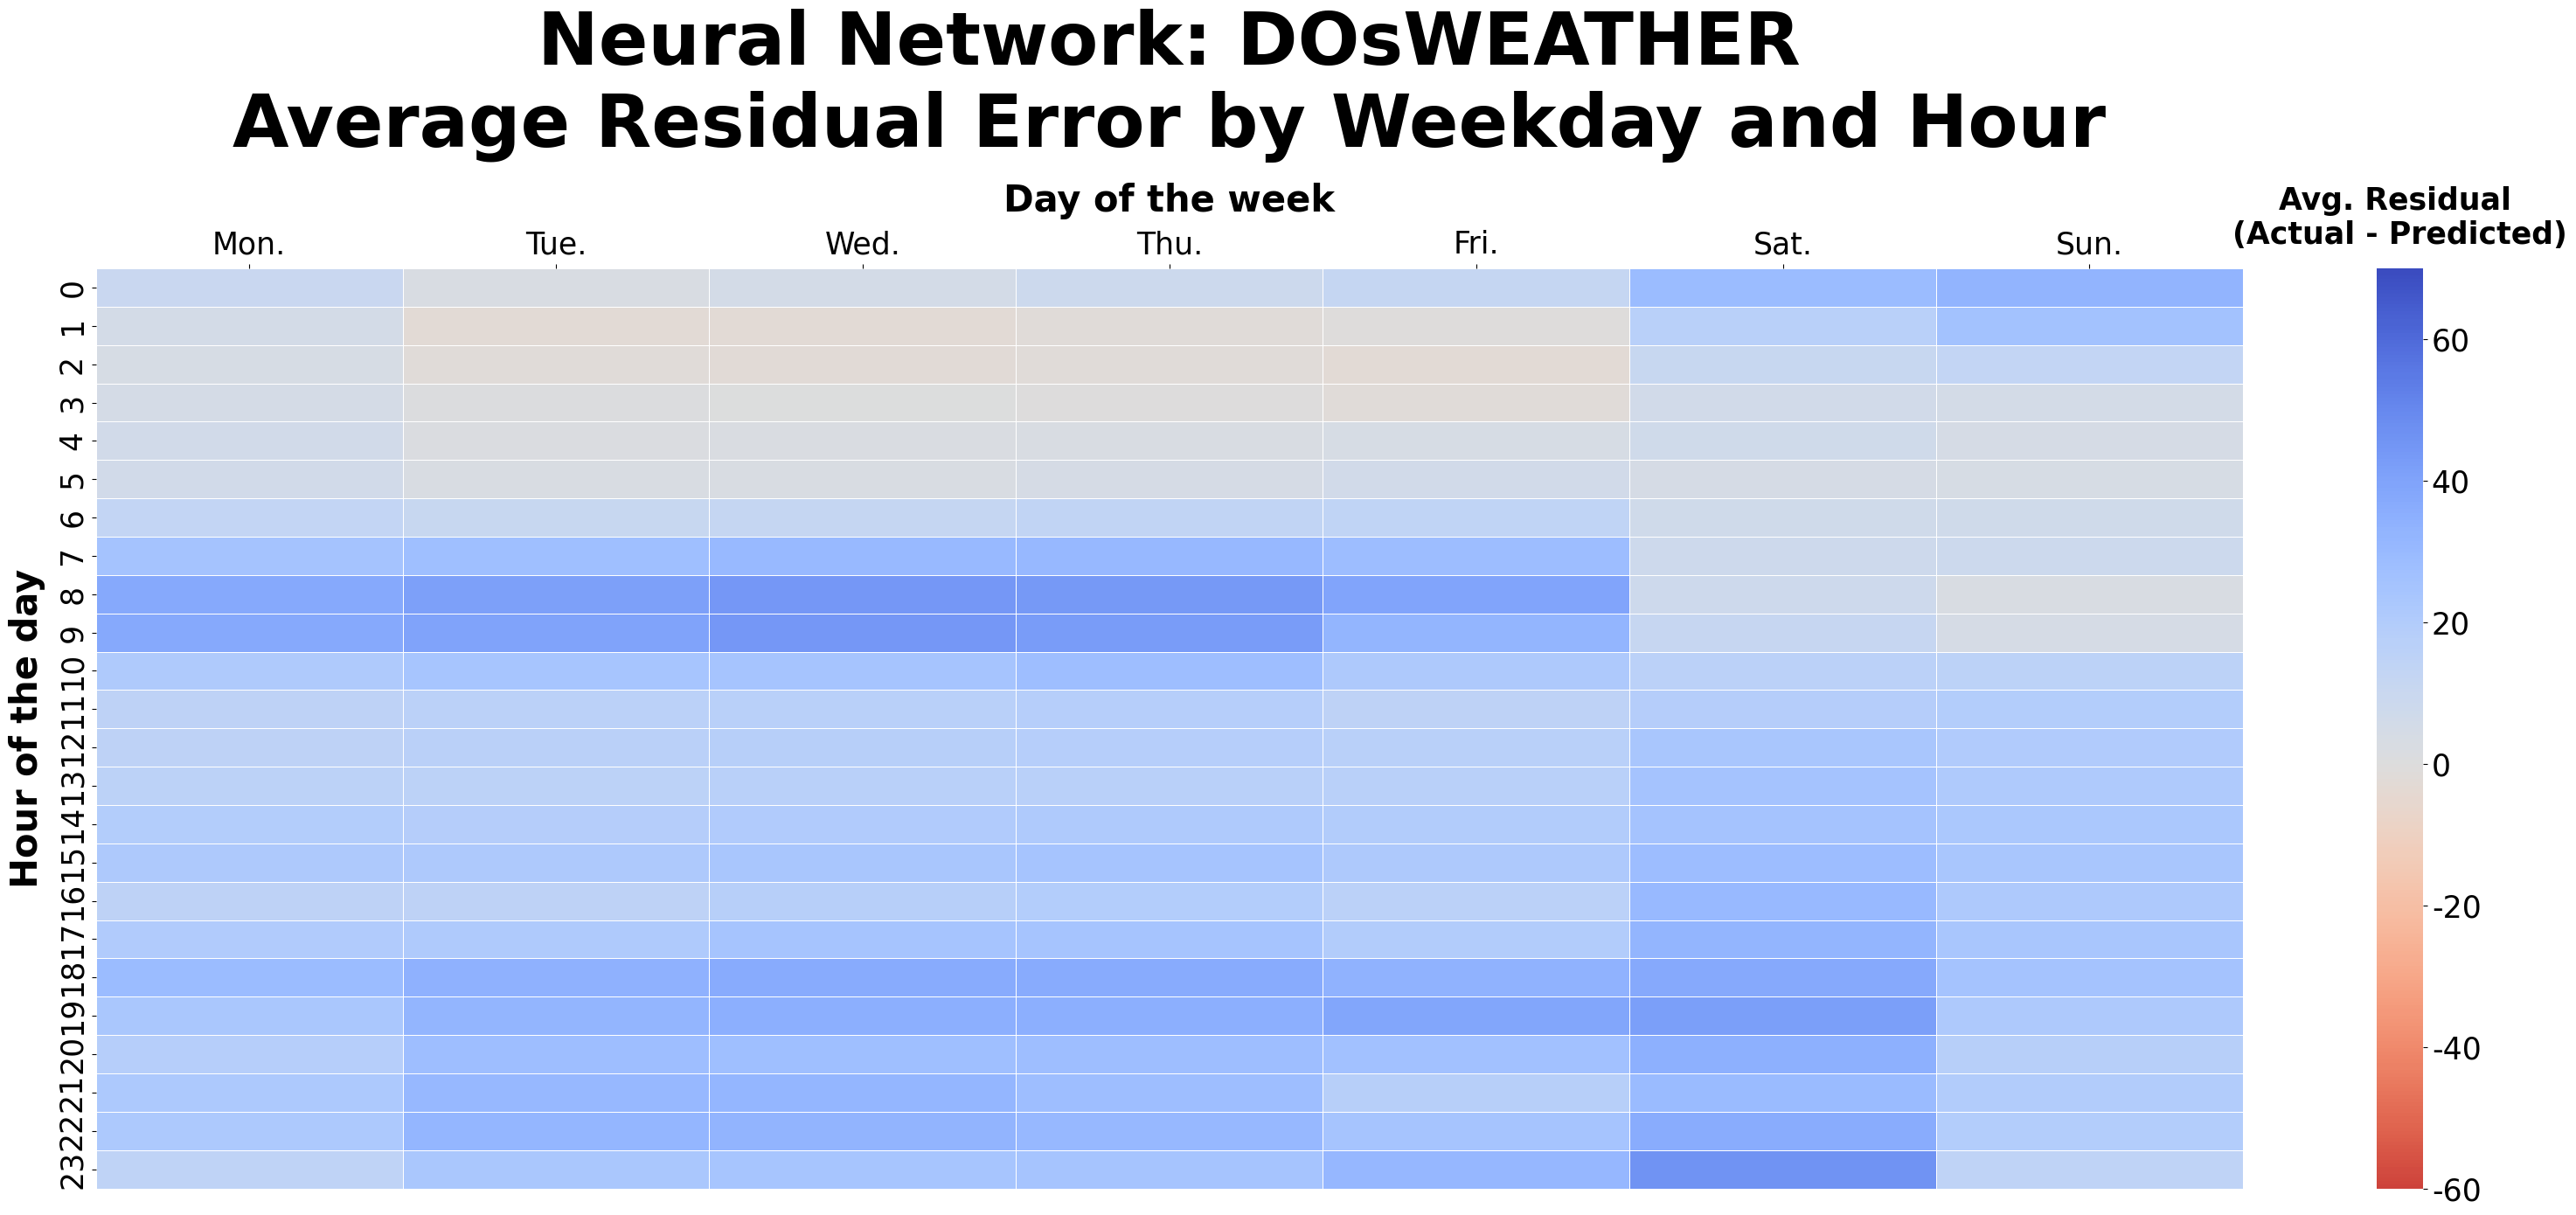

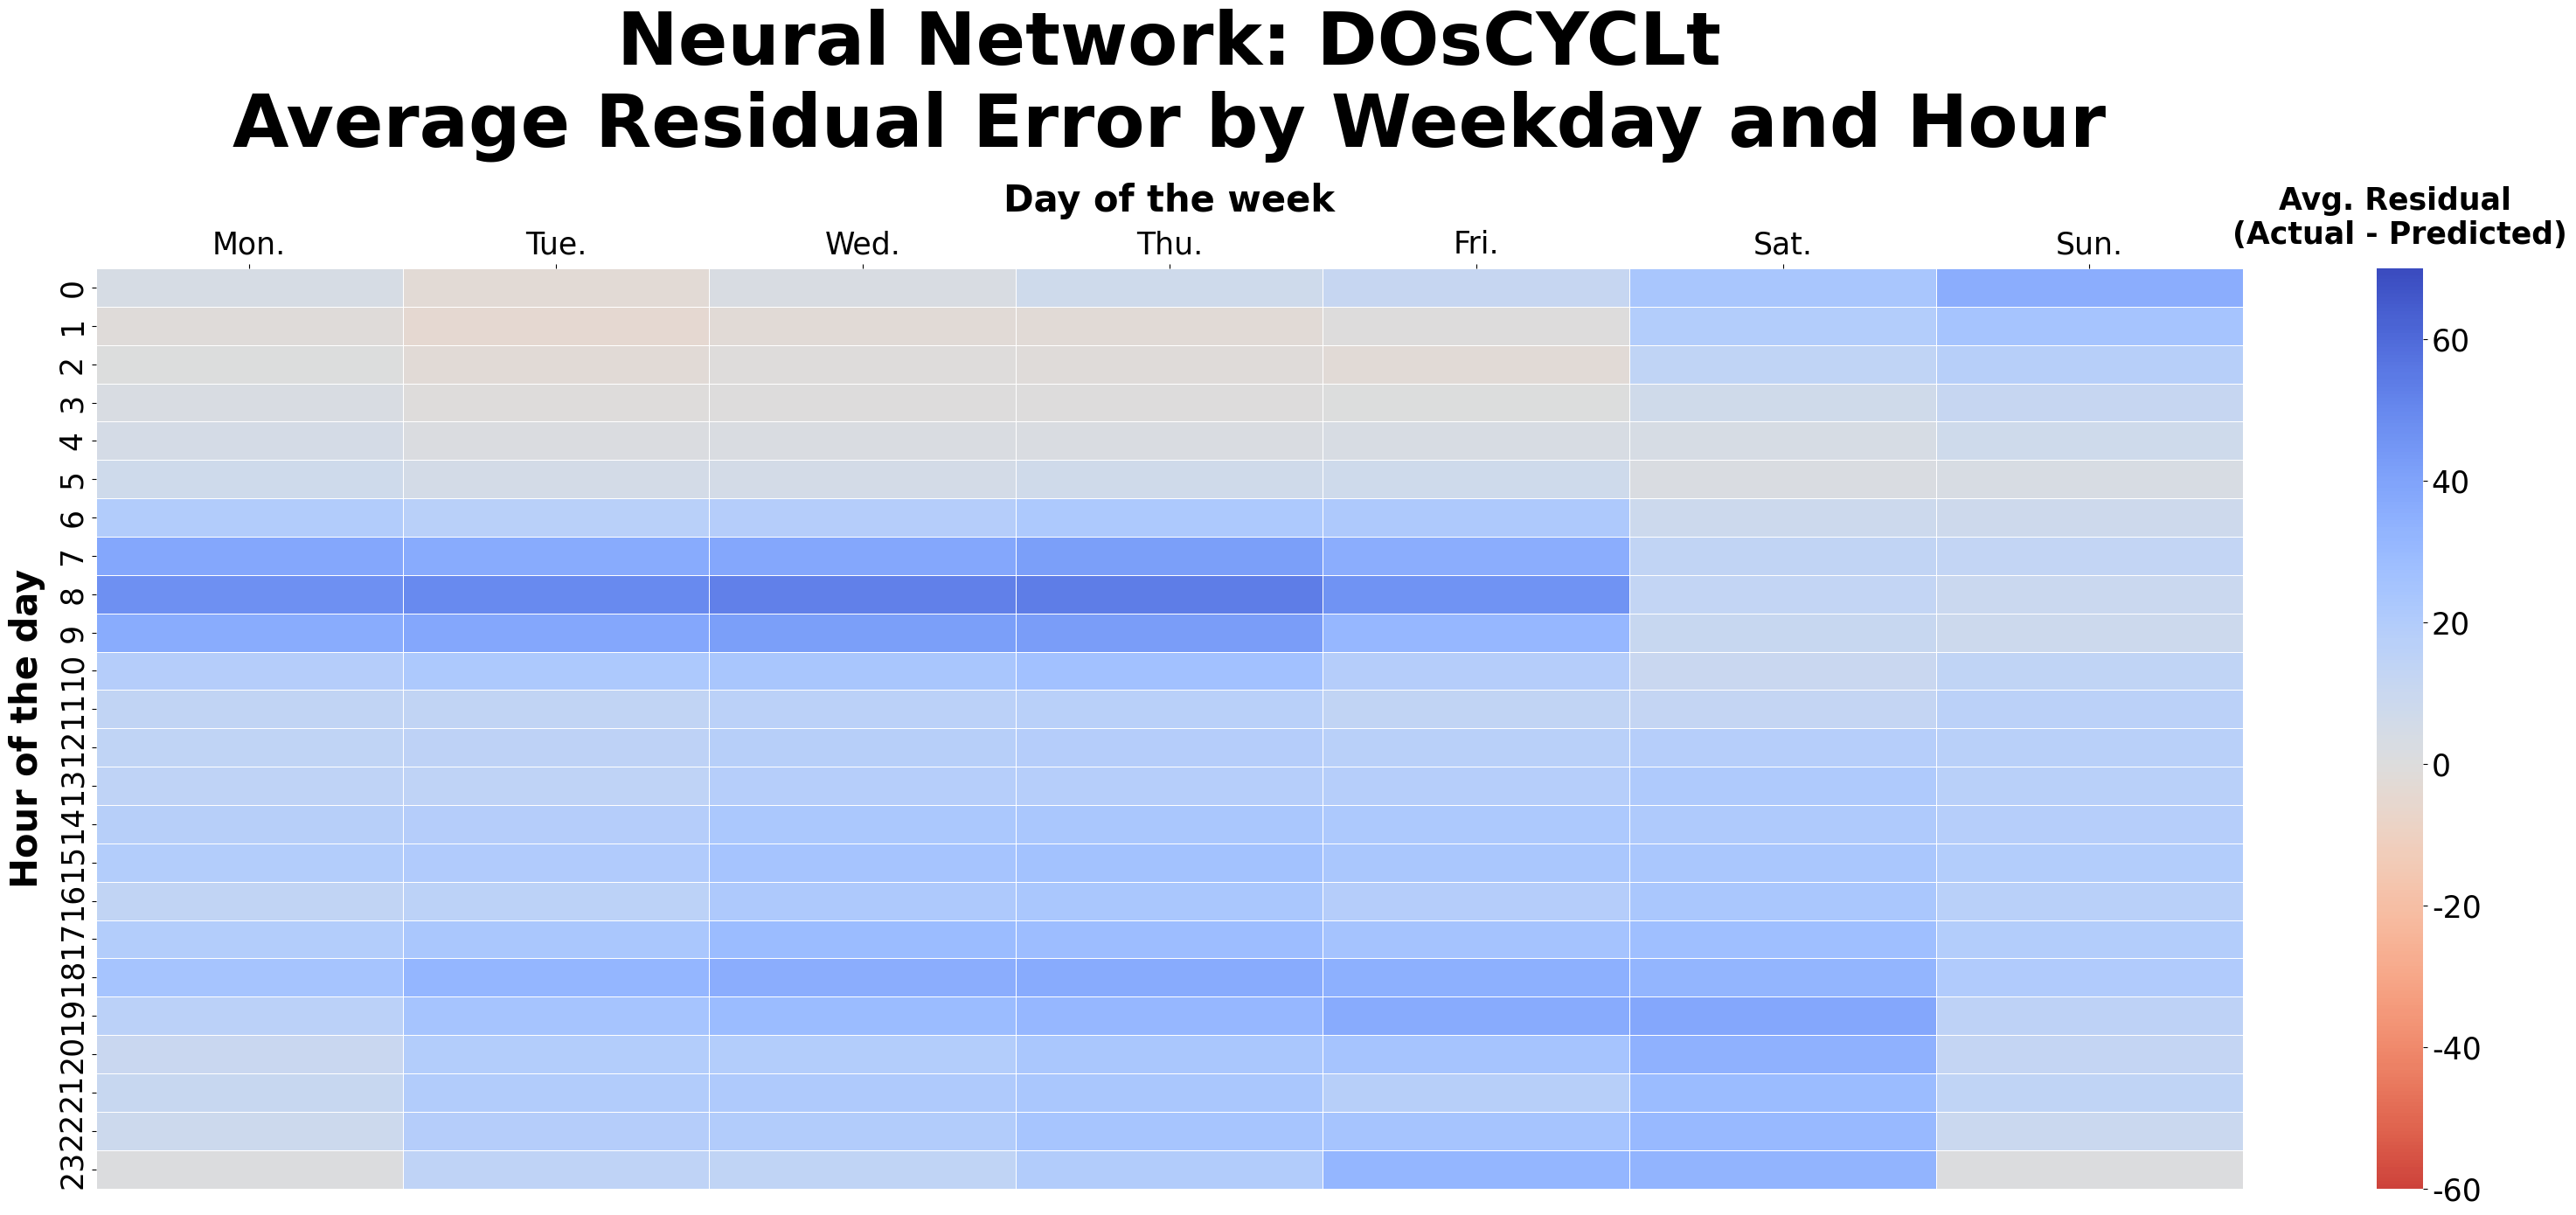

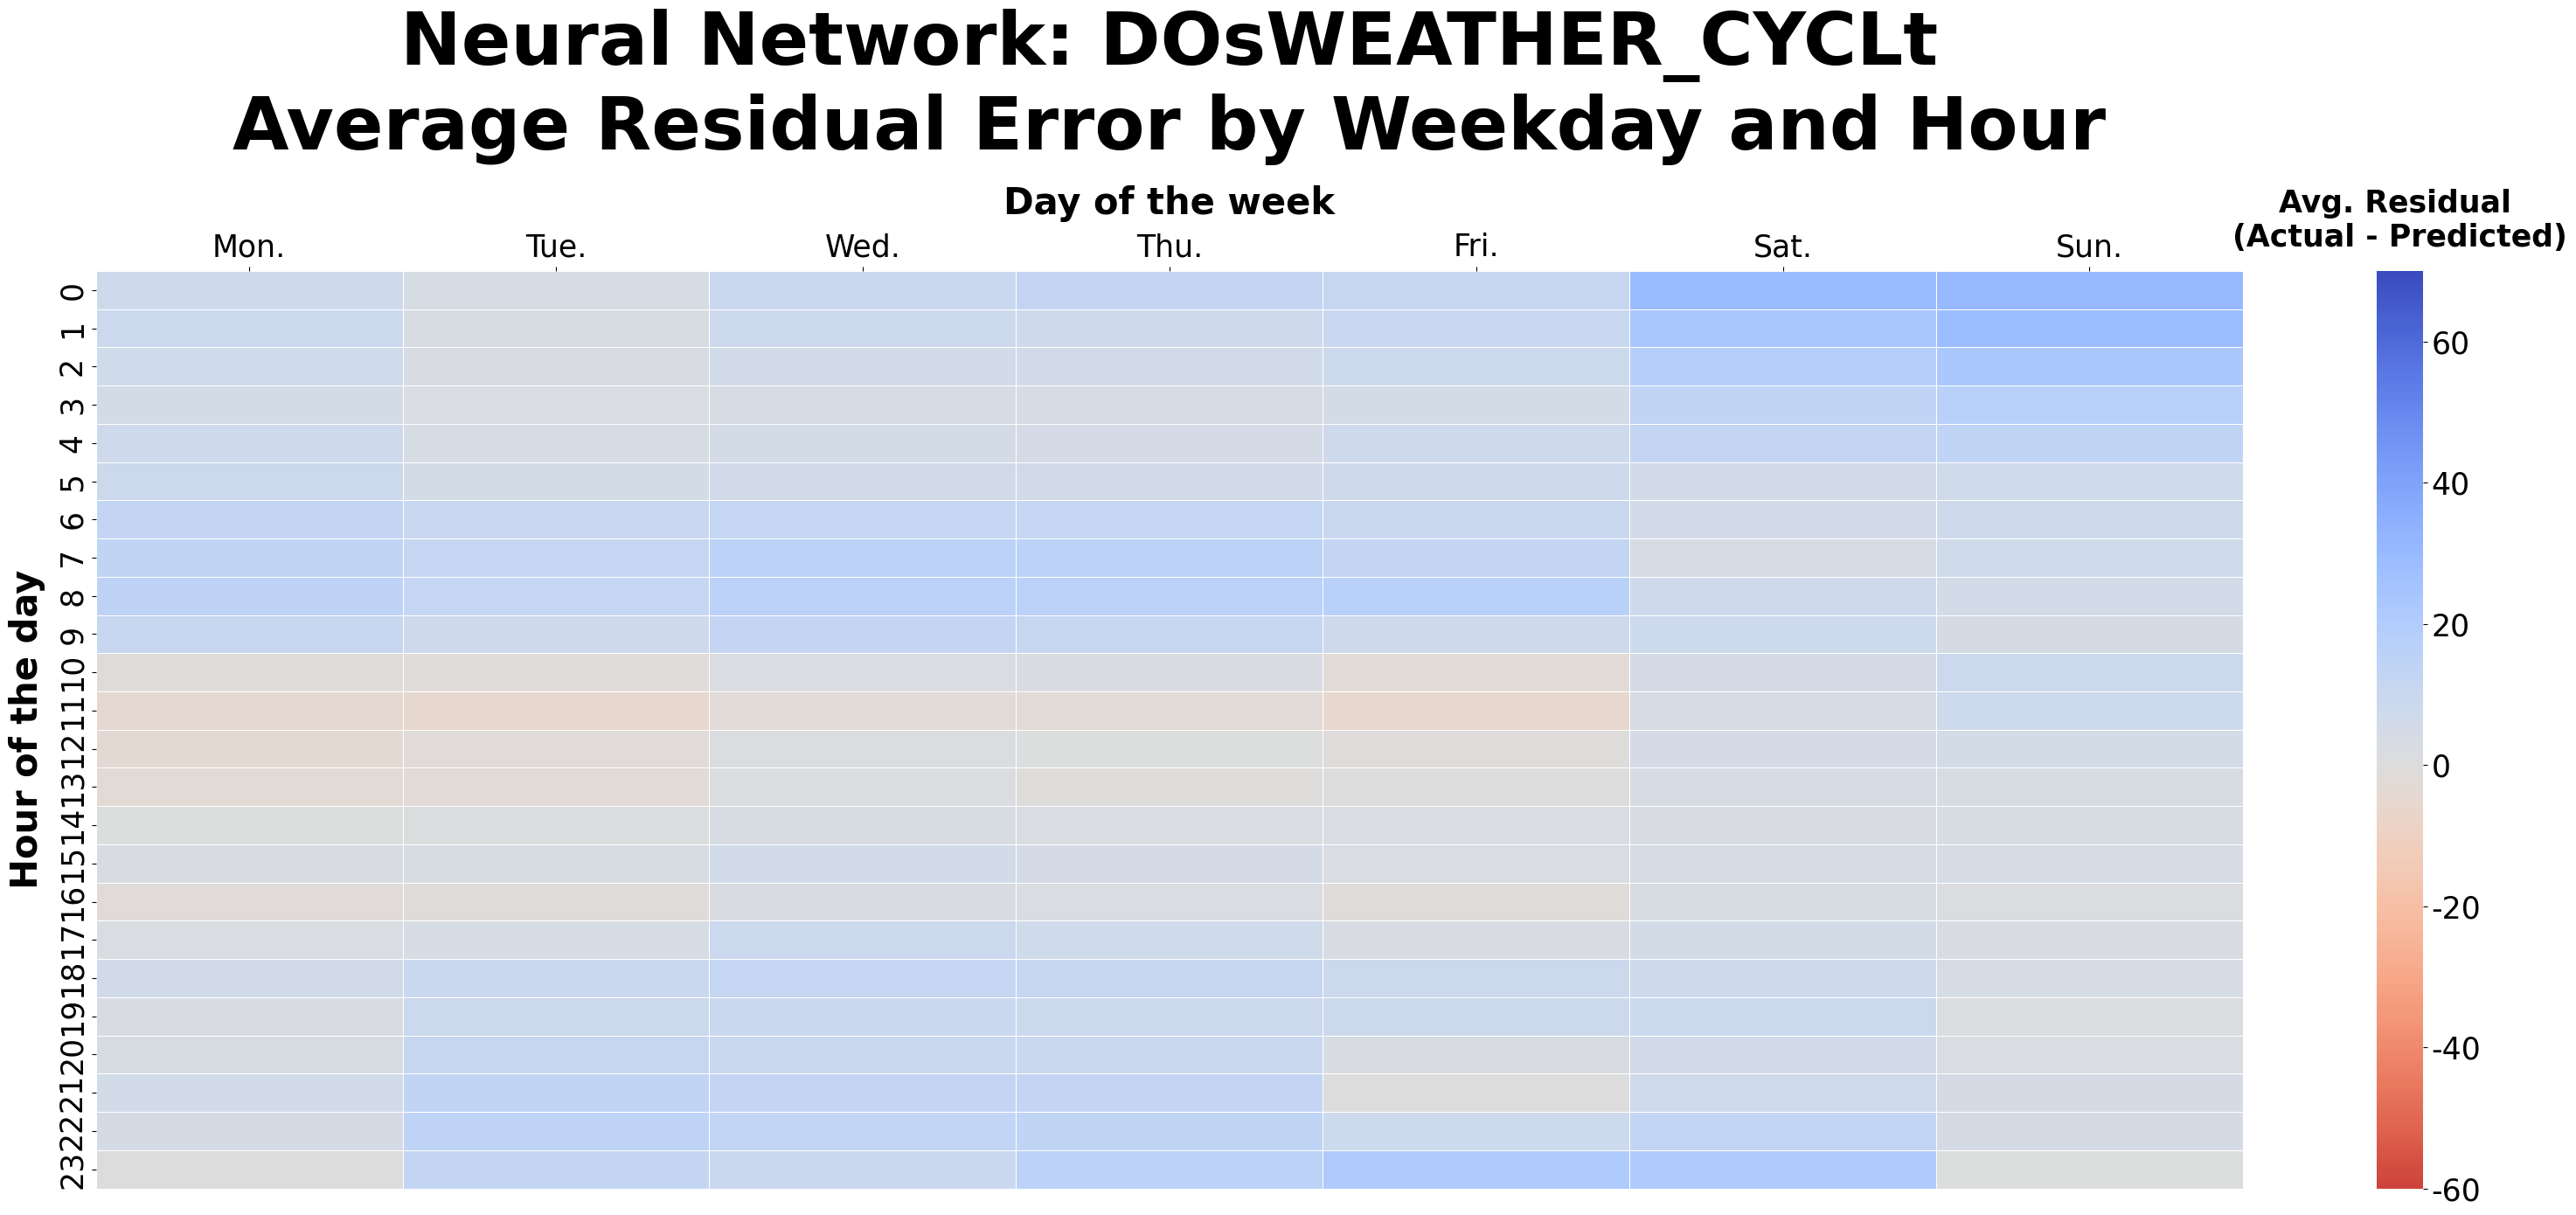

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd

# 1. Define the models and their dataframes
models = {
    'Ridge Regression': DO_Ridge_unscaled,
    'Random Forest': DO_RF_unscaled,
    'Neural Network': DO_NN_unscaled
}

# 2. Define the datasets using your raw column names
datasets = ['DOs', 'DOsWEATHER', 'DOsCYCLt', 'DOsWEATHER_CYCLt']

# Outer Loop: Iterate through each model
for model_name, df_raw in models.items():

    # Create a copy and extract time features once per model
    df = df_raw.copy()
    df['hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek

    # Inner Loop: Iterate through each raw dataset name
    for dataset_name in datasets:

        # Calculate the residual (Actual - Predicted) for this specific dataset
        df['Residual'] = df['Actual'] - df[dataset_name]

        # Create the Pivot Table
        heatmap_data = pd.pivot_table(
            df,
            values="Residual",
            index="hour",
            columns="DayOfWeek",
            aggfunc="mean"
        )

        # --- PLOTTING ---
        plt.figure(figsize=(32,14))

        # Using coolwarm centered at 0
        ax = sns.heatmap(
            data=heatmap_data,
            cmap="coolwarm_r",
            center=0,
            vmin=-60,
            vmax=70,
            linewidth=0.5,
            annot=False
        )

        # Titles and Labels using the raw dataset name
        plt.title(f"{model_name}: {dataset_name}\nAverage Residual Error by Weekday and Hour",
                  fontsize=60, fontweight="bold", pad=30)

        ax.set_xlabel("Day of the week", fontweight="bold", labelpad=15, fontsize=30)
        ax.set_xticklabels(["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."], fontsize=25)

        ax.set_ylabel("Hour of the day", fontweight="bold", labelpad=10, fontsize=30)
        ax.tick_params(axis="y", labelsize=25)

        # Move X-axis labels to the top
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position("top")

        # Format the colorbar
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))   # (AI generated)
        cbar.ax.set_title("Avg. Residual \n(Actual - Predicted)", pad=20, fontsize=25, fontweight="bold")
        cbar.ax.tick_params(labelsize=25)

        plt.tight_layout()

        #plt.savefig(f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/ResidualsHeatmaps/ResidualsHeatmap_{model_name}_{dataset_name}.pdf", dpi=300)

        plt.show()
        plt.close()

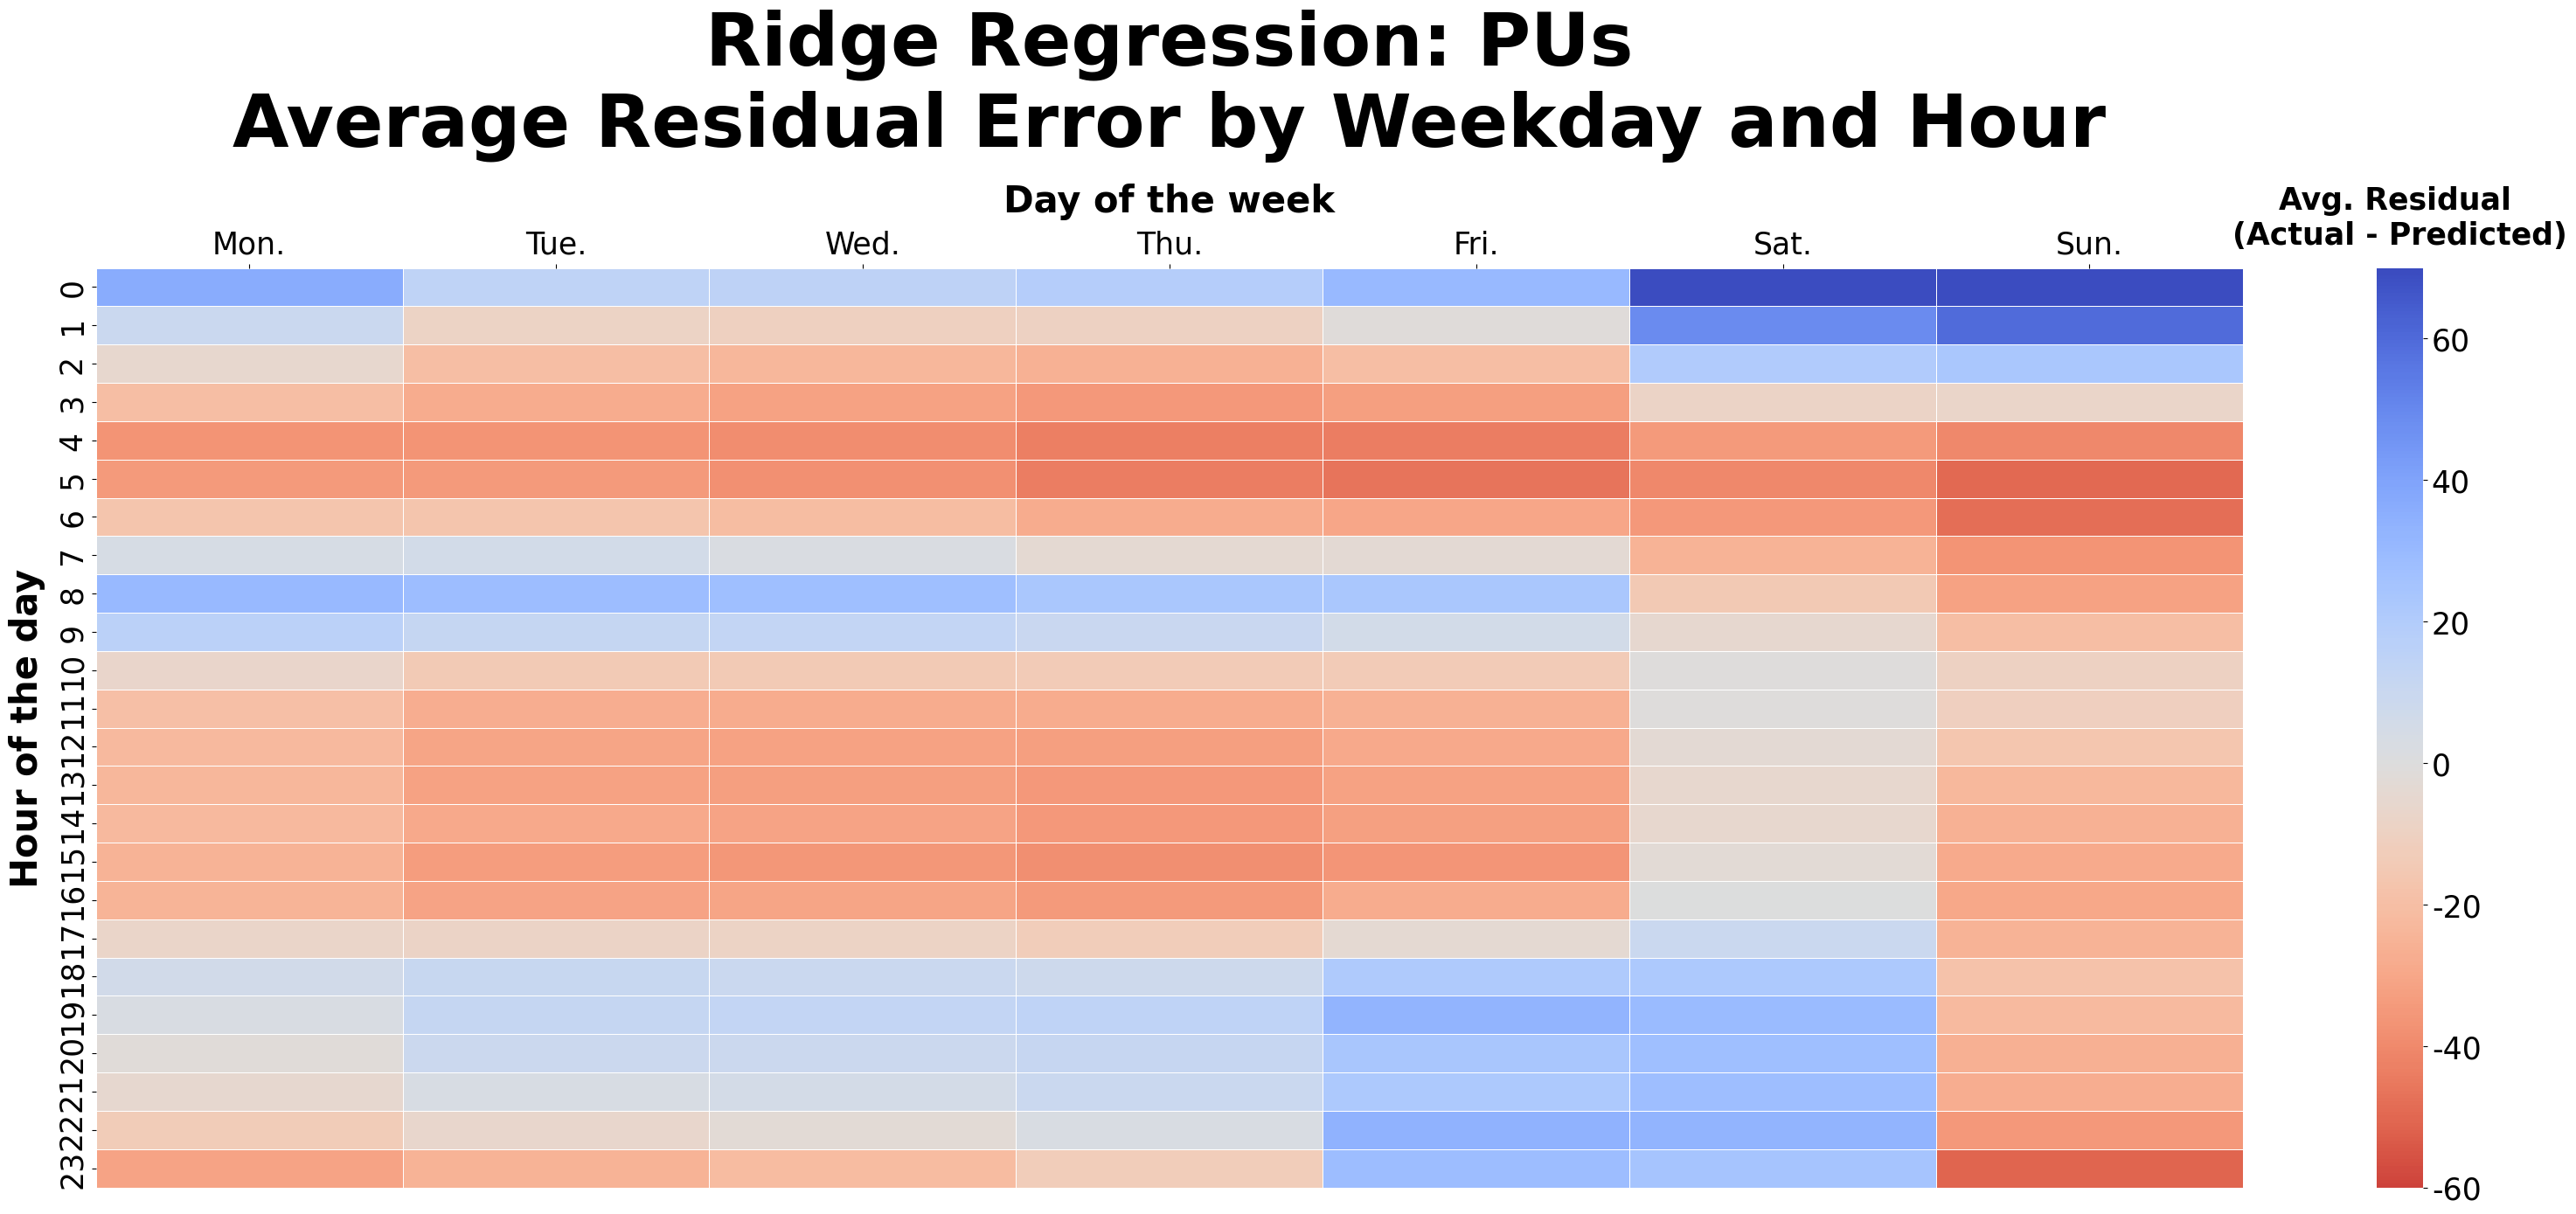

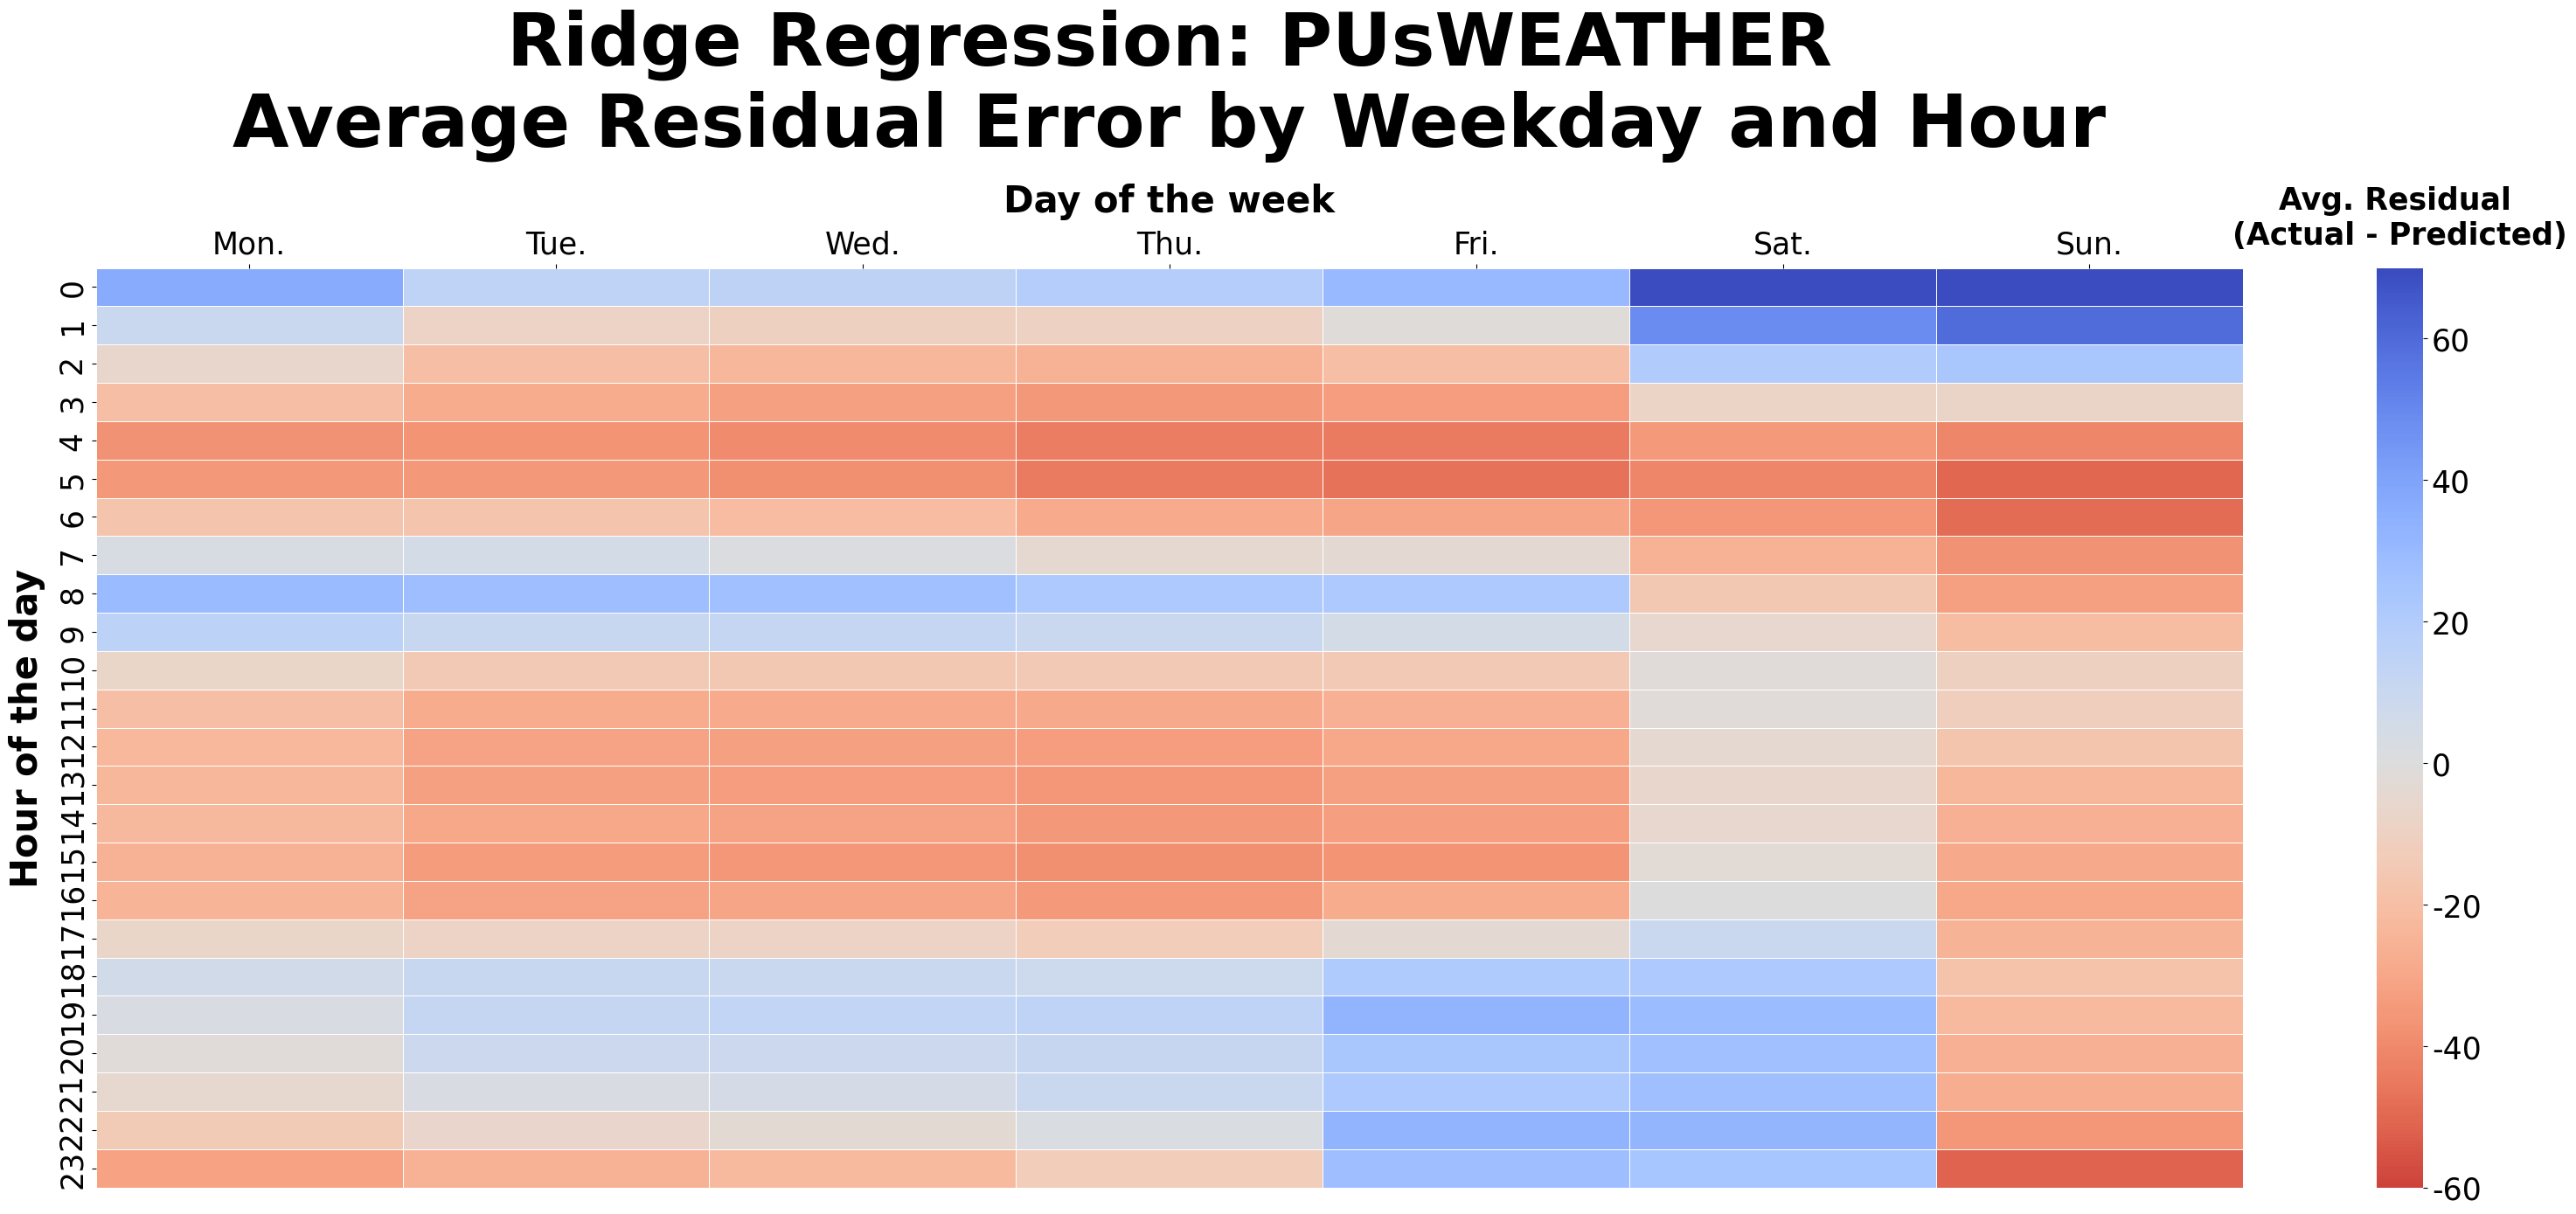

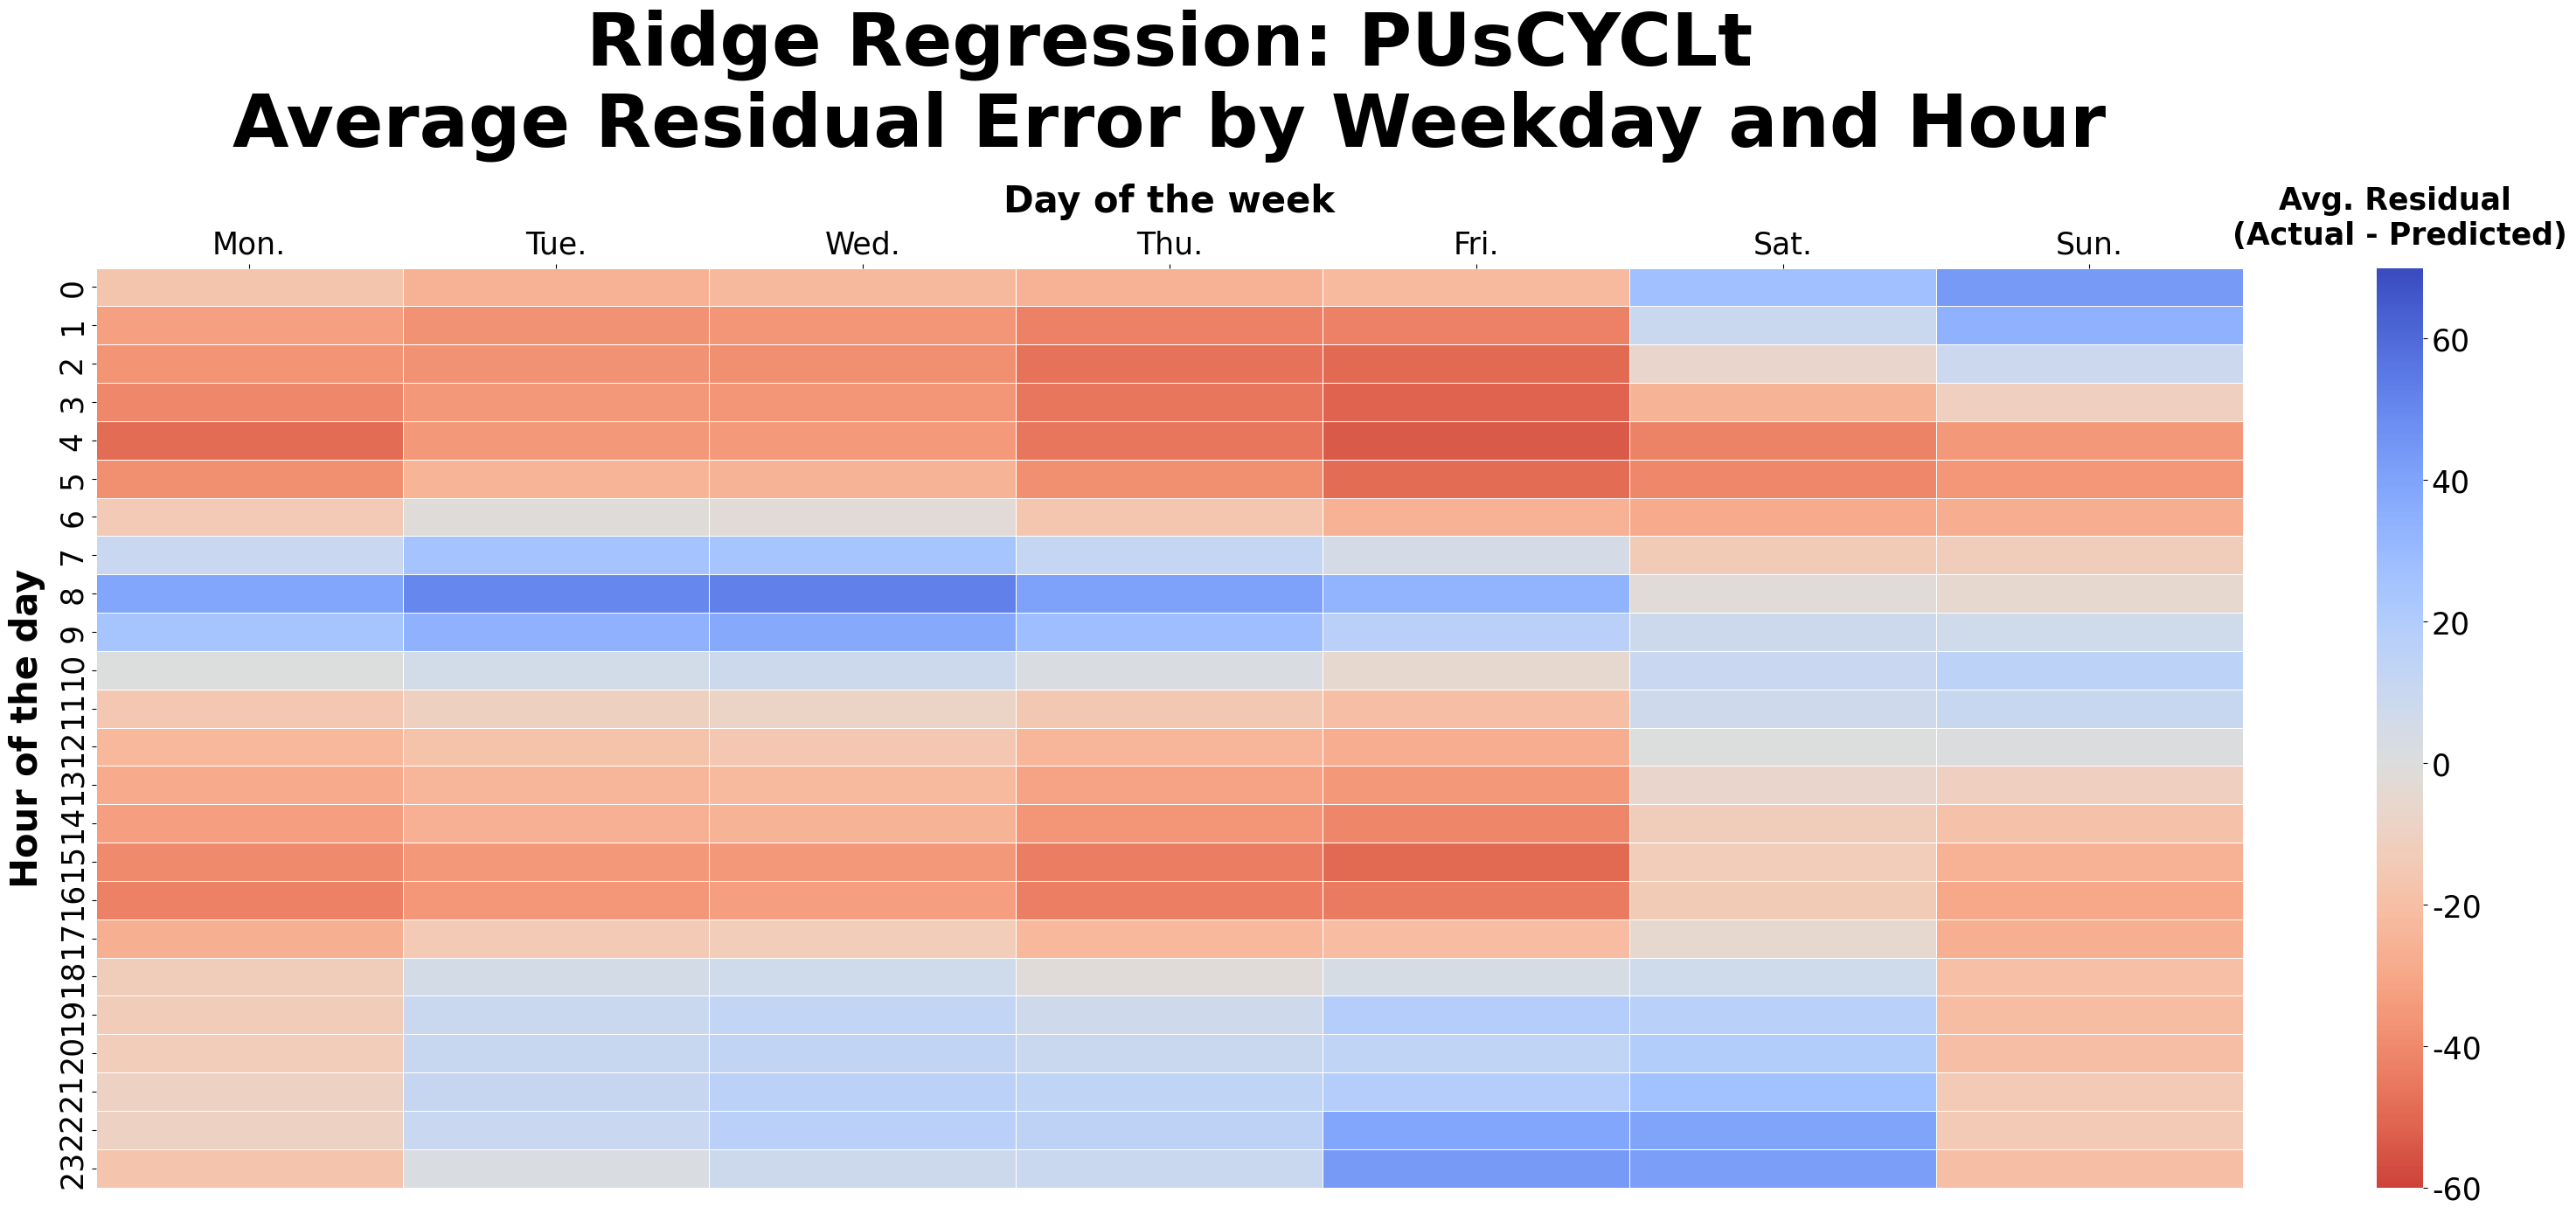

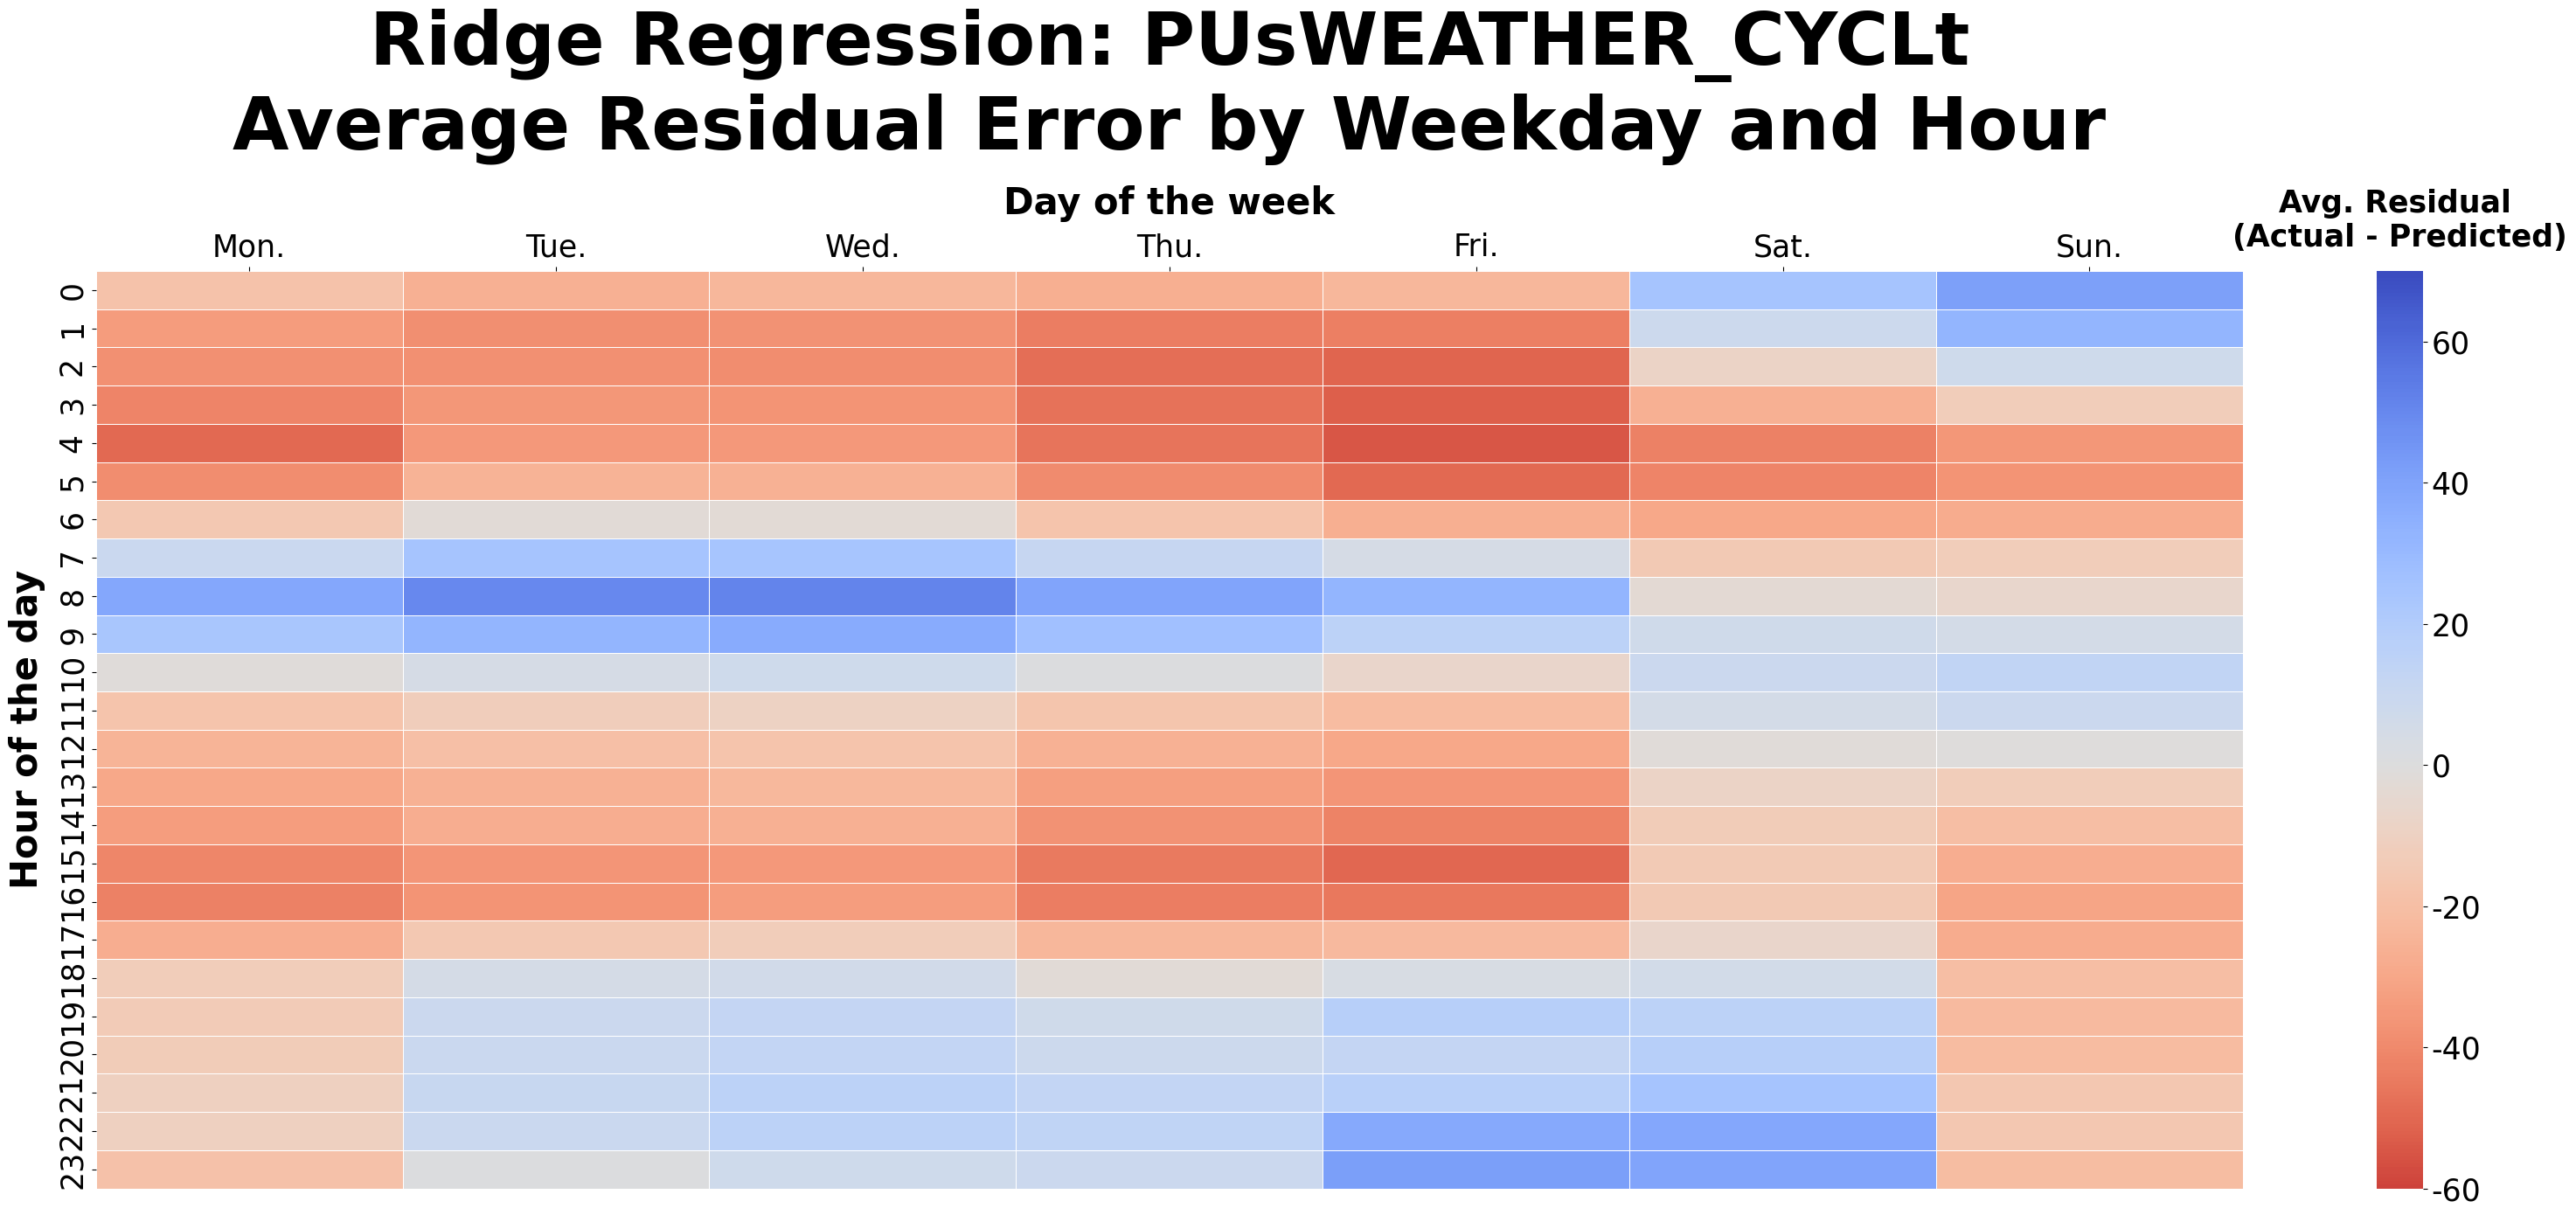

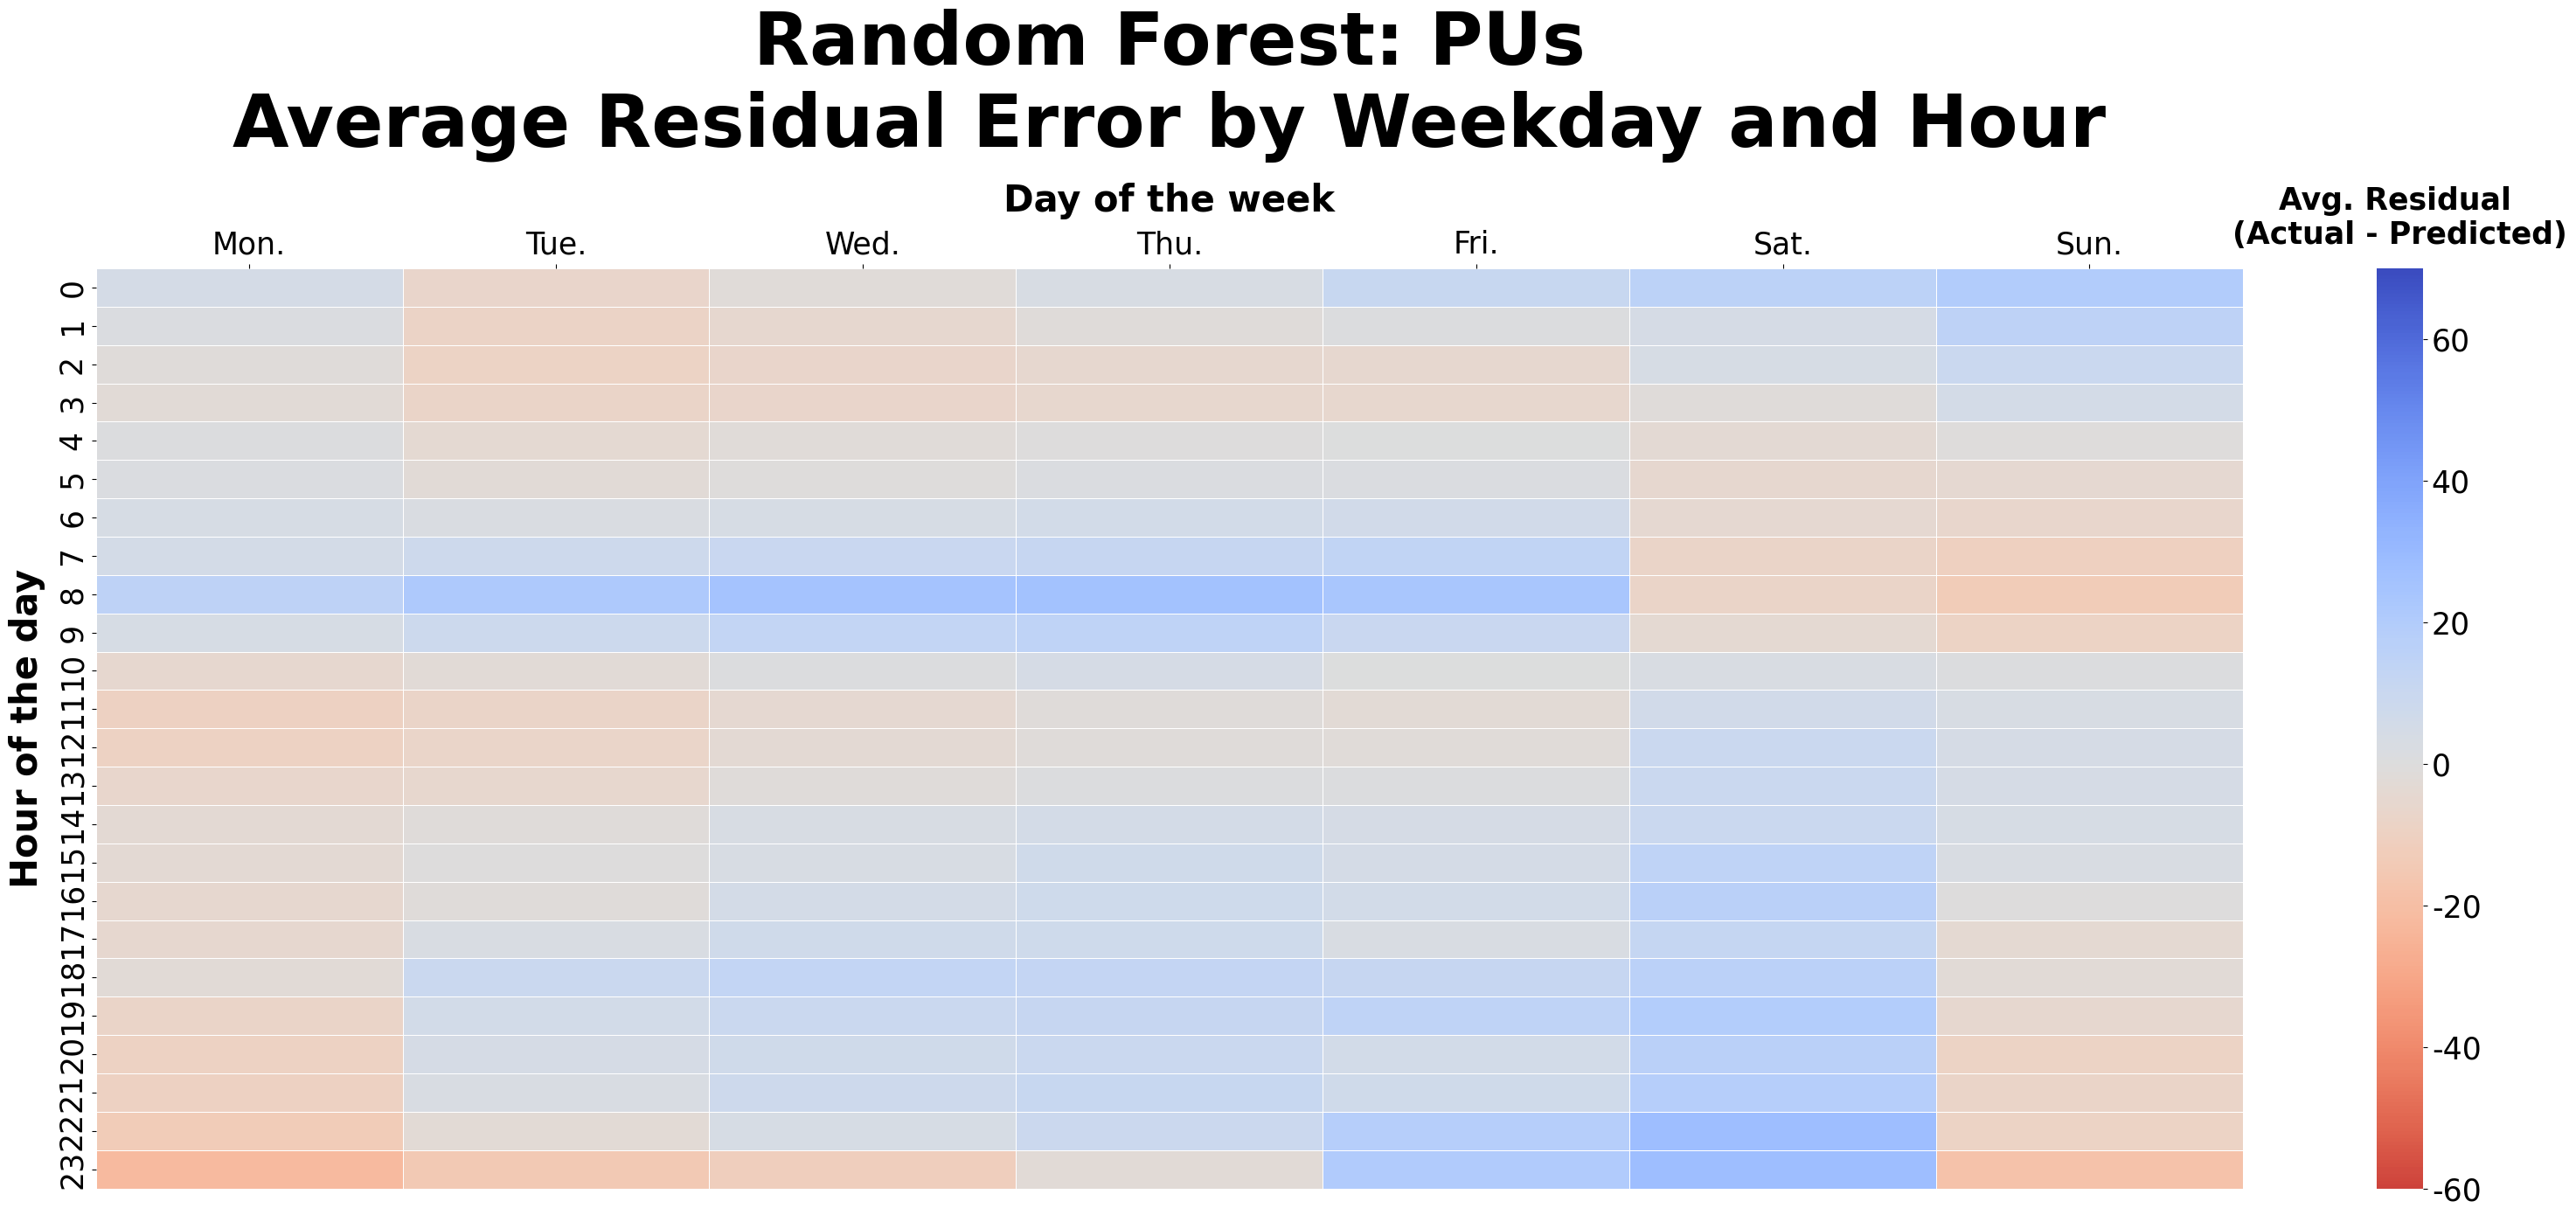

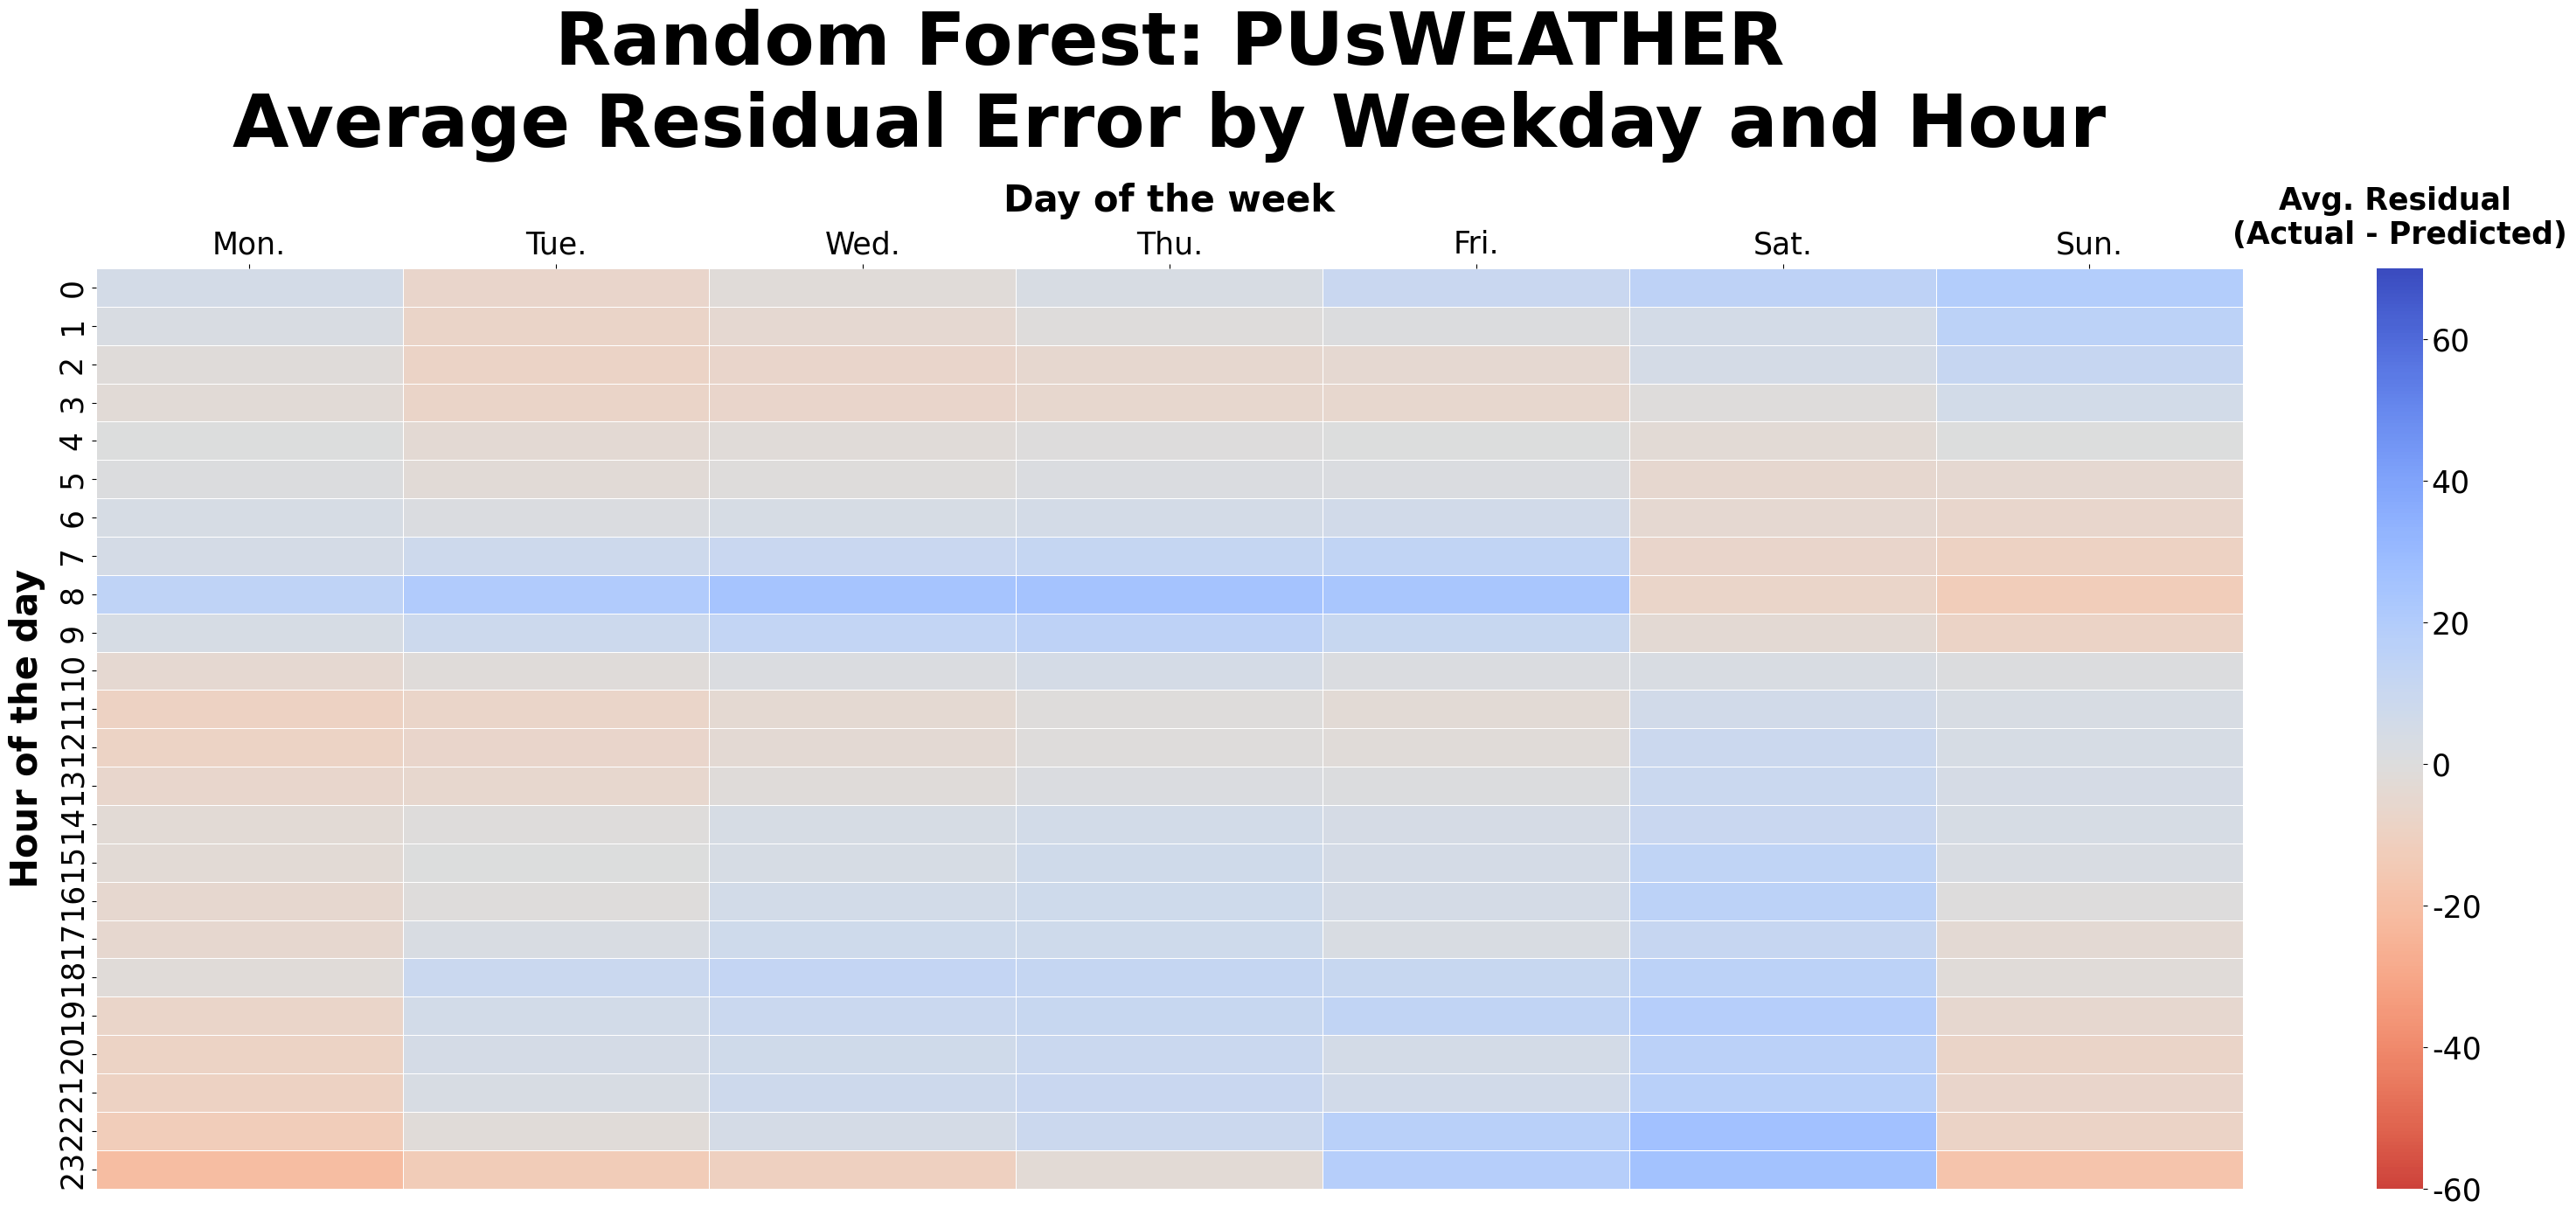

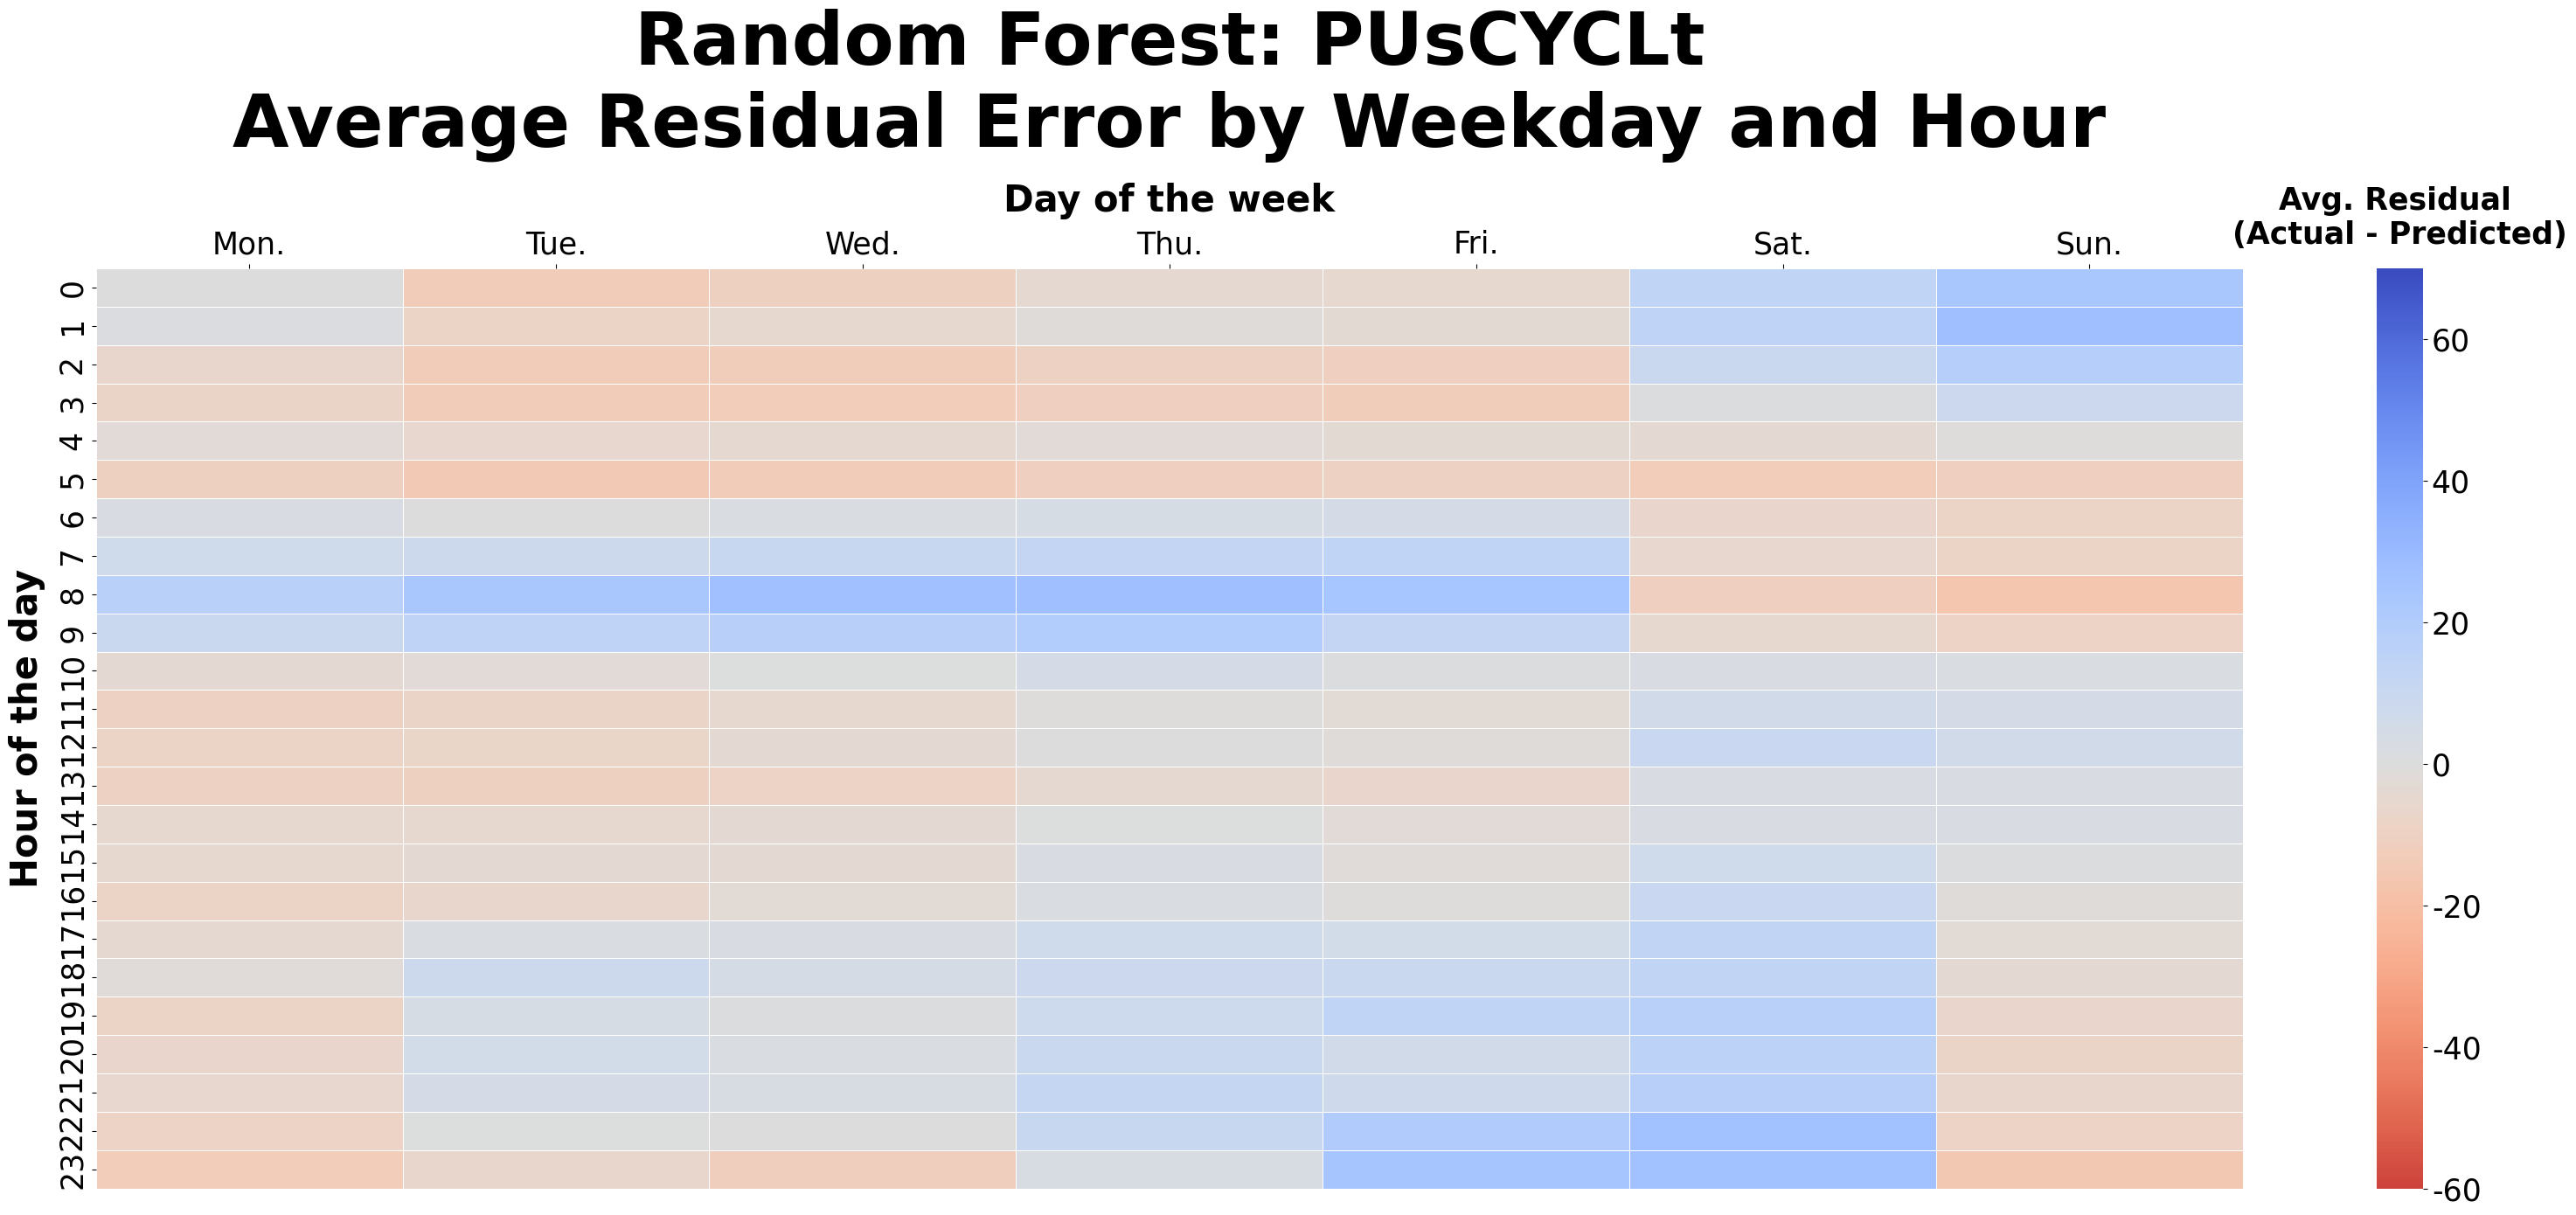

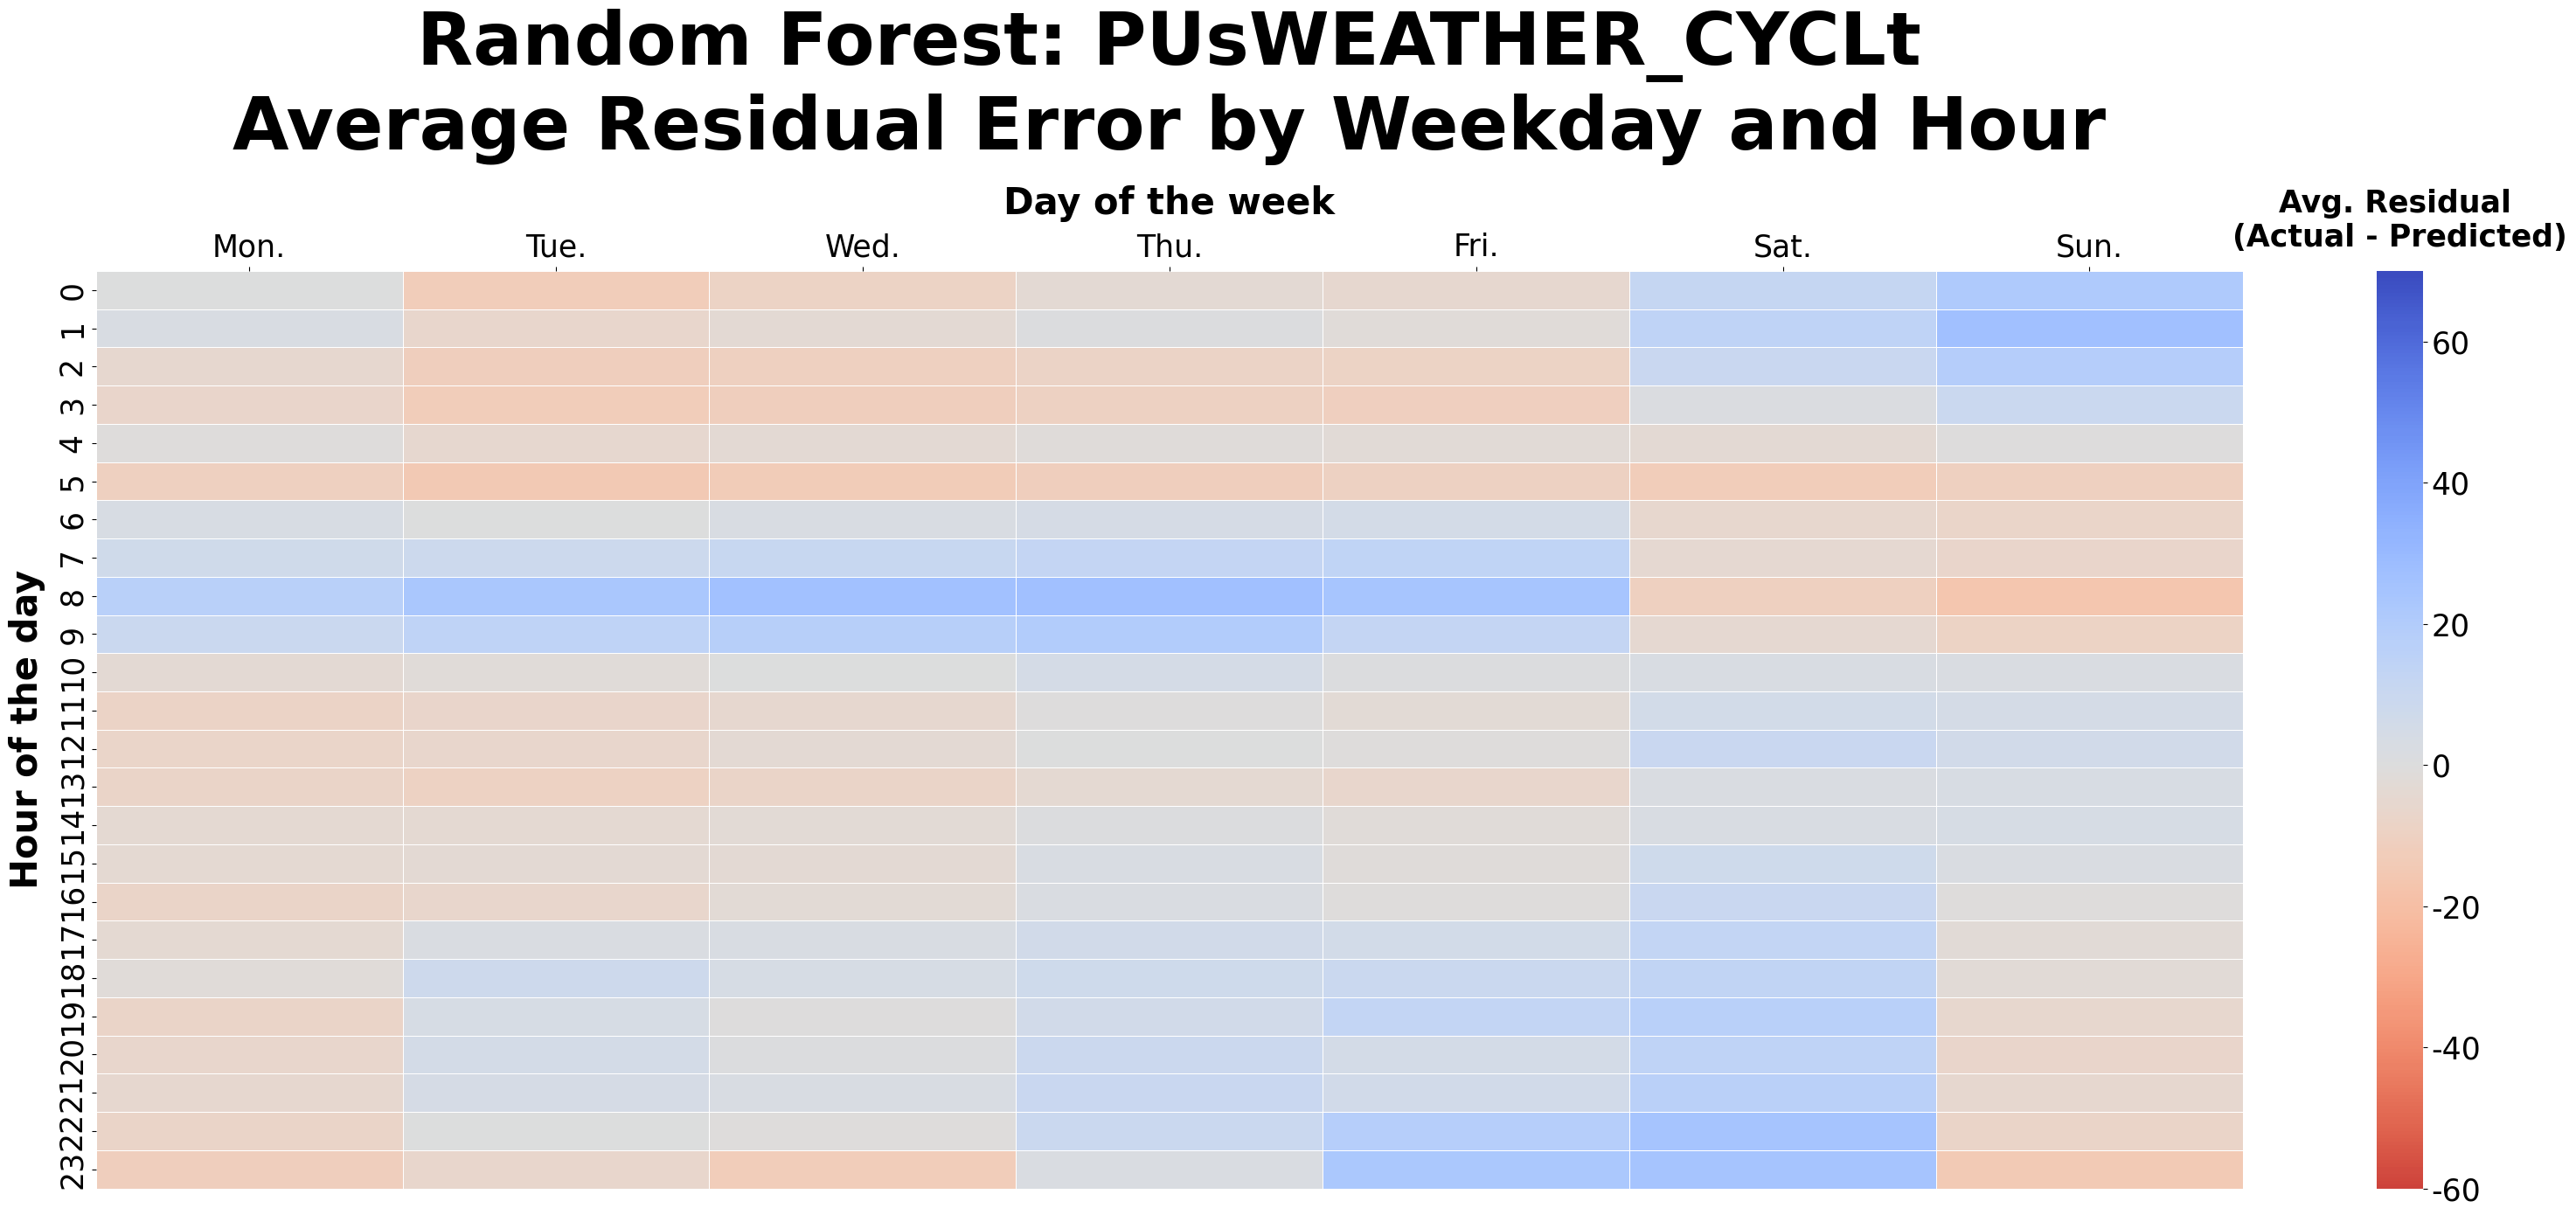

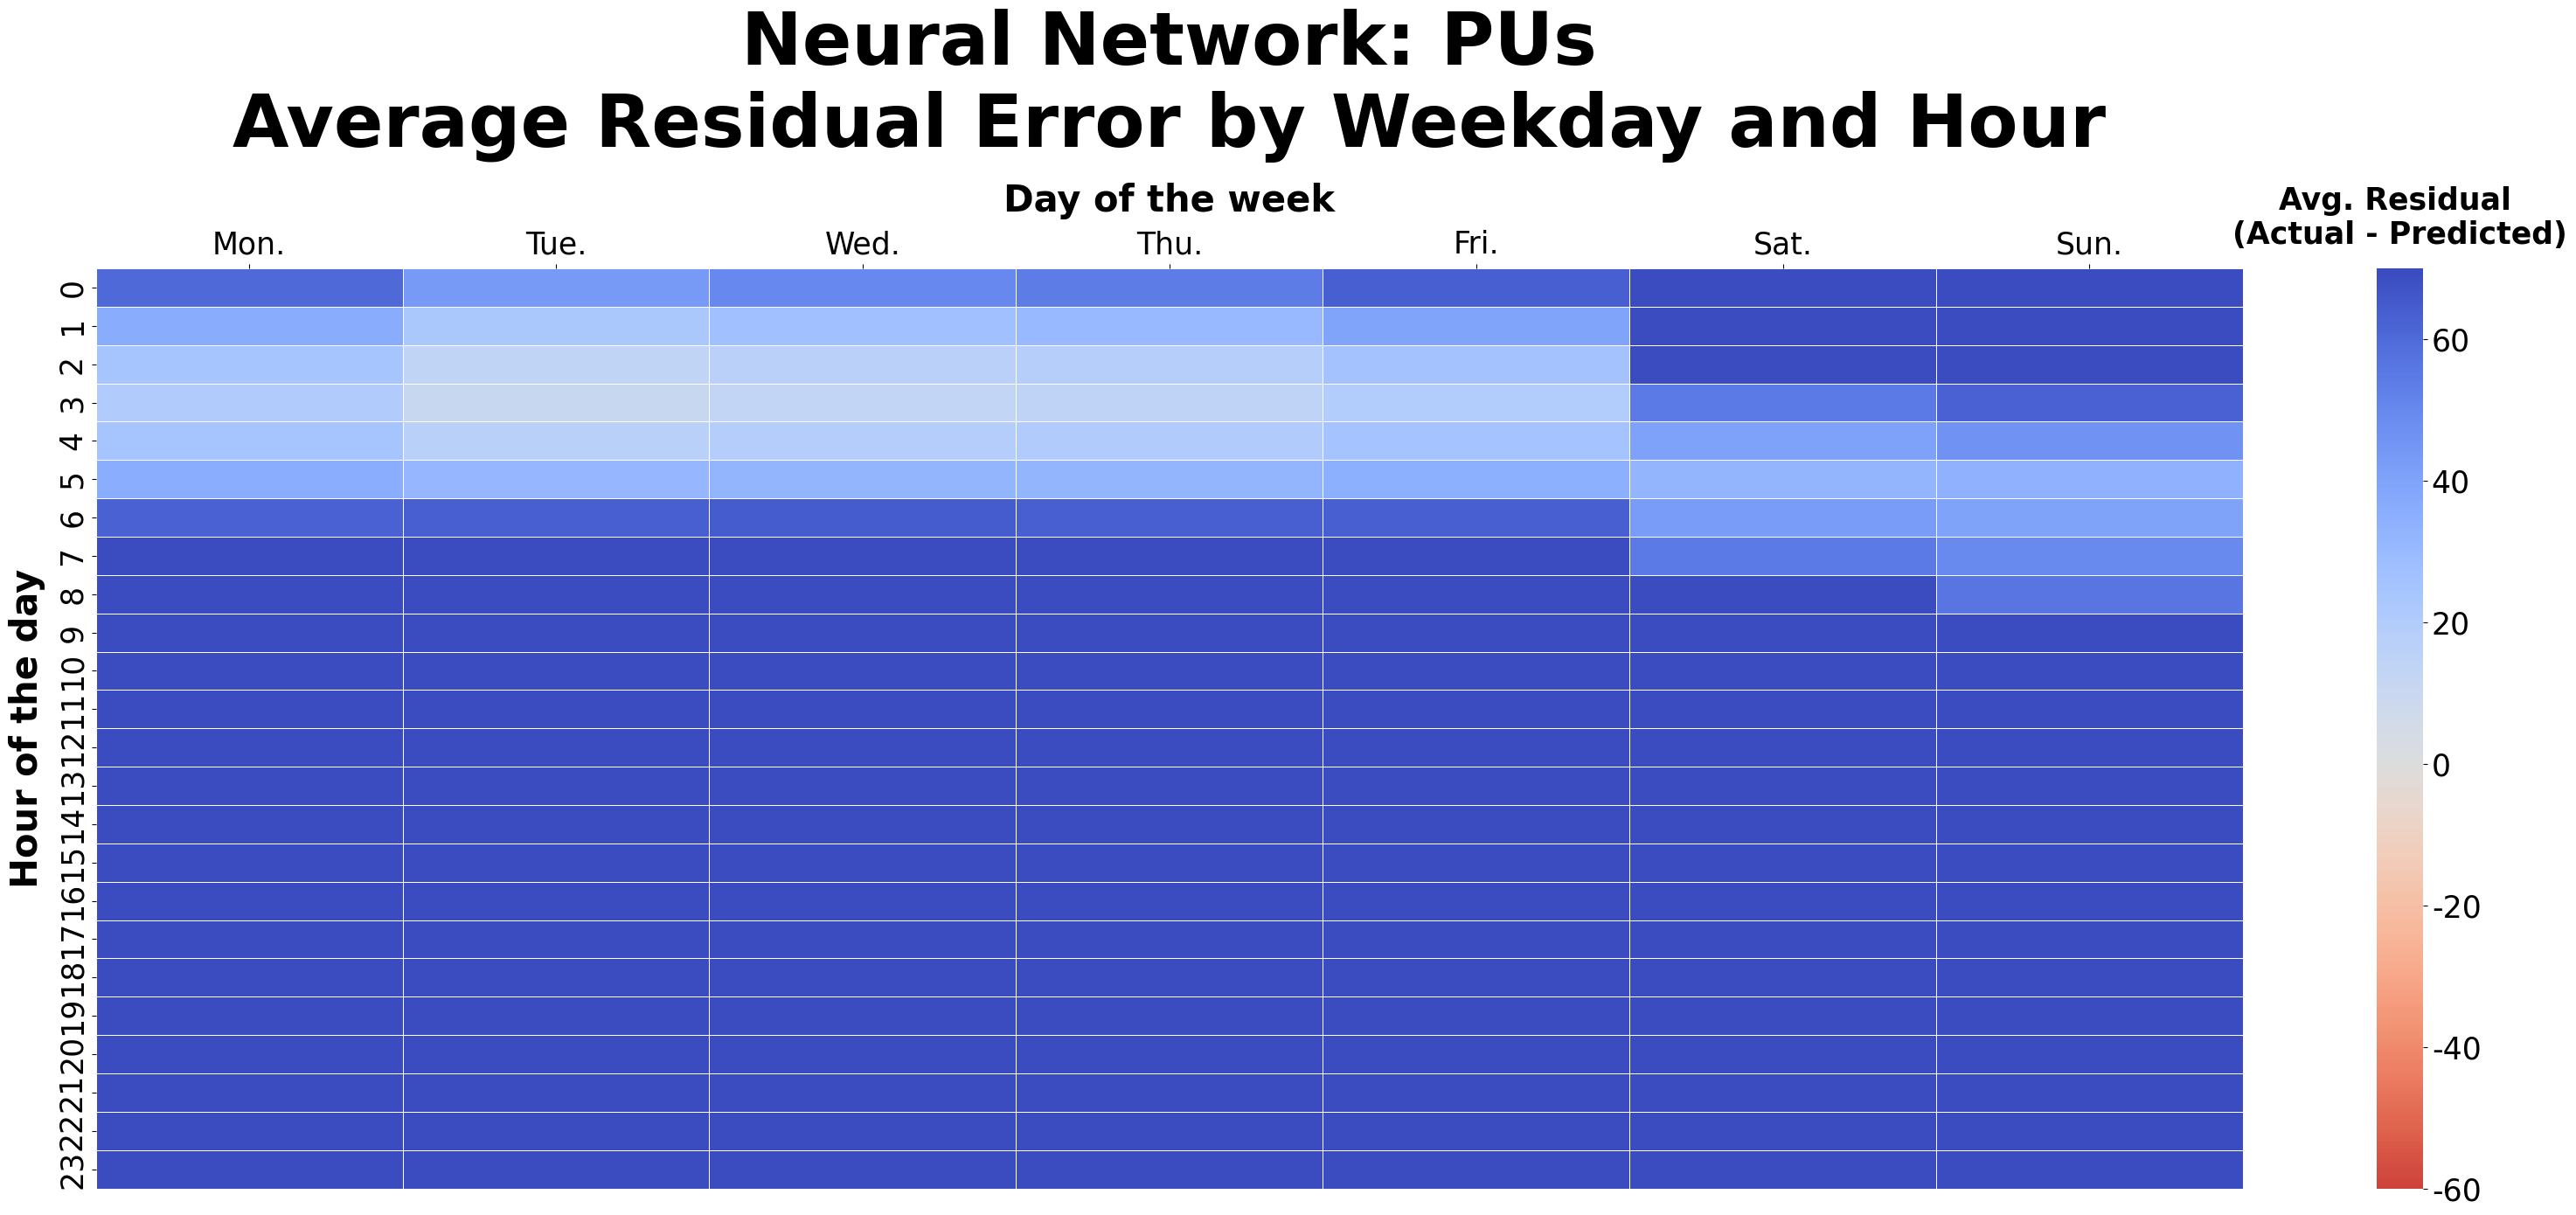

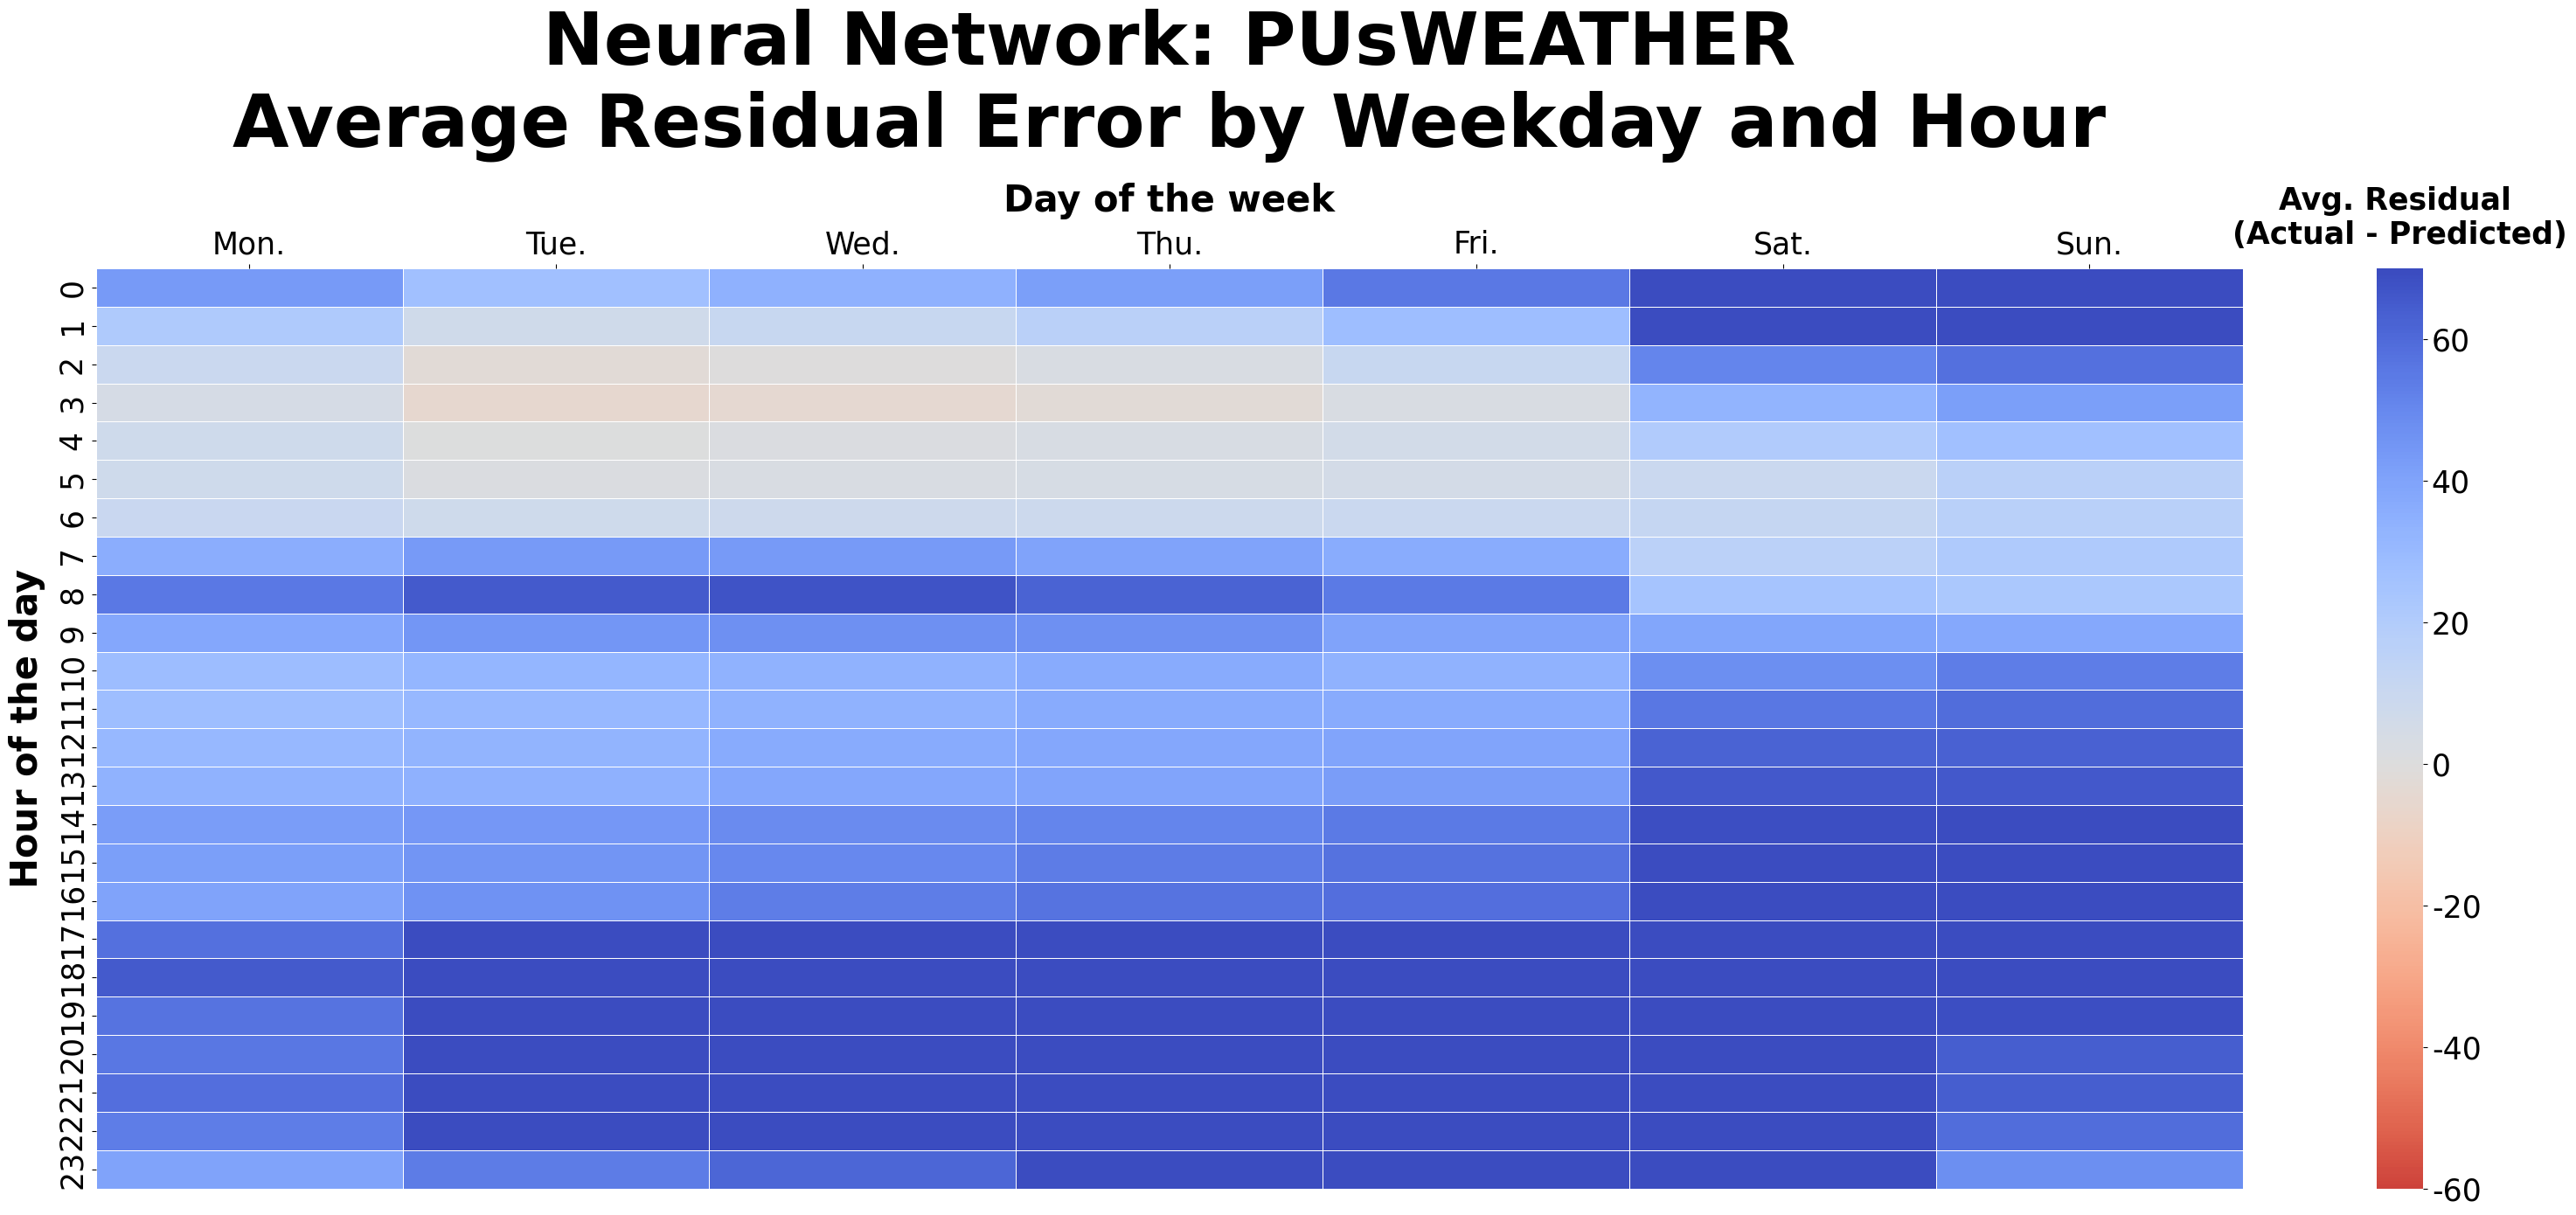

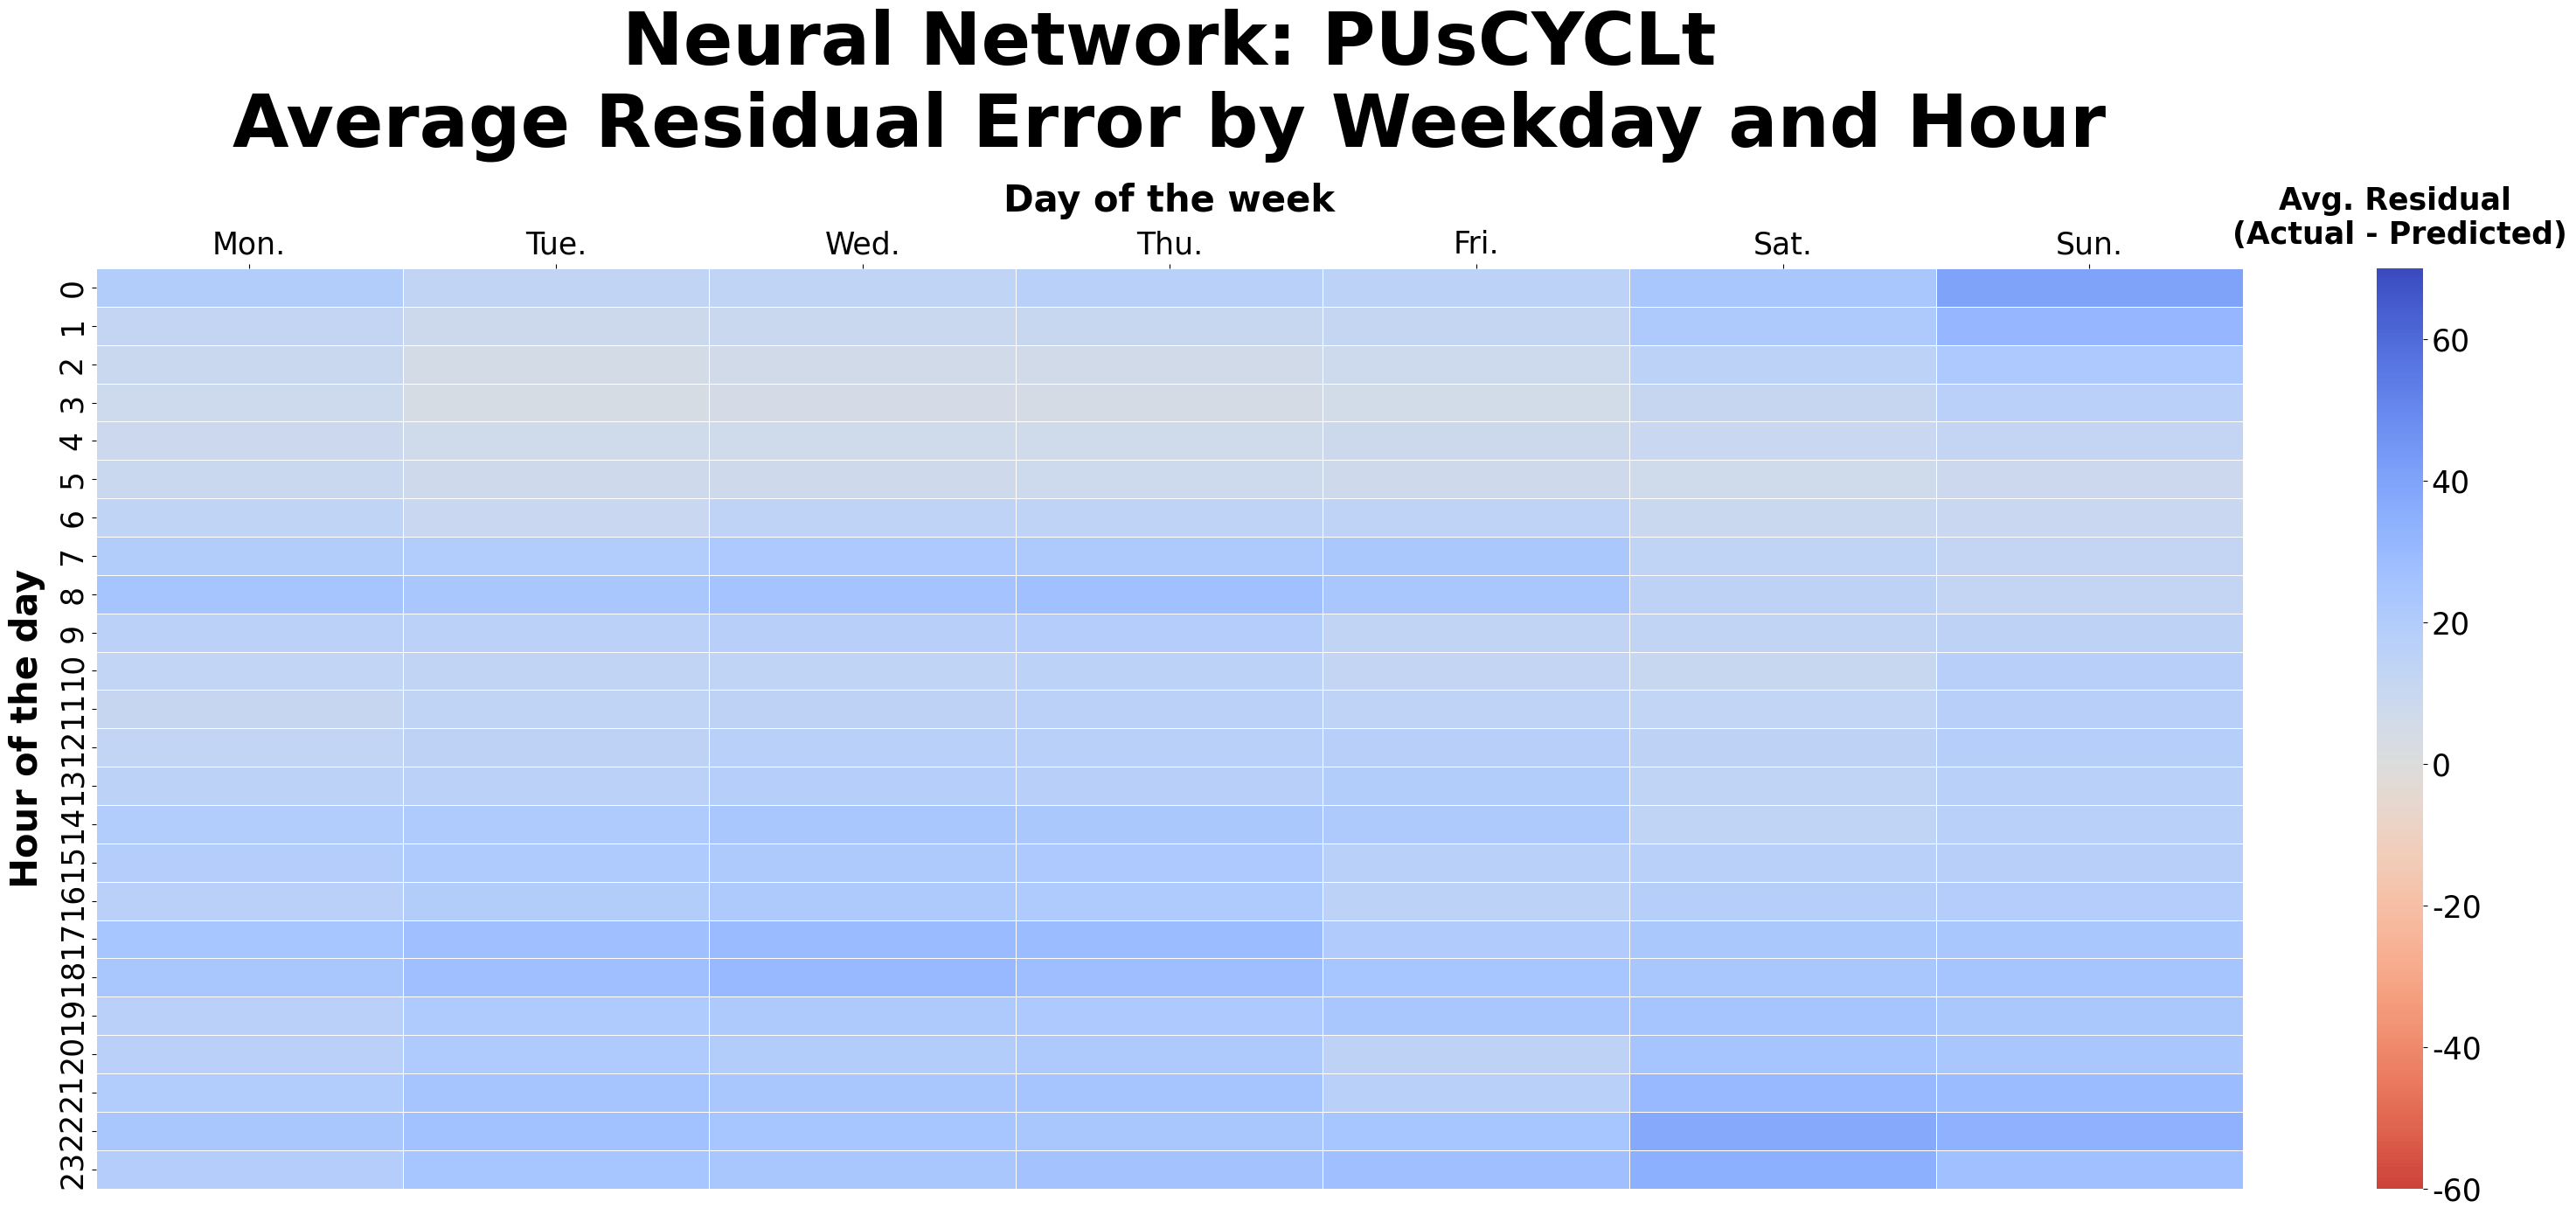

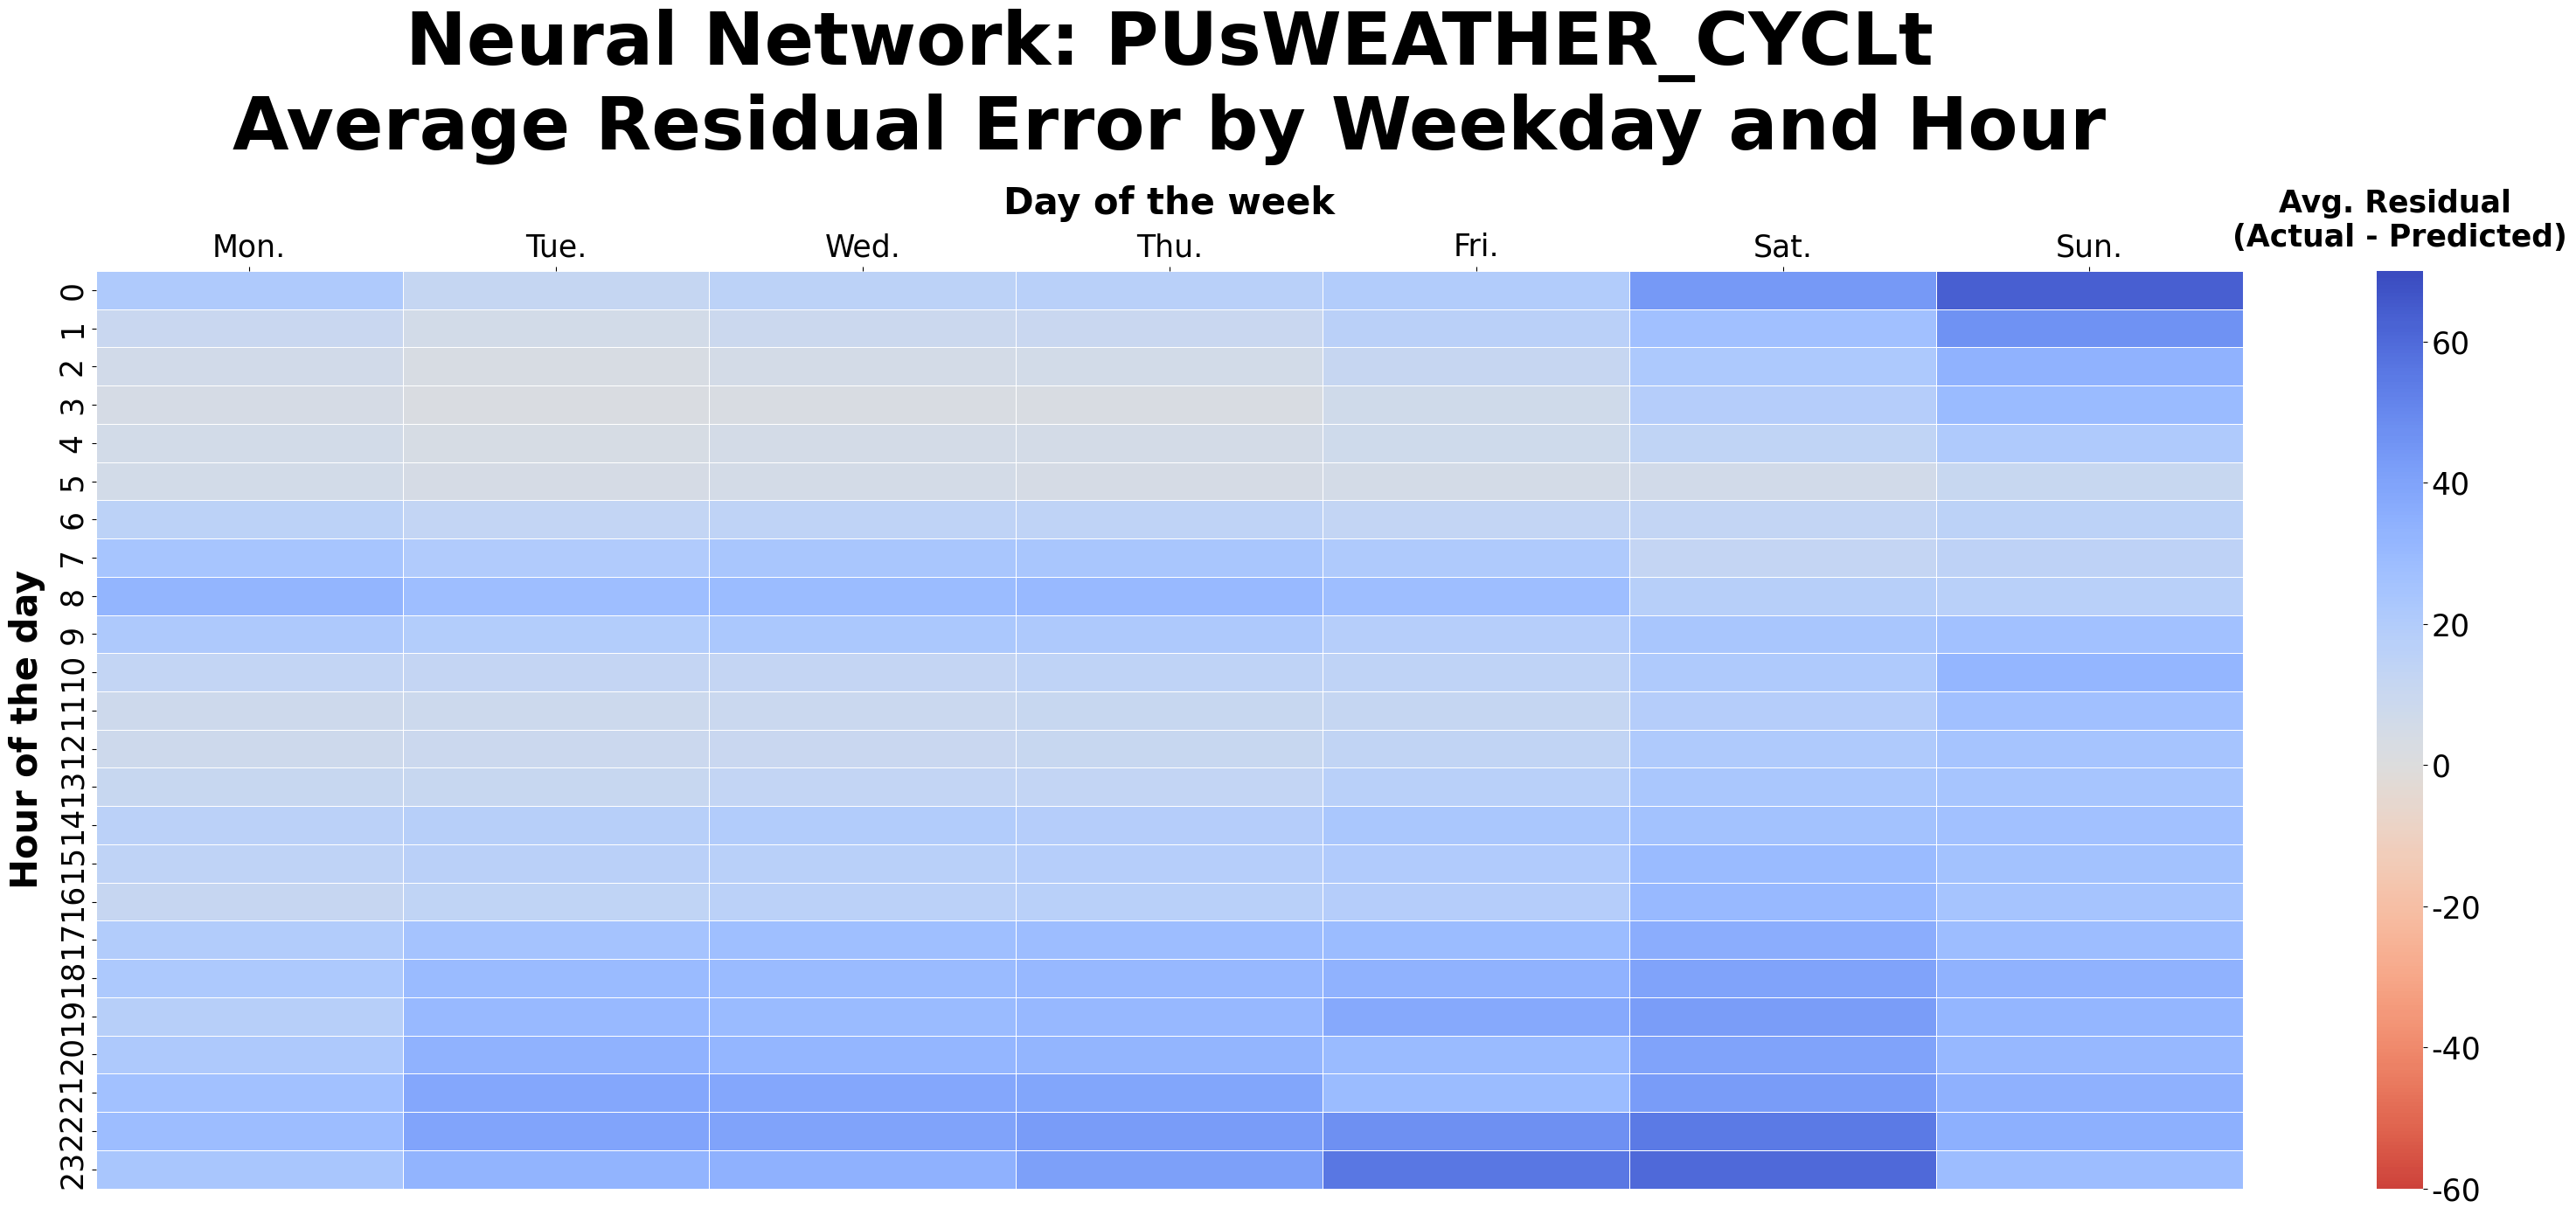

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd

# 1. Define the models and their dataframes
models = {
    'Ridge Regression': PU_Ridge_unscaled,
    'Random Forest': PU_RF_unscaled,
    'Neural Network': PU_NN_unscaled
}

# 2. Define the datasets using your raw column names
datasets = ['PUs', 'PUsWEATHER', 'PUsCYCLt', 'PUsWEATHER_CYCLt']

# Outer Loop: Iterate through each model
for model_name, df_raw in models.items():

    # Create a copy and extract time features once per model
    df = df_raw.copy()
    df['hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek

    # Inner Loop: Iterate through each raw dataset name
    for dataset_name in datasets:

        # Calculate the residual (Actual - Predicted) for this specific dataset
        df['Residual'] = df['Actual'] - df[dataset_name]

        # Create the Pivot Table
        heatmap_data = pd.pivot_table(
            df,
            values="Residual",
            index="hour",
            columns="DayOfWeek",
            aggfunc="mean"
        )

        # --- PLOTTING ---
        plt.figure(figsize=(32,14))

        # Using coolwarm centered at 0
        ax = sns.heatmap(
            data=heatmap_data,
            cmap="coolwarm_r",
            center=0,
            vmin=-60,
            vmax=70,
            linewidth=0.5,
            annot=False
        )

        # Titles and Labels using the raw dataset name
        plt.title(f"{model_name}: {dataset_name}\nAverage Residual Error by Weekday and Hour",
                  fontsize=60, fontweight="bold", pad=30)

        ax.set_xlabel("Day of the week", fontweight="bold", labelpad=15, fontsize=30)
        ax.set_xticklabels(["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."], fontsize=25)

        ax.set_ylabel("Hour of the day", fontweight="bold", labelpad=10, fontsize=30)
        ax.tick_params(axis="y", labelsize=25)

        # Move X-axis labels to the top
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position("top")

        # Format the colorbar
        cbar = ax.collections[0].colorbar
        cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x:,.0f}")) # (AI generated)
        cbar.ax.set_title("Avg. Residual \n(Actual - Predicted)", pad=20, fontsize=25, fontweight="bold")
        cbar.ax.tick_params(labelsize=25)

        plt.tight_layout()

        #plt.savefig(f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/ResidualsHeatmaps/ResidualsHeatmap_{model_name}_{dataset_name}.pdf", dpi=300)

        plt.show()
        plt.close()

Plotting the Geographical Distribution of the Residuals

In [19]:
# Initialize the DataFrame to store Drop-Off actuals and predictions
DO_RidgeResults = None

for file in DO_datasets:
    # Read and clean the dataset, filtering for 2023-2024 and dropping irrelevant columns
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate 2024 data for testing and define the feature matrix
    # (Note: Location IDs are dropped from features but retained in the test DataFrame)
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","year","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the DO_RidgeResults DataFrame during the first iteration
    # Unlike previous versions, we explicitly retain the 'DOLocationID' for spatial analysis
    if DO_RidgeResults is None:
        DO_RidgeResults = pd.DataFrame({
            "Date" : df_test["date"],
            "DOLocationID": df_test["DOLocationID"],
            "Actual" : df_test["trip_count"]
        })

    # Locate the matching Ridge Regression (.pkl) model for the current dataset
    for model in ridge_files:
        if f"{DO_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the model and append its predictions as a new column
    ridge_model = joblib.load(right_model)
    DO_RidgeResults[f"{DO_datasets[file]}"] = ridge_model.predict(X_test)


# Initialize the DataFrame to store Pick-Up actuals and predictions
PU_RidgeResults = None

for file in PU_datasets:
    # Read and clean the dataset, filtering for 2023-2024 and dropping irrelevant columns
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate 2024 data for testing and define the feature matrix
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","year","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the PU_RidgeResults DataFrame during the first iteration
    # Here, we explicitly retain the 'PULocationID' for spatial analysis
    if PU_RidgeResults is None:
        PU_RidgeResults = pd.DataFrame({
            "Date" : df_test["date"],
            "PULocationID": df_test["PULocationID"],
            "Actual" : df_test["trip_count"]
        })

    # Locate the matching Ridge Regression (.pkl) model for the current dataset
    for model in ridge_files:
        if f"{PU_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Load the model and append its predictions as a new column
    ridge_model = joblib.load(right_model)
    PU_RidgeResults[f"{PU_datasets[file]}"] = ridge_model.predict(X_test)

In [20]:
# Initialize the DataFrame to store Drop-Off actuals, predictions, and location IDs
DO_RFResults = None

for file in DO_datasets:
    # Load and clean the data, keeping only 2023-2024 records
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate the 2024 test set and define the feature matrix
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the results DataFrame, explicitly retaining 'DOLocationID' for spatial analysis
    if DO_RFResults is None:
        DO_RFResults = pd.DataFrame({
            "Date" : df_test["date"],
            "DOLocationID": df_test["DOLocationID"],
            "Actual" : df_test["trip_count"]
            })

    # Locate and load the matching Random Forest model
    for model in rf_files:
        if f"{DO_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Generate predictions, casting features to float32 as required by RAPIDS cuML
    rf_model = joblib.load(right_model)
    DO_RFResults[f"{DO_datasets[file]}"] = rf_model.predict(X_test.astype("float32")).values


# Initialize the DataFrame to store Pick-Up actuals, predictions, and location IDs
PU_RFResults = None

for file in PU_datasets:
    # Load and clean the data, keeping only 2023-2024 records
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate the 2024 test set and define the feature matrix
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the results DataFrame, explicitly retaining 'PULocationID' for spatial analysis
    if PU_RFResults is None:
        PU_RFResults = pd.DataFrame({
            "Date" : df_test["date"],
            "PULocationID": df_test["PULocationID"],
            "Actual" : df_test["trip_count"]
            })

    # Locate and load the matching Random Forest model
    for model in rf_files:
        if f"{PU_datasets[file]}.pkl" in model:
            right_model = model
            break

    # Generate predictions, casting features to float32 as required by RAPIDS cuML
    rf_model = joblib.load(right_model)
    PU_RFResults[f"{PU_datasets[file]}"] = rf_model.predict(X_test.astype("float32")).values

In [21]:
# Initialize the DataFrame to store Drop-Off actuals, predictions, and location IDs
DO_NNResults = None

for file in DO_datasets:
    # Load and clean the data, keeping only 2023-2024 records and dropping unneeded columns
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate the 2024 test set and create the feature matrix (excluding target, date, and location IDs)
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the results DataFrame, explicitly retaining 'DOLocationID' for spatial analysis
    if DO_NNResults is None:
        DO_NNResults = pd.DataFrame({
            "Date" : df_test["date"],
            "DOLocationID": df_test["DOLocationID"],
            "Actual" : df_test["trip_count"]
            })

    # Locate the corresponding Keras neural network model file
    for model in nn_files:
        if f"{DO_datasets[file]}.keras" in model:
            right_model = model
            break

    # Clear the backend session to prevent memory leaks, load the model, and generate predictions via tensors
    tf.keras.backend.clear_session()
    nn_model = tf.keras.models.load_model(right_model, compile=False)
    X_test_tensor = tf.constant(X_test.values, dtype=tf.float32)
    preds = nn_model.predict(X_test_tensor)
    DO_NNResults[f"{DO_datasets[file]}"] = preds.flatten()


# Initialize the DataFrame to store Pick-Up actuals, predictions, and location IDs
PU_NNResults = None

for file in PU_datasets:
    # Load and clean the data, keeping only 2023-2024 records and dropping unneeded columns
    df = pd.read_parquet(file)
    df = df.rename(columns={df.columns[1]:"date"})
    df = df[df["year"].isin([2023, 2024])]
    df["year"] = df["year"].map({2023: 0, 2024: 1})
    df = df.drop(columns=["precipitation"], errors='ignore')
    df = df.drop(columns=["total_amount"], errors="ignore")
    df = df.dropna()

    # Isolate the 2024 test set and create the feature matrix (excluding target, date, and location IDs)
    df_test = df[df["date"]>=pd.to_datetime("2024-01-01")].copy()
    X_test = df_test.drop(columns=["trip_count","date","DOLocationID","PULocationID"],errors="ignore")

    # Initialize the results DataFrame, explicitly retaining 'PULocationID' for spatial analysis
    if PU_NNResults is None:
        PU_NNResults = pd.DataFrame({
            "Date" : df_test["date"],
            "PULocationID": df_test["PULocationID"],
            "Actual" : df_test["trip_count"]
            })

    # Locate the corresponding Keras neural network model file
    for model in nn_files:
        if f"{PU_datasets[file]}.keras" in model:
            right_model = model
            break

    # Clear the backend session to prevent memory leaks, load the model, and generate predictions via tensors
    tf.keras.backend.clear_session()
    nn_model = tf.keras.models.load_model(right_model, compile=False)
    X_test_tensor = tf.constant(X_test.values, dtype=tf.float32)
    preds = nn_model.predict(X_test_tensor)
    PU_NNResults[f"{PU_datasets[file]}"] = preds.flatten()

69629/69629 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step
69629/69629 ━━━━━━━━━━━━━━━━━━━━ 89s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 90s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step
69061/69061 ━━━━━━━━━━━━━━━━━━━━ 92s 1ms/step


In [22]:
# Identify the columns that contain scaled numerical data (Actuals and model predictions)
# by explicitly excluding metadata columns like Date and Location IDs
# (AI generated)
PU_unscale_cols = [col for col in PU_RidgeResults.columns if col not in ["Date","PULocationID","DOLocationID"]]
DO_unscale_cols = [col for col in DO_RidgeResults.columns if col not in ["Date","PULocationID","DOLocationID"]]

# Create independent copies of the Ridge Regression results to avoid mutating the original data
PU_Ridge_unscaled = PU_RidgeResults.copy()
DO_Ridge_unscaled = DO_RidgeResults.copy()

# Reverse the Z-score normalization for Ridge predictions and actuals on the selected columns
# Pick-Ups: multiply by standard deviation (126) and add the mean (71)
PU_Ridge_unscaled[PU_unscale_cols] = (PU_RidgeResults[PU_unscale_cols] * 126) + 71
# Drop-Offs: multiply by standard deviation (125) and add the mean (68)
DO_Ridge_unscaled[DO_unscale_cols] = (DO_RidgeResults[DO_unscale_cols] * 125) + 68

# Create independent copies of the Random Forest results
PU_RF_unscaled = PU_RFResults.copy()
DO_RF_unscaled = DO_RFResults.copy()

# Reverse the scaling for the Random Forest predictions and actuals
PU_RF_unscaled[PU_unscale_cols] = (PU_RFResults[PU_unscale_cols] * 126) + 71
DO_RF_unscaled[DO_unscale_cols] = (DO_RFResults[DO_unscale_cols] * 125) + 68

# Create independent copies of the Neural Network results
PU_NN_unscaled = PU_NNResults.copy()
DO_NN_unscaled = DO_NNResults.copy()

# Reverse the scaling for the Neural Network predictions and actuals
PU_NN_unscaled[PU_unscale_cols] = (PU_NNResults[PU_unscale_cols] * 126) + 71
DO_NN_unscaled[DO_unscale_cols] = (DO_NNResults[DO_unscale_cols] * 125) + 68

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Load the shapefile ONCE outside the loops to save processing time
zones_path = kagglehub.dataset_download("florianhinrichsen/taxizones")
zones = gpd.read_file(zones_path + "/taxi_zones.shp")

# 2. Define all models and their dataframes
models = {
    'Ridge Regression': DO_Ridge_unscaled,
    'Random Forest': DO_RF_unscaled,
    'Neural Network': DO_NN_unscaled
}

# 3. Define the datasets
datasets = ['DOs', 'DOsWEATHER', 'DOsCYCLt', 'DOsWEATHER_CYCLt']

# Outer Loop: Iterate through each model
for model_name, df_raw in models.items():

    # Create a copy so we don't overwrite your original dataframes
    df = df_raw.copy()

    # Inner Loop: Iterate through each dataset
    for dataset_name in datasets:

        # Calculate the raw residuals (Actual - Predicted) for this iteration
        df["Residual"] = df["Actual"] - df[dataset_name]

        # Group by LocationID to get the average residual per zone
        avg_residuals = df.groupby("DOLocationID")["Residual"].mean().reset_index()

        # Merge with the shapefile
        merged_DOs = zones.merge(avg_residuals, left_on="LocationID", right_on="DOLocationID")

        # Set the limits of the scale at 150
        max_error = 150

        # --- PLOTTING ---
        fig, ax = plt.subplots(1, 1, figsize=(32, 14))

        merged_DOs.plot(
            column="Residual",
            cmap="coolwarm_r",
            linewidth=0.5,
            ax=ax,
            edgecolor="0.5",
            vmin=-max_error,       # Lock negative limit
            vmax=max_error,        # Lock positive limit
            legend=True,
            legend_kwds={
                "orientation": "vertical",
                "location": "left",
                "shrink": 0.9,
                "pad": 0
            }
        )
        ax.axis("off")

        plt.title(f"{model_name}: Average Residual Error \nby Taxi Zone ({dataset_name})",
                  fontsize=50, fontweight="bold", pad=50)

        # Format the Colorbar
        cbar_ax = fig.axes[-1]
        cbar_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x:,.1f}")) # (AI generated)
        cbar_ax.set_title("Avg. Residual\n(Actual - Predicted)", pad=20, fontweight="bold", fontsize=30)
        cbar_ax.tick_params(labelsize=25)

        plt.tight_layout()

        save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/ResidualsMaps/ResidualsMap_{model_name}_{dataset_name}.pdf"
        #plt.savefig(save_path, dpi=300)

        plt.show()
        plt.close()

Output hidden; open in https://colab.research.google.com to view.

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Load the shapefile ONCE outside the loops to save processing time
zones_path = kagglehub.dataset_download("florianhinrichsen/taxizones")
zones = gpd.read_file(zones_path + "/taxi_zones.shp")

# 2. Define all models and their dataframes
models = {
    'Ridge Regression': PU_Ridge_unscaled,
    'Random Forest': PU_RF_unscaled,
    'Neural Network': PU_NN_unscaled
}

# 3. Define the datasets
datasets = ['PUs', 'PUsWEATHER', 'PUsCYCLt', 'PUsWEATHER_CYCLt']

# Outer Loop: Iterate through each model
for model_name, df_raw in models.items():

    # Create a copy so we don't overwrite your original dataframes
    df = df_raw.copy()

    # Inner Loop: Iterate through each dataset
    for dataset_name in datasets:

        # Calculate the raw residuals (Actual - Predicted) for this iteration
        df["Residual"] = df["Actual"] - df[dataset_name]

        # Group by LocationID to get the average residual per zone
        avg_residuals = df.groupby("PULocationID")["Residual"].mean().reset_index()

        # Merge with the shapefile
        merged_PUs = zones.merge(avg_residuals, left_on="LocationID", right_on="PULocationID")

        # Set the limits of the scale at 150
        max_error = 150

        # --- PLOTTING ---
        fig, ax = plt.subplots(1, 1, figsize=(32, 14))

        merged_PUs.plot(
            column="Residual",
            cmap="coolwarm_r",
            linewidth=0.5,
            ax=ax,
            edgecolor="0.5",
            vmin=-max_error,       # Lock negative limit
            vmax=max_error,        # Lock positive limit
            legend=True,
            legend_kwds={
                "orientation": "vertical",
                "location": "left",
                "shrink": 0.9,
                "pad": 0
            }
        )
        ax.axis("off")

        plt.title(f"{model_name}: Average Residual Error \nby Taxi Zone ({dataset_name})",
                  fontsize=50, fontweight="bold", pad=50)

        # Format the Colorbar
        cbar_ax = fig.axes[-1]
        cbar_ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x:,.1f}")) # (AI generated)
        cbar_ax.set_title("Avg. Residual\n(Actual - Predicted)", pad=20, fontweight="bold", fontsize=30)
        cbar_ax.tick_params(labelsize=25)

        plt.tight_layout()

        save_path = f"drive/MyDrive/BT_Florian_2026/Evaluation Plots/Comparisons/ResidualsMaps/ResidualsMap_{model_name}_{dataset_name}.pdf"
        #plt.savefig(save_path, dpi=300)

        plt.show()
        plt.close()

Output hidden; open in https://colab.research.google.com to view.